# Analiza skupa podataka Hotel Booking

U ovom projektu analizira se skup podataka **Hotel Booking**, koji sadrži informacije o rezervacijama u gradskom i resort hotelu. Svaki red predstavlja jednu rezervaciju, dok kolone opisuju njene karakteristike, kao što su period između rezervisanja i dolaska, dužina boravka, tip depozita, tržišni segment i prethodna istorija gosta.

Skup podataka preuzet je sa platforme Kaggle:

**Izvor:** [Hotel Booking – Kaggle](https://www.kaggle.com/datasets/mojtaba142/hotel-booking)

Podaci obuhvataju rezervacije sa planiranim dolaskom u periodu od 1. jula 2015. do 31. avgusta 2017. godine. Početni skup sadrži 119.390 redova i 36 kolona.

Kao ciljna promenljiva koristi se kolona `is_canceled`, koja označava da li je rezervacija otkazana ili nije. Problem predstavlja binarnu klasifikaciju, jer se predviđa jedna od dve moguće klase: rezervacija je otkazana ili rezervacija nije otkazana.

U toku rada biće izvršeni učitavanje i početni pregled podataka, analiza nedostajućih i neuobičajenih vrednosti, čišćenje podataka, eksplorativna analiza, statistička provera odabranih povezanosti, kreiranje novih promenljivih, priprema podataka za modeliranje i poređenje više algoritama mašinskog učenja.

## 1. Učitavanje biblioteka

Na početku učitavamo biblioteke koje su potrebne za rad sa podacima i osnovnu analizu dataset-a.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

pd.set_option("display.max_columns", None)

## 2. Učitavanje skupa podataka

Dataset se učitava iz foldera **data**. Koristi se CSV fajl **hotel_booking.csv**, koji sadrži podatke o hotelskim rezervacijama.

In [2]:
df = pd.read_csv("../data/hotel_booking.csv")

print("Podaci su uspešno učitani.")
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

Podaci su uspešno učitani.
Broj redova: 119390
Broj kolona: 36


## 3. Osnovni pregled podataka

U ovom delu proveravamo osnovnu strukturu dataset-a: prvih nekoliko redova, nazive kolona, tipove podataka i osnovne informacije o podacima.

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [5]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Kratak zaključak početnog pregleda

Skup podataka sadrži **119390 redova i 36 kolona**, pri čemu svaki red predstavlja jednu hotelsku rezervaciju. Kolone obuhvataju informacije o hotelu, gostima, terminu boravka, načinu rezervisanja, prethodnim rezervacijama i statusu otkazivanja.

Početni pregled pokazuje da skup sadrži i numeričke i kategorijske promenljive. Uočeno je da pojedine numeričke kolone imaju veoma velike maksimalne vrednosti u odnosu na njihove medijane, što može ukazivati na prisustvo netipičnih ili ekstremnih vrednosti. Takođe, broj validnih vrednosti nije isti u svim kolonama, pa je potrebno detaljno proveriti nedostajuće podatke.

U narednim koracima biće analizirane nedostajuće vrednosti, zatim netipične i ekstremne vrednosti, nakon čega će biti urađena detaljnija eksplorativna analiza i ispitivanje odnosa sa ciljnom promenljivom `is_canceled`.

## 4. Analiza nedostajućih vrednosti

Nedostajući podaci mogu biti zapisani kao prazna polja u originalnom CSV fajlu. Međutim, `pandas.read_csv()` ih pri standardnom učitavanju automatski prepoznaje i predstavlja kao `NaN` vrednosti. Zbog toga će se u ovom notebook-u svi nedostajući podaci proveravati pomoću metode `isna()`.

In [8]:
missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df) * 100).round(3)

missing_summary = pd.DataFrame({
    "Broj nedostajućih vrednosti": missing_counts,
    "Procenat nedostajućih vrednosti": missing_percentages
})

missing_summary = missing_summary[
    missing_summary["Broj nedostajućih vrednosti"] > 0
].sort_values("Broj nedostajućih vrednosti", ascending=False)

missing_summary

,Broj nedostajućih vrednosti,Procenat nedostajućih vrednosti
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


### Ukupan broj redova sa najmanje jednom nedostajućom vrednošću

Ukupan broj nedostajućih polja predstavlja zbir svih `NaN` vrednosti u dataset-u. Sa druge strane, broj redova sa nedostajućim vrednostima pokazuje koliko rezervacija ima najmanje jedno polje bez podatka.

In [9]:
total_missing_values = df.isna().sum().sum()
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing_percentage = (rows_with_missing / len(df) * 100).round(2)

print(f"Ukupan broj nedostajućih polja: {total_missing_values}")
print(f"Broj redova sa najmanje jednom NaN vrednošću: {rows_with_missing}")
print(f"Procenat redova sa najmanje jednom NaN vrednošću: {rows_with_missing_percentage}%")

Ukupan broj nedostajućih polja: 129425
Broj redova sa najmanje jednom NaN vrednošću: 119173
Procenat redova sa najmanje jednom NaN vrednošću: 99.82%


### Zaključak analize nedostajućih vrednosti

Nedostajuće vrednosti pronađene su u kolonama `children`, `country`, `agent` i `company`. Kolona `company` ima ubedljivo najveći procenat nedostajućih vrednosti, dok `agent` ima umeren broj nedostajućih zapisa. Kolone `country` i `children` imaju veoma mali procenat nedostajućih vrednosti.

Visok procenat redova sa najmanje jednom nedostajućom vrednošću najvećim delom je posledica kolone `company`. Zbog toga se ne može zaključiti da je skoro ceo dataset neupotrebljiv, već je potrebno posebno razmotriti značenje nedostajućih vrednosti u svakoj koloni.

U ovom koraku podaci nisu menjani. Način obrade biće određen u kasnijem delu čišćenja, nakon dodatne provere značenja kolona i uticaja nedostajućih vrednosti na dalju analizu.

## 5. Provera dupliranih redova

Najpre se proverava da li u skupu postoje potpuno identični redovi. Zatim se provera ponavlja nakon privremenog izostavljanja direktnih identifikatora gostiju i kolona koje opisuju konačni status rezervacije. Druga provera služi samo za uočavanje mogućih ponavljanja i ne menja originalni DataFrame `df`.

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = round(duplicate_count / len(df) * 100, 2)

print(f"Broj dupliranih redova: {duplicate_count}")
print(f"Procenat dupliranih redova: {duplicate_percentage}%")

Broj dupliranih redova: 0
Procenat dupliranih redova: 0.0%


### Provera bez identifikacionih i statusnih kolona

Potpuni duplikati mogu ostati neprimećeni ako se redovi razlikuju samo po imenu, kontakt podacima ili kolonama statusa. Zato se privremeno izostavljaju kolone `name`, `email`, `phone-number`, `credit_card`, `reservation_status` i `reservation_status_date`, a zatim se traže redovi koji su jednaki po svim preostalim kolonama.

Prikazuju se ukupan broj redova koji pripadaju nekoj ponovljenoj grupi, broj takvih grupa i broj dodatnih ponavljanja preko prvog reda u svakoj grupi. U tabeli su prikazane prve tri grupe, bez prikazivanja samih ličnih podataka. Umesto toga se vidi koliko različitih identifikacionih vrednosti postoji unutar svake grupe.


In [11]:
columns_excluded_from_duplicate_check = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "reservation_status",
    "reservation_status_date"
]

columns_for_duplicate_check = [
    column
    for column in df.columns
    if column not in columns_excluded_from_duplicate_check
]

repeated_record_mask = df.duplicated(
    subset=columns_for_duplicate_check,
    keep=False
)

repeated_records = df.loc[repeated_record_mask].copy()

additional_repeated_count = df.duplicated(
    subset=columns_for_duplicate_check,
    keep="first"
).sum()

if not repeated_records.empty:
    repeated_records["Grupa ponavljanja"] = (
        repeated_records
        .groupby(
            columns_for_duplicate_check,
            dropna=False,
            sort=False
        )
        .ngroup()
        + 1
    )

    repeated_group_count = (
        repeated_records["Grupa ponavljanja"]
        .nunique()
    )

    example_group_ids = (
        repeated_records["Grupa ponavljanja"]
        .drop_duplicates()
        .head(3)
    )

    example_rows = repeated_records.loc[
        repeated_records["Grupa ponavljanja"].isin(
            example_group_ids
        )
    ]

    repeated_example_summaries = []

    for group_id, group in example_rows.groupby(
        "Grupa ponavljanja",
        sort=False
    ):
        repeated_example_summaries.append({
            "Grupa ponavljanja": group_id,
            "Broj redova": len(group),
            "Indeksi redova": ", ".join(
                map(str, group.index)
            ),
            "Hotel": group["hotel"].iloc[0],
            "Godina dolaska": group["arrival_date_year"].iloc[0],
            "Mesec dolaska": group["arrival_date_month"].iloc[0],
            "Dan dolaska": group["arrival_date_day_of_month"].iloc[0],
            "Lead time": group["lead_time"].iloc[0],
            "Različita imena": group["name"].nunique(),
            "Različiti email-ovi": group["email"].nunique(),
            "Različiti telefoni": group["phone-number"].nunique(),
            "Različite kartice": group["credit_card"].nunique()
        })

    repeated_examples = pd.DataFrame(
        repeated_example_summaries
    )
else:
    repeated_group_count = 0
    repeated_examples = pd.DataFrame()

print(
    "Broj zapisa koji imaju najmanje jedno ponavljanje:",
    int(repeated_record_mask.sum())
)
print("Broj grupa ponovljenih zapisa:", repeated_group_count)
print(
    "Broj dodatnih ponavljanja preko prvog zapisa u svakoj grupi:",
    int(additional_repeated_count)
)

if repeated_examples.empty:
    print("Nisu pronađeni primeri za prikaz.")
else:
    print("\nPrimeri prve tri grupe ponovljenih zapisa:")
    print(repeated_examples.to_string(index=False))


Broj zapisa koji imaju najmanje jedno ponavljanje: 40448
Broj grupa ponovljenih zapisa: 8196
Broj dodatnih ponavljanja preko prvog zapisa u svakoj grupi: 32252

Primeri prve tri grupe ponovljenih zapisa:
 Grupa ponavljanja  Broj redova Indeksi redova        Hotel  Godina dolaska Mesec dolaska  Dan dolaska  Lead time  Različita imena  Različiti email-ovi  Različiti telefoni  Različite kartice
                 1            2           4, 5 Resort Hotel            2015          July            1         14                2                    2                   2                  2
                 2            2         21, 22 Resort Hotel            2015          July            1         72                2                    2                   2                  2
                 3            2         39, 43 Resort Hotel            2015          July            2         70                2                    2                   2                  2


Nakon izostavljanja šest navedenih kolona, **40.448 redova** pripada grupama u kojima se preostale vrednosti ponavljaju. Formirano je **8.196 grupa**, odnosno postoji **32.252 dodatna ponavljanja** preko prvog reda u svakoj grupi. Primeri pokazuju da redovi mogu imati iste podatke o rezervaciji, a različite identifikacione podatke gosta.

Ovaj rezultat nije dovoljan dokaz da su redovi stvarni duplikati. Dataset nema pouzdan jedinstveni identifikator rezervacije, pa dve različite rezervacije mogu imati jednake vrednosti u svim dostupnim kolonama korišćenim za poređenje. Automatsko uklanjanje moglo bi zato da izbriše validne rezervacije i promeni raspodelu podataka.


### Zaključak provere duplikata

Potpuno identični redovi nisu pronađeni. Posle privremenog izostavljanja identifikacionih i statusnih kolona pronađen je veći broj zapisa sa jednakim preostalim vrednostima, ali se bez jedinstvenog identifikatora rezervacije ne može pouzdano utvrditi da li predstavljaju ista rezervisanja ili različite rezervacije sa jednakim karakteristikama. Zbog toga se ovi redovi **ne uklanjaju**, već ostaju u skupu za dalju analizu.


## 6. Analiza netipičnih i ekstremnih vrednosti

Osnovna deskriptivna statistika ukazuje na prisustvo vrlo malih, vrlo velikih ili potencijalno nelogičnih vrednosti u pojedinim kolonama. Ovde prvo proveravamo koliko takvih vrednosti ima i u kojim se kolonama pojavljuju, kako bismo kasnije mogli da odlučimo šta sa njima treba uraditi.

### Kreiranje pomoćnih promenljivih za proveru

U kopiji `analysis_df` privremeno se računaju `total_guests`, kao zbir odraslih, dece i beba, i `total_stay`, kao zbir noćenja tokom vikenda i radnih dana. Ove promenljive koriste se samo za proveru konzistentnosti i analizu neuobičajenih vrednosti. Originalni `df` ostaje nepromenjen, a podaci u ovoj fazi još nisu očišćeni.

In [12]:
analysis_df = df.copy()

analysis_df["total_guests"] = (
    analysis_df["adults"] + analysis_df["children"].fillna(0) + analysis_df["babies"]
)

analysis_df["total_stay"] = (
    analysis_df["stays_in_weekend_nights"] + analysis_df["stays_in_week_nights"]
)

print(f"Broj kolona u originalnom df: {df.shape[1]}")
print(f"Broj kolona u analysis_df: {analysis_df.shape[1]}")

Broj kolona u originalnom df: 36
Broj kolona u analysis_df: 38


### Sistematska provera sumnjivih vrednosti

U nastavku se proveravaju potencijalno nelogične ili veoma retke vrednosti u najvažnijim numeričkim kolonama. Za svaki uslov računa se broj i procenat redova koji ga zadovoljavaju.

In [13]:
unusual_checks = [
    ("Negativna ADR vrednost", analysis_df["adr"] < 0),
    ("ADR veći od 1000", analysis_df["adr"] > 1000),
    ("Rezervacija bez gostiju", analysis_df["total_guests"] == 0),
    ("Rezervacija bez noćenja", analysis_df["total_stay"] == 0),
    ("Boravak duži od 30 noći", analysis_df["total_stay"] > 30),
    ("Lead time duži od 365 dana", analysis_df["lead_time"] > 365),
    ("Više od 10 odraslih gostiju", analysis_df["adults"] > 10),
    ("Više od 5 dece", analysis_df["children"] > 5),
    ("Više od 5 beba", analysis_df["babies"] > 5),
    ("Više od 5 prethodnih otkazivanja", analysis_df["previous_cancellations"] > 5),
    ("Više od 20 prethodnih neotkazanih rezervacija", analysis_df["previous_bookings_not_canceled"] > 20),
    ("Više od 5 izmena rezervacije", analysis_df["booking_changes"] > 5),
    ("Čekanje duže od 100 dana", analysis_df["days_in_waiting_list"] > 100),
    ("Više od 3 potrebna parking mesta", analysis_df["required_car_parking_spaces"] > 3)
]

unusual_values_summary = pd.DataFrame([
    {
        "Provera": description,
        "Broj redova": condition.sum(),
        "Procenat redova": round(condition.sum() / len(analysis_df) * 100, 3)
    }
    for description, condition in unusual_checks
])

unusual_values_summary = unusual_values_summary.sort_values(
    "Broj redova", ascending=False
).reset_index(drop=True)

unusual_values_summary

,Provera,Broj redova,Procenat redova
0,Lead time duži od 365 dana,3148,2.637
1,Čekanje duže od 100 dana,747,0.626
2,Rezervacija bez noćenja,715,0.599
3,Više od 5 prethodnih otkazivanja,202,0.169
4,Rezervacija bez gostiju,180,0.151
5,Više od 5 izmena rezervacije,149,0.125
6,Više od 20 prethodnih neotkazanih rezervacija,135,0.113
7,Boravak duži od 30 noći,24,0.020
8,Više od 10 odraslih gostiju,12,0.010
9,Više od 5 beba,2,0.002


Isti zapis može istovremeno pripadati većem broju navedenih grupa, na primer rezervacija može biti i bez gostiju i bez noćenja. Zbog toga se brojevi iz tabele ne sabiraju kao broj različitih problematičnih redova.

### Pregled konkretnih primera

Prikazani su primeri najvažnijih sumnjivih vrednosti radi njihovog detaljnijeg pregleda i tumačenja. U svakom prikazu izdvojene su relevantne kolone, a najekstremnije vrednosti prikazane su prve.

In [14]:
adr_extreme_rows = analysis_df[(analysis_df["adr"] < 0) | (analysis_df["adr"] > 1000)]
adr_columns = [
    "hotel", "is_canceled", "adr", "adults", "children",
    "babies", "total_stay", "reservation_status"
]

if adr_extreme_rows.empty:
    print("Nisu pronađeni redovi sa negativnim ADR-om ili ADR-om većim od 1000.")
else:
    display(
        adr_extreme_rows.sort_values(
            "adr", key=lambda values: values.abs(), ascending=False
        )[adr_columns].head(10)
    )

,hotel,is_canceled,adr,adults,children,babies,total_stay,reservation_status
48515,City Hotel,1,5400.00,2,0.0,0,1,Canceled
14969,Resort Hotel,0,-6.38,2,0.0,0,10,Check-Out


U koloni adr izdvajaju se dve vrednosti: jedna negativna i jedna izrazito visoka. Pošto dataset ne sadrži dodatno objašnjenje za ove zapise, nije moguće pouzdano utvrditi da li su u pitanju greške ili validni slučajevi. Zato će se kasnije proveriti gde se nalaze u raspodeli i koliko utiču na prosek i medijanu.

In [15]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]
guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "reservation_status"
]

if zero_guest_rows.empty:
    print("Nisu pronađene rezervacije bez gostiju.")
else:
    display(
        zero_guest_rows.sort_values(
            ["total_stay", "adr"], ascending=False
        )[guest_columns].head(10)
    )

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr,reservation_status
101794,City Hotel,0,0,0.0,0,0.0,57,8.34,Check-Out
88017,City Hotel,0,0,0.0,0,0.0,49,0.00,Check-Out
106561,City Hotel,0,0,0.0,0,0.0,43,0.00,Check-Out
41020,City Hotel,0,0,0.0,0,0.0,29,0.00,Check-Out
98046,City Hotel,0,0,0.0,0,0.0,28,0.00,Check-Out
109038,City Hotel,0,0,0.0,0,0.0,27,0.00,Check-Out
100563,City Hotel,0,0,0.0,0,0.0,22,0.00,Check-Out
106562,City Hotel,0,0,0.0,0,0.0,15,35.81,Check-Out
60651,City Hotel,1,0,0.0,0,0.0,15,0.00,Canceled
93204,City Hotel,0,0,0.0,0,0.0,15,0.00,Check-Out


Pronađene su i rezervacije u kojima nije evidentiran nijedan gost. Takvi zapisi deluju neuobičajeno, pa će se pogledati njihov status, broj noćenja i ADR kako bi se bolje razumelo o kakvim rezervacijama je reč i da li ih treba zadržati, izmeniti ili ukloniti.

### Rezervacije bez noćenja

To su rezervacije kod kojih je zbir kolona `stays_in_weekend_nights` i `stays_in_week_nights` jednak nuli. Pre donošenja odluke o njihovoj obradi potrebno je proveriti status rezervacije, broj gostiju i ADR.

In [16]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]
zero_stay_columns = [
    "hotel", "is_canceled", "stays_in_weekend_nights",
    "stays_in_week_nights", "total_stay", "total_guests",
    "adr", "reservation_status", "reservation_status_date"
]

if zero_stay_rows.empty:
    print("Nisu pronađene rezervacije bez noćenja.")
else:
    display(
        zero_stay_rows.sort_values(
            ["is_canceled", "adr"], ascending=[False, False]
        )[zero_stay_columns].head(10)
    )

,hotel,is_canceled,stays_in_weekend_nights,stays_in_week_nights,total_stay,total_guests,adr,reservation_status,reservation_status_date
4127,Resort Hotel,1,0,0,0,0.0,0.0,Canceled,2016-02-15
9376,Resort Hotel,1,0,0,0,0.0,0.0,Canceled,2016-11-21
10101,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2017-02-12
19503,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2015-12-23
19823,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2016-01-04
22557,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2016-03-28
22970,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2016-04-12
23734,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2016-04-30
24660,Resort Hotel,1,0,0,0,2.0,0.0,Canceled,2016-05-29
25333,Resort Hotel,1,0,0,0,1.0,0.0,No-Show,2016-06-21


Rezervacije bez noćenja ne mogu se automatski smatrati greškom. Njihovo značenje zavisi od statusa rezervacije, pa će se proveriti koliko među njima ima otkazanih, realizovanih i `No-Show` rezervacija, kao i da li imaju evidentirane goste i ADR vrednost.

In [17]:
guest_extreme_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]
guest_extreme_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr"
]

if guest_extreme_rows.empty:
    print("Nisu pronađene rezervacije sa veoma velikim brojem gostiju.")
else:
    display(
        guest_extreme_rows.sort_values(
            "total_guests", ascending=False
        )[guest_extreme_columns]
    )

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00


U malom broju rezervacija evidentiran je neuobičajeno veliki broj gostiju. Pošto takvi slučajevi mogu predstavljati i validne grupne rezervacije, nije ih moguće automatski smatrati greškom. Zbog toga će se prilikom čišćenja podataka uzeti u obzir i ostale informacije iz rezervacije kako bi se donela odgovarajuća odluka.

In [18]:
long_lead_time_rows = analysis_df[analysis_df["lead_time"] > 365]
long_waiting_rows = analysis_df[analysis_df["days_in_waiting_list"] > 100]

time_columns = [
    "hotel",
    "is_canceled",
    "lead_time",
    "days_in_waiting_list",
    "deposit_type",
    "market_segment",
    "reservation_status"
]

print("Primeri rezervacija sa lead_time dužim od 365 dana:")

if long_lead_time_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_lead_time_rows
        .sort_values("lead_time", ascending=False)
        [time_columns]
        .head(5)
    )

print("\nPrimeri rezervacija sa čekanjem dužim od 100 dana:")

if long_waiting_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_waiting_rows
        .sort_values("days_in_waiting_list", ascending=False)
        [time_columns]
        .head(5)
    )

Primeri rezervacija sa lead_time dužim od 365 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
1,Resort Hotel,0,737,0,No Deposit,Direct,Check-Out
4182,Resort Hotel,0,709,0,No Deposit,Direct,Check-Out
65245,City Hotel,1,629,0,Non Refund,Groups,Canceled
65253,City Hotel,1,629,0,Non Refund,Groups,Canceled
65240,City Hotel,1,629,0,Non Refund,Groups,Canceled



Primeri rezervacija sa čekanjem dužim od 100 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
59454,City Hotel,1,464,391,Non Refund,Groups,Canceled
59450,City Hotel,1,464,391,Non Refund,Groups,Canceled
59444,City Hotel,1,464,391,Non Refund,Groups,Canceled
59434,City Hotel,1,464,391,Non Refund,Groups,Canceled
59435,City Hotel,1,464,391,Non Refund,Groups,Canceled


Veliki `lead_time` i dugo zadržavanje na listi čekanja predstavljaju retke, ali moguće vrednosti. One se za sada ne smatraju greškama. Kasnije će se analizirati njihova raspodela i povezanost sa ciljnom promenljivom `is_canceled`.

### Zaključak analize netipičnih i ekstremnih vrednosti

Analizom su pronađene potencijalno nelogične vrednosti, kao što su negativan ADR, rezervacije bez evidentiranih gostiju i rezervacije bez noćenja. Uočene su i retke, ali moguće vrednosti u kolonama `lead_time`, `days_in_waiting_list`, broju gostiju i trajanju boravka.

U ovom delu nijedan zapis nije uklonjen niti izmenjen. Sledeći korak biće detaljnija analiza izdvojenih vrednosti: proveriće se njihova raspodela, status rezervacije, odnos sa ciljnom promenljivom `is_canceled` i uticaj na osnovne statističke pokazatelje. Na osnovu tih rezultata biće donete i obrazložene odluke o tome koje vrednosti ostaju, koje se uklanjaju i koje se obrađuju na drugi način.

## 7. Detaljnija analiza izdvojenih vrednosti

Cilj ovog dela je da se konkretno analiziraju najvažnije vrednosti izdvojene u prethodnom segmentu, pre donošenja odluka o čišćenju podataka. Analiza se nastavlja nad prethodno kreiranim `analysis_df`, koji sadrži pomoćne kolone, dok originalni `df` ostaje neizmenjen.

### 7.1. Analiza netipičnih ADR vrednosti

Cilj je da se proveri koliko dve prethodno izdvojene ADR vrednosti utiču na osnovne statističke pokazatelje. Porede se rezultati za sve zapise i za podatke nakon njihovog privremenog izdvajanja.

,Broj zapisa,Prosečna vrednost,Medijana,Standardna devijacija,Minimum,Maksimum
Svi zapisi,119390,101.83,94.58,50.54,-6.38,5400.0
Bez izdvojenih ADR vrednosti,119388,101.79,94.58,48.15,0.00,510.0


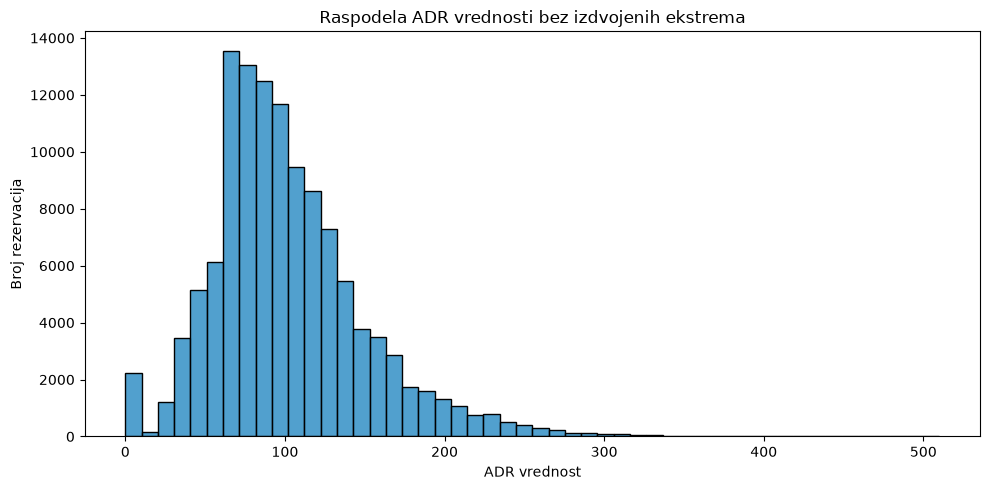

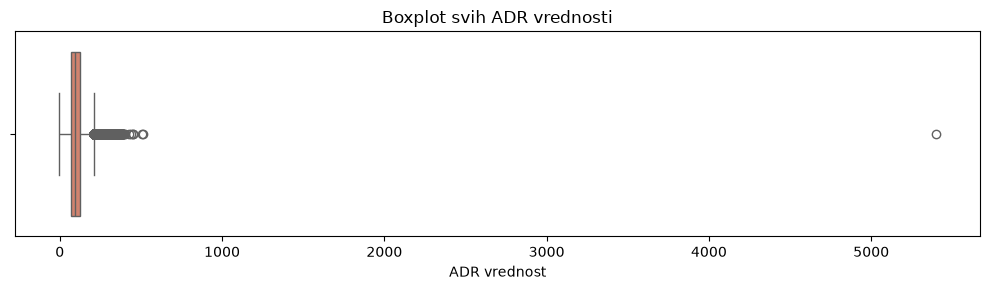

In [19]:
adr_all_values = analysis_df["adr"].dropna()
adr_without_extremes = analysis_df.loc[
    analysis_df["adr"].between(0, 1000),
    "adr"
].dropna()

adr_statistics = pd.DataFrame(
    {
        "Broj zapisa": [adr_all_values.count(), adr_without_extremes.count()],
        "Prosečna vrednost": [adr_all_values.mean(), adr_without_extremes.mean()],
        "Medijana": [adr_all_values.median(), adr_without_extremes.median()],
        "Standardna devijacija": [adr_all_values.std(), adr_without_extremes.std()],
        "Minimum": [adr_all_values.min(), adr_without_extremes.min()],
        "Maksimum": [adr_all_values.max(), adr_without_extremes.max()]
    },
    index=["Svi zapisi", "Bez izdvojenih ADR vrednosti"]
)

display(adr_statistics.round(2))

plt.figure(figsize=(10, 5))
sb.histplot(adr_without_extremes, bins=50, color="#1781BE")
plt.title("Raspodela ADR vrednosti bez izdvojenih ekstrema")
plt.xlabel("ADR vrednost")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sb.boxplot(x=adr_all_values, color="#E07A5F")
plt.title("Boxplot svih ADR vrednosti")
plt.xlabel("ADR vrednost")
plt.tight_layout()
plt.show()

Nakon privremenog izdvajanja dve ADR vrednosti prosek se smanjuje sa 101,83 na 101,79, dok medijana ostaje 94,58. Dve vrednosti zato ne menjaju vidljivo prosek, ali povećavaju standardnu devijaciju i znatno proširuju raspon, što se jasno uočava na boxplot-u. O tome da li će ostati u skupu odlučiće se u delu čišćenja podataka.

### 7.2. Analiza rezervacija bez evidentiranih gostiju

Rezervacije bez evidentiranih gostiju analiziraju se prema statusu, broju noćenja, ADR vrednosti i informaciji o otkazivanju. Primeri redova se ne prikazuju ponovo jer su već dati u prethodnom delu.

In [20]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]

zero_guest_status_summary = (
    zero_guest_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)
zero_guest_status_summary["Procenat rezervacija bez gostiju"] = (
    zero_guest_status_summary["Broj redova"] / len(zero_guest_rows) * 100
).round(3)

zero_guest_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez gostiju",
        "Rezervacije bez noćenja",
        "Rezervacije sa najmanje jednim noćenjem",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om",
        "Otkazane rezervacije prema is_canceled"
    ],
    "Broj redova": [
        len(zero_guest_rows),
        (zero_guest_rows["total_stay"] == 0).sum(),
        (zero_guest_rows["total_stay"] > 0).sum(),
        (zero_guest_rows["adr"] == 0).sum(),
        (zero_guest_rows["adr"] > 0).sum(),
        (zero_guest_rows["is_canceled"] == 1).sum()
    ]
})

display(zero_guest_status_summary)
display(zero_guest_overview)

,Status rezervacije,Broj redova,Procenat rezervacija bez gostiju
0,Check-Out,155,86.111
1,Canceled,24,13.333
2,No-Show,1,0.556


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez gostiju,180
1,Rezervacije bez noćenja,70
2,Rezervacije sa najmanje jednim noćenjem,110
3,Rezervacije sa ADR jednakim nuli,149
4,Rezervacije sa pozitivnim ADR-om,31
5,Otkazane rezervacije prema is_canceled,25


Rezultati pokazuju da rezervacije bez evidentiranih gostiju imaju različite karakteristike. Među njima postoje realizovane rezervacije, rezervacije sa najmanje jednim noćenjem i rezervacije sa pozitivnim ADR-om. Zbog toga se ovi zapisi ne mogu automatski proglasiti greškom ili ukloniti bez dodatnog razmatranja tokom čišćenja podataka.

### 7.3. Analiza rezervacija bez noćenja

Kod rezervacija bez noćenja provereni su status, otkazivanje, broj gostiju i ADR kako bi se bolje razumelo kakvi se zapisi nalaze u ovoj grupi.

,Status rezervacije,Broj redova,Procenat rezervacija bez noćenja
0,Check-Out,680,95.105
1,Canceled,22,3.077
2,No-Show,13,1.818


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez noćenja,715
1,Rezervacije bez evidentiranih gostiju,70
2,Rezervacije sa najmanje jednim gostom,645
3,Rezervacije sa ADR jednakim nuli,715
4,Rezervacije sa pozitivnim ADR-om,0


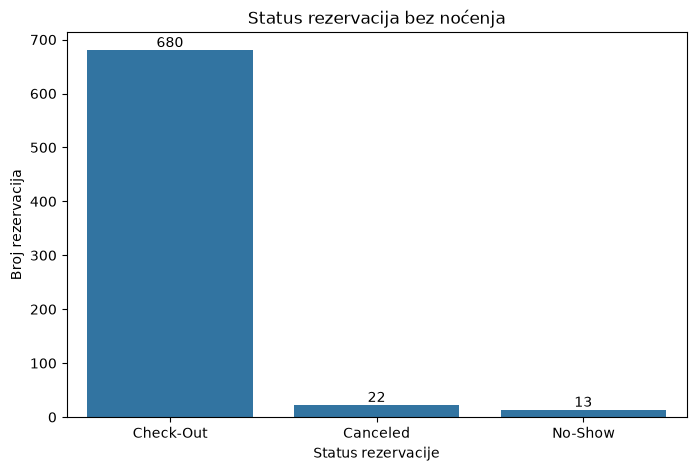

In [21]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]

zero_stay_status_summary = (
    zero_stay_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)

zero_stay_status_summary["Procenat rezervacija bez noćenja"] = (
    zero_stay_status_summary["Broj redova"] / len(zero_stay_rows) * 100
).round(3)

zero_stay_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez noćenja",
        "Rezervacije bez evidentiranih gostiju",
        "Rezervacije sa najmanje jednim gostom",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om"
    ],
    "Broj redova": [
        len(zero_stay_rows),
        (zero_stay_rows["total_guests"] == 0).sum(),
        (zero_stay_rows["total_guests"] >= 1).sum(),
        (zero_stay_rows["adr"] == 0).sum(),
        (zero_stay_rows["adr"] > 0).sum()
    ]
})

display(zero_stay_status_summary)
display(zero_stay_overview)

plt.figure(figsize=(8, 5))

ax = sb.countplot(
    data=zero_stay_rows,
    x="reservation_status",
    order=zero_stay_rows["reservation_status"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija bez noćenja")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Rezultati pokazuju da među rezervacijama bez noćenja preovlađuju zapisi sa statusom Check-Out i da većina ima najmanje jednog evidentiranog gosta. Istovremeno, nijedna od ovih rezervacija nema pozitivan ADR, zbog čega njihovo značenje nije moguće pouzdano utvrditi samo na osnovu dostupnih podataka.

### 7.4. Analiza rezervacija sa neuobičajeno velikim brojem gostiju

Za mali broj rezervacija koje ispunjavaju prethodno definisan kriterijum prikazuju se svi redovi, kao i njihove raspodele prema tržišnom segmentu i statusu rezervacije.

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr,market_segment,reservation_status
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00,Direct,Canceled
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00,Direct,Canceled
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00,Direct,Canceled
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled


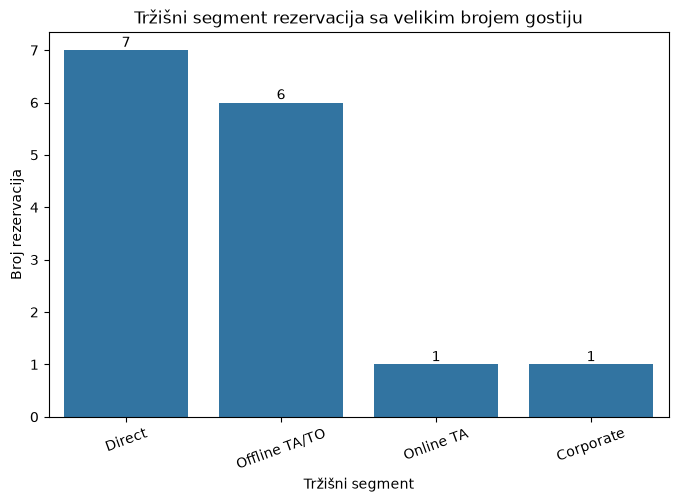

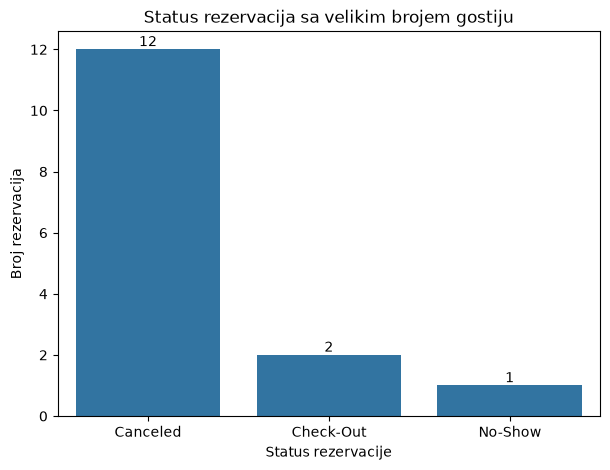

In [22]:
extreme_guest_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]

extreme_guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "market_segment",
    "reservation_status"
]

display(extreme_guest_rows.sort_values("total_guests", ascending=False)[extreme_guest_columns])

plt.figure(figsize=(8, 5))

market_order = (
    extreme_guest_rows["market_segment"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="market_segment",
    order=market_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Tržišni segment rezervacija sa velikim brojem gostiju")
plt.xlabel("Tržišni segment")
plt.ylabel("Broj rezervacija")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 5))

status_order = (
    extreme_guest_rows["reservation_status"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="reservation_status",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija sa velikim brojem gostiju")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Među rezervacijama sa neuobičajeno velikim brojem gostiju najzastupljeniji su segmenti Direct i Offline TA/TO, dok je većina ovih rezervacija otkazana. Ipak, postoje i realizovane rezervacije, uključujući one sa većim brojem dece ili beba, što pokazuje da ova grupa nije ujednačena i da obuhvata različite vrste rezervacija.

### 7.5. Veliki lead time i dugo čekanje

U ovom delu analiziraju se rezervacije sa velikim lead_time i dugim čekanjem na listi čekanja. Grupe se porede prema broju rezervacija i procentu otkazivanja kako bi se utvrdilo da li postoji povezanost između ovih karakteristika i učestalosti otkazivanja.

In [23]:
def create_group_comparison(groups):
    rows = []

    for group_name, condition in groups:
        group_rows = analysis_df.loc[condition]

        rows.append({
            "Grupa": group_name,
            "Broj rezervacija": len(group_rows),
            "Procenat ukupnog skupa": round(len(group_rows) / len(analysis_df) * 100, 3),
            "Broj otkazanih rezervacija": group_rows["is_canceled"].sum(),
            "Procenat otkazanih rezervacija": round(group_rows["is_canceled"].mean() * 100, 3)
        })

    return pd.DataFrame(rows)


lead_time_comparison = create_group_comparison([
    (
        "lead_time <= 365",
        analysis_df["lead_time"] <= 365
    ),
    (
        "lead_time > 365",
        analysis_df["lead_time"] > 365
    )
])

waiting_list_comparison = create_group_comparison([
    (
        "days_in_waiting_list <= 100",
        analysis_df["days_in_waiting_list"] <= 100
    ),
    (
        "days_in_waiting_list > 100",
        analysis_df["days_in_waiting_list"] > 100
    )
])

display(lead_time_comparison)
display(waiting_list_comparison)

,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,lead_time <= 365,116242,97.363,42094,36.212
1,lead_time > 365,3148,2.637,2130,67.662


,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,days_in_waiting_list <= 100,118643,99.374,43852,36.961
1,days_in_waiting_list > 100,747,0.626,372,49.799


Rezervacije napravljene više od godinu dana unapred imaju znatno veći procenat otkazivanja - 67,662% u odnosu na 36,212% kod rezervacija sa kraćim lead_time. Razlika kod vremena provedenog na listi čekanja je manja, ali je i tu procenat otkazivanja viši kada čekanje traje duže od 100 dana. Rezultati ukazuju da je lead_time izraženije povezan sa otkazivanjem nego dužina čekanja na listi. Ipak, na osnovu ovog poređenja može se govoriti samo o povezanosti, a ne i o uzroku otkazivanja.

### Zaključak detaljnije analize izdvojenih vrednosti

Detaljnija analiza izdvojenih vrednosti pokazala je da izdvojene neuobičajene vrednosti ne treba posmatrati na isti način. Neke od njih mogu se smatrati potencijalno nelogičnim, poput negativnog ADR-a ili rezervacija bez evidentiranih gostiju, dok druge predstavljaju retke, ali moguće slučajeve koji se javljaju u stvarnim podacima. Takođe, uočeno je da rezervacije sa velikim lead_time i dugim čekanjem imaju veći procenat otkazivanja u odnosu na uporedne grupe. U ovoj fazi podaci nisu menjani, već su samo analizirani kako bi se u sledećem poglavlju mogle doneti obrazložene odluke o njihovom zadržavanju, uklanjanju ili drugačijoj obradi.

## 8. Čišćenje podataka

U ovom poglavlju podaci se pripremaju za dalju analizu na osnovu zaključaka iz prethodnih delova. Sve promene primenjuju se na posebnu kopiju, dok originalni DataFrame ostaje nepromenjen.


### 8.1. Plan čišćenja podataka

Na osnovu prethodne analize, čišćenje podataka obuhvata sledeće korake:

- od originalnog `df` kreira se posebna kopija `clean_df`, kako bi izvorni skup ostao nepromenjen;
- obrađuju se nedostajuće vrednosti;
- uklanjaju se direktni identifikatori gostiju koji se neće koristiti u daljoj analizi i modeliranju;
- uklanjaju se kolone koje otkrivaju konačan ishod rezervacije i mogu izazvati curenje podataka;
- posebno se obrađuju dve izdvojene ADR vrednosti;
- uklanjaju se rezervacije bez evidentiranih gostiju;
- zadržavaju se rezervacije bez noćenja, sa neuobičajeno velikim brojem gostiju, velikim `lead_time`, dugim čekanjem i dužim boravkom, jer mogu predstavljati retke, ali moguće slučajeve.

Kolone `name`, `email`, `phone-number` i `credit_card` predstavljaju direktne identifikatore gostiju. Iako prethodno ponašanje gosta može biti povezano sa otkazivanjem, ono je već opisano kolonama `is_repeated_guest`, `previous_cancellations` i `previous_bookings_not_canceled`. Zbog toga se direktni identifikatori uklanjaju kako model ne bi pamtio pojedinačne osobe, već učio obrasce koji se mogu primeniti i na nove goste.

### 8.2. Kreiranje kopije podataka

In [24]:
clean_df = df.copy()

rows_before_cleaning = len(clean_df)
columns_before_cleaning = clean_df.shape[1]

print(f"Broj redova pre čišćenja: {rows_before_cleaning}")
print(f"Broj kolona pre čišćenja: {columns_before_cleaning}")

Broj redova pre čišćenja: 119390
Broj kolona pre čišćenja: 36


Čišćenje se obavlja nad kopijom `clean_df`, tako da originalni skup `df` ostaje nepromenjen i može se koristiti za poređenje sa očišćenim podacima.

### 8.3. Obrada nedostajućih vrednosti

U koloni `children` nedostaju samo četiri vrednosti. One se zamenjuju nulom, jer kolona predstavlja broj dece i treba da sadrži cele brojeve. Korišćenje proseka moglo bi da dovede do decimalne vrednosti, dok je nula smislena pretpostavka za mali broj nedostajućih zapisa. Ipak, nije moguće sa sigurnošću utvrditi da u tim rezervacijama nije bilo dece, već je to odluka doneta radi dalje obrade podataka.

Nedostajuće vrednosti u koloni `country` zamenjuju se oznakom "Unknown". Tu kategoriju mi dodajemo pomoću `fillna("Unknown")`; ona ne predstavlja stvarnu državu, već označava da podatak o državi nije poznat. Postojeće oznake država ostaju nepromenjene.

Kod kolona `agent` i `company`, nedostajuće vrednosti zamenjuju se nulom, koja označava da agent ili kompanija nisu evidentirani. Pošto ove kolone predstavljaju identifikacione brojeve, njihove vrednosti ne treba tumačiti kao obične numeričke veličine.

In [25]:
clean_df["children"] = clean_df["children"].fillna(0).astype(int)

clean_df["country"] = clean_df["country"].fillna("Unknown")

clean_df["agent"] = clean_df["agent"].fillna(0).astype(int)

clean_df["company"] = clean_df["company"].fillna(0).astype(int)

In [26]:
missing_after_filling = (
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = missing_after_filling[missing_after_filling > 0]

if remaining_missing.empty:
    print("Nakon obrade nema nedostajućih vrednosti.")
else:
    display(remaining_missing.to_frame("Broj nedostajućih vrednosti"))

Nakon obrade nema nedostajućih vrednosti.


### 8.4. Obrada izdvojenih ADR vrednosti

Prethodnom analizom pronađena je jedna negativna i jedna izrazito visoka ADR vrednost. Oba zapisa čine zanemarljiv deo skupa, pa se za dalju analizu zadržavaju rezervacije čiji je ADR u intervalu od 0 do 1000. Nakon izdvajanja vrednosti 5400, najveći preostali ADR iznosi 510. Zbog toga prag od 1000 izdvaja samo izrazito visoku vrednost, bez uklanjanja ostalih rezervacija. Ne može se tvrditi da su izdvojene vrednosti sigurno posledica greške; uklanjaju se zbog nelogične ili izrazito neuobičajene vrednosti u odnosu na ostatak raspodele.

In [27]:
invalid_adr_mask = ~clean_df["adr"].between(0, 1000)

removed_adr_rows = invalid_adr_mask.sum()

clean_df = clean_df.loc[~invalid_adr_mask].copy()

print("Broj uklonjenih redova zbog izdvojenih ADR vrednosti:", removed_adr_rows)

Broj uklonjenih redova zbog izdvojenih ADR vrednosti: 2


### 8.5. Rezervacije bez evidentiranih gostiju

Rezervacije kod kojih su `adults`, `children` i `babies` jednaki nuli nemaju evidentiranog nijednog gosta. Prethodna analiza pokazala je da ova grupa sadrži različite statuse i karakteristike, ali podatak o sastavu gostiju u tim redovima nije potpun ili nije dovoljno pouzdan za dalju analizu. Zbog toga se ti redovi uklanjaju iz očišćenog skupa, dok originalni podaci ostaju sačuvani u `df`.

In [28]:
total_guests = clean_df["adults"] + clean_df["children"] + clean_df["babies"]

zero_guests_mask = total_guests == 0

removed_zero_guest_rows = zero_guests_mask.sum()

clean_df = clean_df.loc[~zero_guests_mask].copy()

print("Broj uklonjenih rezervacija bez evidentiranih gostiju:", removed_zero_guest_rows)

Broj uklonjenih rezervacija bez evidentiranih gostiju:

 180


### 8.6. Uklanjanje nekorisnih kolona i sprečavanje curenja podataka

Kolone `name`, `email`, `phone-number` i `credit_card` predstavljaju direktne identifikatore gostiju i zato se neće koristiti za predviđanje otkazivanja. Informacije o prethodnom ponašanju gosta već su opisane kolonama `is_repeated_guest`, `previous_cancellations` i `previous_bookings_not_canceled`, koje ostaju u skupu. Na taj način kasniji model neće pamtiti identitet konkretne osobe, već će koristiti podatke o njenoj istoriji rezervacija.

Kolone `reservation_status` i `reservation_status_date` sadrže informacije koje su poznate tek nakon ishoda rezervacije. Njihovo korišćenje omogućilo bi modelu da posredno vidi odgovor koji treba da predvidi, što predstavlja curenje podataka. Prethodna analiza ovih kolona ostaje sačuvana u `df` i `analysis_df`, ali se one uklanjaju iz `clean_df`.


In [29]:
columns_to_remove = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "reservation_status",
    "reservation_status_date"
]

existing_columns_to_remove = [
    column
    for column in columns_to_remove
    if column in clean_df.columns
]

clean_df = clean_df.drop(columns=existing_columns_to_remove)

print("Uklonjene kolone:")
print(existing_columns_to_remove)

Uklonjene kolone:
['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date']


### 8.7. Vrednosti koje ostaju u skupu

Rezervacije bez noćenja, sa većim brojem gostiju, dužim boravkom, velikim `lead_time`, dugim čekanjem na listi, većim brojem prethodnih rezervacija ili otkazivanja i većim brojem promena rezervacije zadržavaju se u skupu. Iako se pojavljuju retko, predstavljaju moguće slučajeve i mogu ukazati na obrasce relevantne za dalju analizu. Na taj način ove informacije ostaju dostupne modelima, a važnost korišćenih promenljivih kasnije se razmatra na izabranom modelu.

### 8.8. Pregled izvršenih promena

In [30]:
rows_after_cleaning = len(clean_df)
columns_after_cleaning = clean_df.shape[1]

cleaning_summary = pd.DataFrame({
    "Promena": [
        "Izdvojene ADR vrednosti",
        "Rezervacije bez evidentiranih gostiju",
        "Ukupno uklonjeni redovi",
        "Uklonjene kolone"
    ],
    "Broj": [
        removed_adr_rows,
        removed_zero_guest_rows,
        rows_before_cleaning - rows_after_cleaning,
        columns_before_cleaning - columns_after_cleaning
    ]
})

display(cleaning_summary)

print(f"Dimenzije pre čišćenja: {df.shape}")
print(f"Dimenzije posle čišćenja: {clean_df.shape}")

,Promena,Broj
0,Izdvojene ADR vrednosti,2
1,Rezervacije bez evidentiranih gostiju,180
2,Ukupno uklonjeni redovi,182
3,Uklonjene kolone,6


Dimenzije pre čišćenja: (119390, 36)
Dimenzije posle čišćenja: (119208, 30)


In [31]:
final_validation = pd.Series({
    "Nedostajuće vrednosti": int(clean_df.isna().sum().sum()),
    "Negativne ADR vrednosti": int((clean_df["adr"] < 0).sum()),
    "ADR vrednosti veće od 1000": int((clean_df["adr"] > 1000).sum()),
    "Rezervacije bez evidentiranih gostiju": 
        int((clean_df["adults"] + clean_df["children"] + clean_df["babies"] == 0).sum())
})

display(final_validation.to_frame("Broj preostalih zapisa"))

,Broj preostalih zapisa
Nedostajuće vrednosti,0
Negativne ADR vrednosti,0
ADR vrednosti veće od 1000,0
Rezervacije bez evidentiranih gostiju,0


### 8.9. Provera raspodele ciljne promenljive

Posle čišćenja proverava se odnos otkazanih i neotkazanih rezervacija kako bi se utvrdilo da li je uklanjanje malog broja zapisa značajno promenilo raspodelu ciljne promenljive.

In [32]:
target_distribution_before = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_after = (
    clean_df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_comparison = pd.DataFrame({
    "Pre čišćenja (%)": target_distribution_before,
    "Posle čišćenja (%)": target_distribution_after
}).round(3)

target_distribution_comparison.index = [
    "Nije otkazana",
    "Otkazana"
]

display(target_distribution_comparison)

,Pre čišćenja (%),Posle čišćenja (%)
Nije otkazana,62.958,62.924
Otkazana,37.042,37.076


### 8.10. Čuvanje očišćenog skupa

Nakon završenih provera, `clean_df` se čuva kao poseban CSV fajl. Parametar `index=False` sprečava upisivanje indeksa DataFrame-a kao dodatne kolone. Fajl se zatim ponovo učitava radi provere putanje, dimenzija i naziva kolona.


In [33]:
from pathlib import Path

cleaned_output_path = Path("../data/hotel_booking_cleaned.csv")
cleaned_output_path.parent.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(
    cleaned_output_path,
    index=False
)

saved_clean_df = pd.read_csv(cleaned_output_path)

assert cleaned_output_path.is_file()
assert saved_clean_df.shape == clean_df.shape
assert saved_clean_df.columns.tolist() == clean_df.columns.tolist()

print("Očišćeni skup je uspešno sačuvan.")
print("Putanja:", cleaned_output_path)
print("Dimenzije sačuvanog skupa:", saved_clean_df.shape)


Očišćeni skup je uspešno sačuvan.
Putanja: ..\data\hotel_booking_cleaned.csv
Dimenzije sačuvanog skupa: (119208, 30)


Fajl `hotel_booking_cleaned.csv` sadrži očišćene podatke sa **119.208 redova i 30 kolona**. Provera ponovnim učitavanjem potvrđuje da je fajl napravljen bez dodatne indeksne kolone.


### 8.11. Zaključak čišćenja podataka

Tokom čišćenja obrađene su nedostajuće vrednosti, uklonjeni su direktni identifikatori gostiju i kolone koje bi mogle izazvati curenje podataka. Uklonjene su dve izdvojene ADR vrednosti i rezervacije bez evidentiranih gostiju, dok su retke, ali moguće vrednosti, poput velikog `lead_time`, dugog čekanja, dužih boravaka i većeg broja gostiju, zadržane u skupu.

Ukupno su uklonjena 182 reda i šest kolona, što predstavlja mali deo početnog skupa. Odnos otkazanih i neotkazanih rezervacija ostao je gotovo nepromenjen, pa čišćenje nije značajno uticalo na raspodelu ciljne promenljive. Originalni DataFrame `df` ostao je nepromenjen, dok će se očišćeni skup `clean_df` koristiti u nastavku analize.

## 9. Eksplorativna analiza podataka

Nakon čišćenja podataka sledi eksplorativna analiza očišćenog skupa. Cilj ovog poglavlja je da se ispita raspodela ciljne promenljive `is_canceled` i njen odnos sa odabranim karakteristikama rezervacija.

Zbog velikog broja promenljivih, u eksplorativnoj analizi izdvojene su one koje opisuju različite aspekte rezervacije i za koje se očekuje da mogu pružiti koristan uvid u obrasce otkazivanja. Preostale promenljive biće uključene u fazu modeliranja, gde će njihov doprinos biti procenjen zajedno sa ostalim karakteristikama.

### 9.1. Priprema podataka za eksplorativnu analizu

Za eksplorativnu analizu kreira se posebna kopija `eda_df`. Na taj način `clean_df` ostaje nepromenjen, dok se u `eda_df` po potrebi dodaju pomoćne kolone koje olakšavaju analizu.

In [34]:
eda_df = clean_df.copy()

eda_df["status_otkazivanja"] = eda_df["is_canceled"].map({
    0: "Nije otkazana",
    1: "Otkazana"
})

print(f"Dimenzije skupa za EDA: {eda_df.shape}")

def create_cancellation_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)["is_canceled"]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            "count": "Broj rezervacija",
            "sum": "Broj otkazanih rezervacija",
            "mean": "Procenat otkazanih rezervacija"
        })
    )

    summary["Udeo u ukupnom skupu (%)"] = (summary["Broj rezervacija"] / len(data) * 100).round(2)
    summary["Procenat otkazanih rezervacija"] = (summary["Procenat otkazanih rezervacija"] * 100).round(2)

    return summary[[column, "Broj rezervacija", "Udeo u ukupnom skupu (%)",
                    "Broj otkazanih rezervacija", "Procenat otkazanih rezervacija"]]

Dimenzije skupa za EDA: (119208, 31)


Pomoćna funkcija za svaku grupu računa ukupan broj rezervacija, njen udeo u celom skupu, broj otkazanih rezervacija i procenat otkazivanja unutar te grupe.

### 9.2. Raspodela ciljne promenljive

Najpre se analizira odnos otkazanih i neotkazanih rezervacija, kako bi se stekao uvid u raspodelu ciljne promenljive.

,Broj rezervacija,Procenat rezervacija
status_otkazivanja,,
Nije otkazana,75010,62.92
Otkazana,44198,37.08


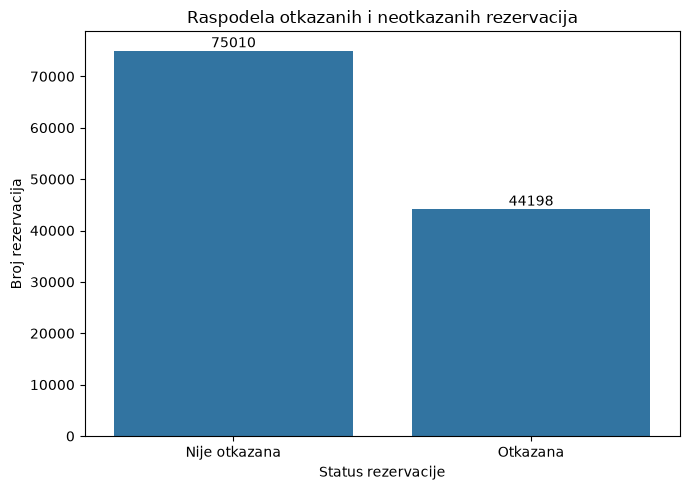

In [35]:
status_order = [
    "Nije otkazana",
    "Otkazana"
]

target_counts = (
    eda_df["status_otkazivanja"]
    .value_counts()
    .reindex(status_order)
)

target_percentages = (
    eda_df["status_otkazivanja"]
    .value_counts(normalize=True)
    .reindex(status_order) * 100
)

target_summary = pd.DataFrame({
    "Broj rezervacija": target_counts,
    "Procenat rezervacija": target_percentages
}).round(2)

display(target_summary)

plt.figure(figsize=(7, 5))

ax = sb.countplot(
    data=eda_df,
    x="status_otkazivanja",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Raspodela otkazanih i neotkazanih rezervacija")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

U skupu preovlađuju neotkazane rezervacije, kojih ima 75.010 (62,92%), dok je otkazanih rezervacija 44.198 (37,08%). Obe grupe zastupljene su u velikom broju, što omogućava njihovo dalje poređenje.

### 9.3. Tip hotela i otkazivanje

Proverava se da li se procenat otkazivanja razlikuje između gradskog i resort hotela.

,hotel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,City Hotel,79162,66.41,33078,41.79
1,Resort Hotel,40046,33.59,11120,27.77


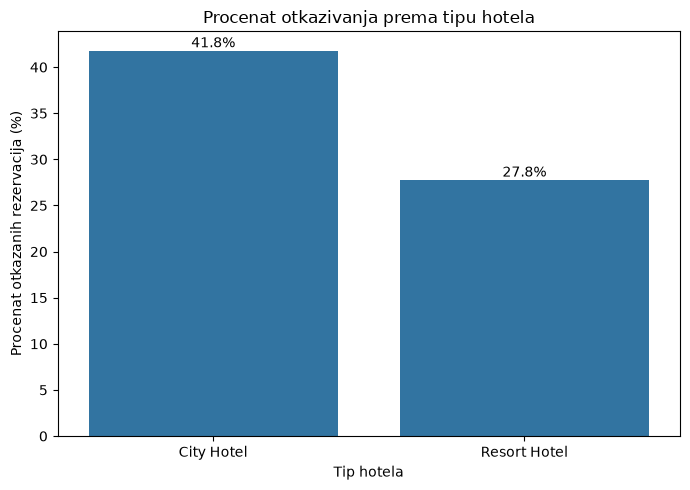

In [36]:
hotel_summary = create_cancellation_summary(eda_df, "hotel")

display(hotel_summary)

plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=hotel_summary,
    x="hotel",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu hotela")
plt.xlabel("Tip hotela")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

U posmatranom skupu uočava se viši procenat otkazivanja kod City Hotel-a (41,79%) nego kod Resort Hotel-a (27,77%). Gradski hoteli čine i veći deo skupa, sa 79.162 rezervacije, dok resort hoteli imaju 40.046 rezervacija.

### 9.4. Lead time i otkazivanje

`lead_time` predstavlja broj dana između rezervisanja i planiranog dolaska. Ovde se ispituje njegova povezanost sa statusom otkazivanja. Radi preglednijeg prikaza raspodele, izdvojene vrednosti nisu prikazane na boxplot-u, ali su zadržane u podacima.

,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75010,80.08,45.0,0,737
Otkazana,44198,144.89,113.0,0,629


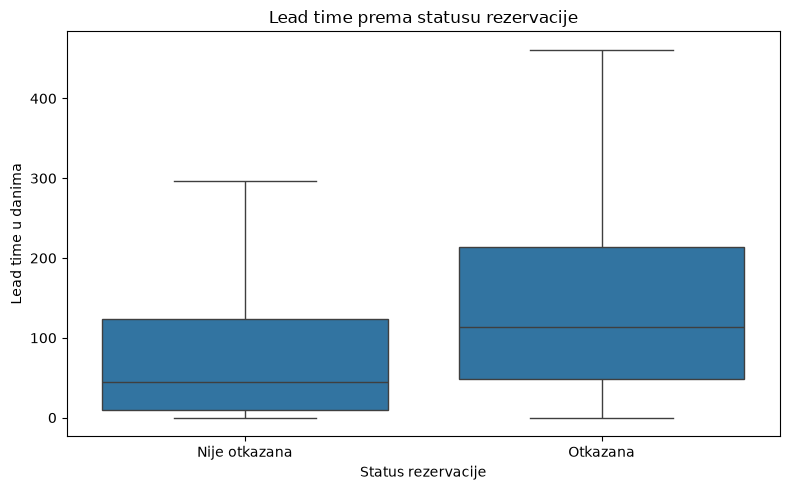

In [37]:
lead_time_statistics = (
    eda_df.groupby("status_otkazivanja")["lead_time"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(lead_time_statistics)


plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="lead_time",
    showfliers=False
)

plt.title("Lead time prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("Lead time u danima")
plt.tight_layout()
plt.show()

Otkazane rezervacije imaju veći `lead_time` od neotkazanih rezervacija. Medijana iznosi 113 dana kod otkazanih, dok je kod neotkazanih 45 dana. Boxplot pokazuje da su vrednosti `lead_time` kod otkazanih rezervacija raspoređene u širem opsegu, što ukazuje na veću varijabilnost u odnosu na neotkazane rezervacije.

Pored pojedinačnih vrednosti, `lead_time` je podeljen u nekoliko intervala kako bi se lakše uočilo kako se procenat otkazivanja menja sa dužinom perioda između rezervisanja i planiranog dolaska.

,lead_time_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0-30 dana,38580,32.36,7168,18.58
1,31-90 dana,29528,24.77,11140,37.73
2,91-180 dana,26420,22.16,11819,44.74
3,181-365 dana,21533,18.06,11942,55.46
4,Više od 365 dana,3147,2.64,2129,67.65


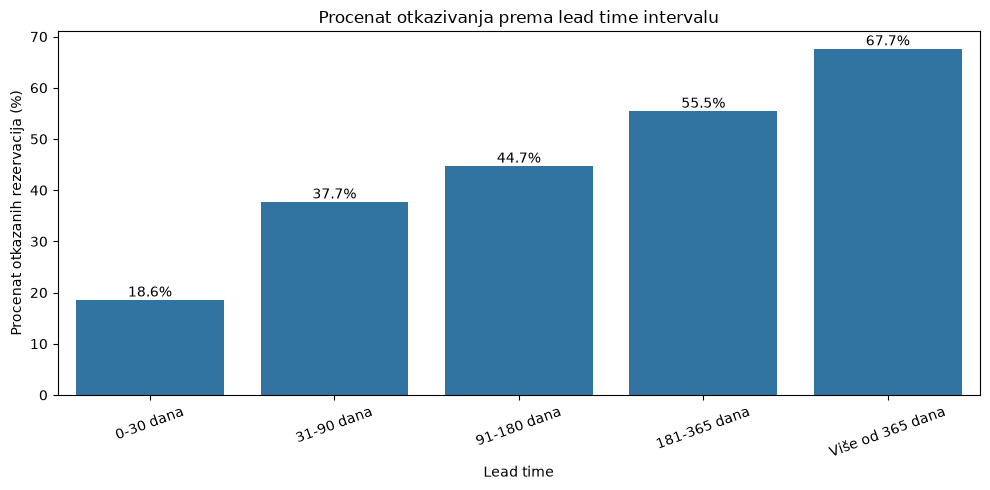

In [38]:
lead_time_bins = [
    -1,
    30,
    90,
    180,
    365,
    np.inf
]

lead_time_labels = [
    "0-30 dana",
    "31-90 dana",
    "91-180 dana",
    "181-365 dana",
    "Više od 365 dana"
]

eda_df["lead_time_group"] = pd.cut(
    eda_df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

lead_time_group_summary = create_cancellation_summary(
    eda_df,
    "lead_time_group"
)

display(lead_time_group_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=lead_time_group_summary,
    x="lead_time_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title("Procenat otkazivanja prema lead time intervalu")
plt.xlabel("Lead time")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Rezultati pokazuju da se sa povećanjem `lead_time` povećava i procenat otkazanih rezervacija. Najmanji procenat otkazivanja zabeležen je kod rezervacija sa `lead_time` do 30 dana (18,58%), dok najveći procenat ima grupa sa više od 365 dana (67,65%). Iako je poslednja grupa najmanje zastupljena, u njoj se uočava najveći udeo otkazanih rezervacija.

### 9.5. Tip depozita i otkazivanje

Tip depozita može biti povezan sa odlukom gosta da odustane od rezervacije, pa se porede zastupljenost i procenat otkazivanja za svaku kategoriju.
- `No Deposit` – Rezervacija je napravljena bez zahteva za uplatu depozita prilikom rezervisanja.
- `Non Refund` – Rezervacija je povezana sa uslovima koji ne predviđaju povraćaj uplaćenog depozita u slučaju otkazivanja.
- `Refundable` – Rezervacija je napravljena uz depozit koji može biti vraćen pod određenim uslovima.

,deposit_type,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Non Refund,14586,12.24,14493,99.36
1,No Deposit,104460,87.63,29669,28.40
2,Refundable,162,0.14,36,22.22


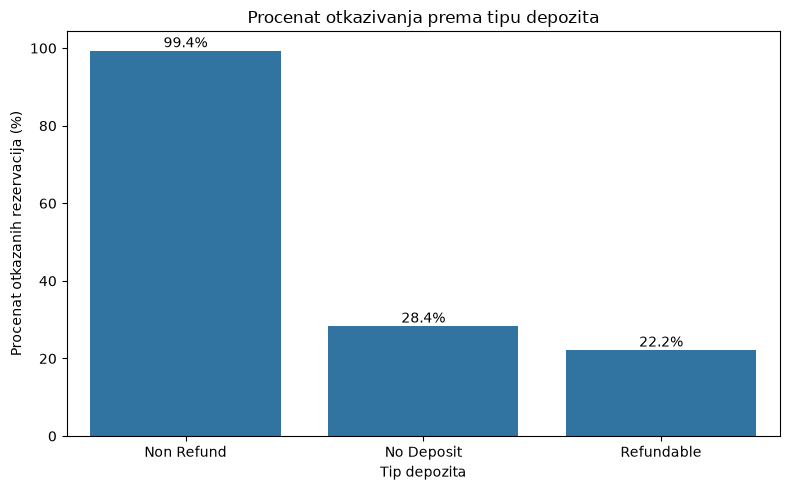

In [39]:
deposit_summary = (
    create_cancellation_summary(
        eda_df,
        "deposit_type"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    ).reset_index(drop=True)
)

display(deposit_summary)

plt.figure(figsize=(8, 5))

ax = sb.barplot(
    data=deposit_summary,
    x="deposit_type",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu depozita")
plt.xlabel("Tip depozita")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezervacije sa depozitom `Non Refund` izdvajaju se po veoma visokom procentu otkazivanja od 99,36%. Ovaj rezultat deluje neuobičajeno, ali njegov razlog nije moguće utvrditi samo na osnovu dostupnih podataka. Kod rezervacija bez depozita procenat otkazivanja iznosi 28,40%, dok kategorija `Refundable` ima 22,22% otkazivanja, ali obuhvata svega 162 rezervacije. Rezultati pokazuju izraženu povezanost između tipa depozita i statusa otkazivanja, bez pretpostavljanja razloga zbog kojeg se ovakav obrazac pojavljuje.

### 9.6. Tržišni segment i kanal rezervacije

Kolona `market_segment` opisuje tržišni segment rezervacije, dok `distribution_channel` označava kanal preko kojeg je rezervacija stigla. Cilj analize je da se utvrdi da li se procenat otkazivanja razlikuje između različitih segmenata i kanala distribucije.

Kolona `market_segment` označava tržišni segment iz kojeg potiče rezervacija, odnosno način na koji je gost ili grupa gostiju došla do hotela (na primer preko internet agencije, turističke agencije ili direktno). U nastavku se ispituje kako se procenat otkazivanja razlikuje između pojedinih tržišnih segmenata.

,market_segment,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,2,0.00,2,100.00
1,Groups,19790,16.60,12094,61.11
2,Online TA,56408,47.32,20735,36.76
3,Offline TA/TO,24181,20.28,8301,34.33
4,Aviation,235,0.20,52,22.13
5,Corporate,5282,4.43,991,18.76
6,Direct,12582,10.55,1934,15.37
7,Complementary,728,0.61,89,12.23


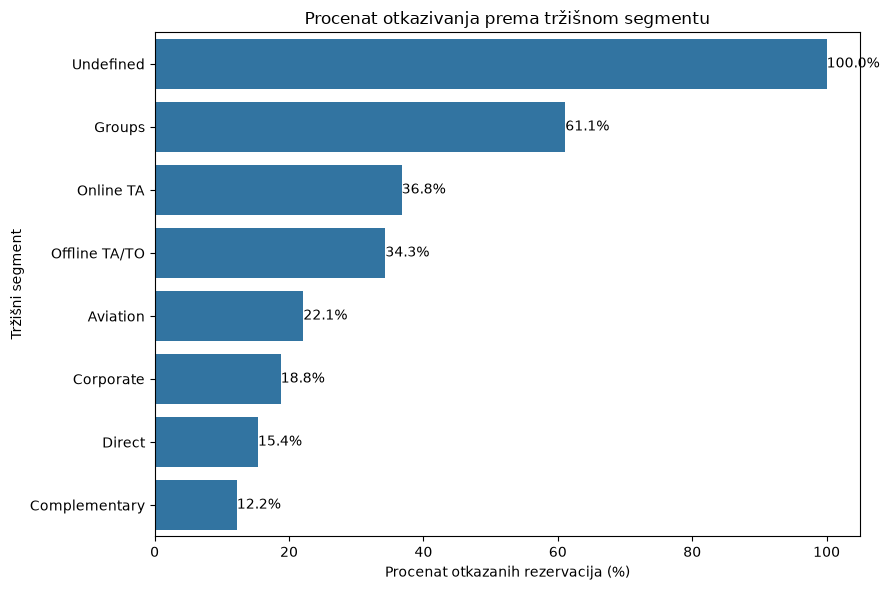

In [40]:
market_segment_summary = (
    create_cancellation_summary(
        eda_df,
        "market_segment"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(market_segment_summary)


plt.figure(figsize=(9, 6))

ax = sb.barplot(
    data=market_segment_summary,
    y="market_segment",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tržišnom segmentu")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Tržišni segment")
plt.tight_layout()
plt.show()

Najveći procenat otkazivanja ima kategorija `Undefined`, ali ona sadrži svega dve rezervacije i zbog toga nije reprezentativna. Među zastupljenijim segmentima najveći procenat otkazivanja ima `Groups` (61,11%), zatim `Online TA` (36,76%) i `Offline TA/TO` (34,33%). Najniži procenat otkazivanja zabeležen je kod segmenata `Direct` (15,37%) i `Complementary` (12,23%). Rezultati pokazuju da se procenat otkazivanja razlikuje između tržišnih segmenata.

### Kratak opis kategorija

* **Direct** – rezervacija je izvršena direktno kod hotela.
* **Online TA** – rezervacija je stigla preko internet turističke agencije (npr. Booking.com, Expedia).
* **Offline TA/TO** – rezervacija je stigla preko klasične turističke agencije ili turoperatora.
* **Corporate** – rezervacija je povezana sa poslovnim klijentima ili kompanijama.
* **Groups** – grupne rezervacije.
* **Complementary** – besplatne ili promotivne rezervacije koje hotel odobrava bez naplate.
* **Aviation** – rezervacije povezane sa avio-kompanijama ili njihovim posadama.
* **Undefined** – segment nije definisan u podacima.

Kolona `distribution_channel` opisuje kanal preko kojeg je rezervacija stigla do hotela. Cilj analize je da se utvrdi da li se procenat otkazivanja razlikuje između različitih kanala distribucije. Jedina nova kategorija u odnosu na `market_segment` je **GDS** (Global Distribution System), odnosno globalni distribucioni sistem koji koriste turističke agencije i avio-kompanije za rezervacije.

,distribution_channel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,5,0.00,4,80.00
1,TA/TO,97749,82.00,40135,41.06
2,Corporate,6651,5.58,1467,22.06
3,GDS,193,0.16,37,19.17
4,Direct,14610,12.26,2555,17.49


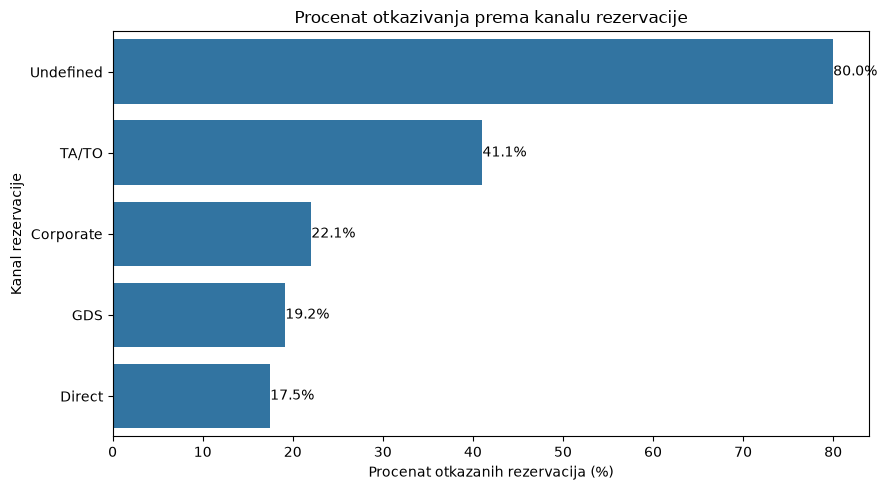

In [41]:
distribution_channel_summary = (
    create_cancellation_summary(
        eda_df,
        "distribution_channel"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(distribution_channel_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=distribution_channel_summary,
    y="distribution_channel",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema kanalu rezervacije")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Kanal rezervacije")
plt.tight_layout()
plt.show()

Zbog veoma malog broja rezervacija kategorija `Undefined` nije pogodna za izvođenje zaključaka. Kod ostalih kanala distribucije najveći procenat otkazivanja ima `TA/TO`, dok `Direct` ima najmanji. Rezultati pokazuju da se procenat otkazivanja razlikuje između kanala preko kojih su rezervacije stigle do hotela.

### 9.7. Prethodno ponašanje gosta

U ovom delu analizira se da li se ponašanje gostiju iz prethodnih rezervacija razlikuje između otkazanih i neotkazanih rezervacija. Za to se koriste podaci o tome da li je gost već ranije boravio u hotelu, koliko je prethodnih rezervacija otkazao i koliko ih je uspešno realizovao. Direktni identifikatori gostiju se ne koriste.

,repeated_guest_label,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Novi gost,115454,96.85,43648,37.81
1,Ponovljeni gost,3754,3.15,550,14.65


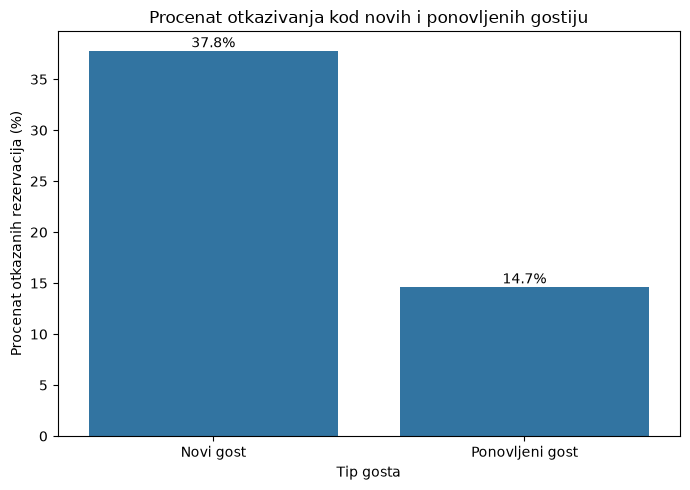

In [42]:
eda_df["repeated_guest_label"] = (
    eda_df["is_repeated_guest"]
    .map({
        0: "Novi gost",
        1: "Ponovljeni gost"
    })
)

repeated_guest_summary = create_cancellation_summary(
    eda_df,
    "repeated_guest_label"
)

display(repeated_guest_summary)


plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=repeated_guest_summary,
    x="repeated_guest_label",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja kod novih i ponovljenih gostiju")
plt.xlabel("Tip gosta")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Većinu rezervacija čine novi gosti (96,85%), dok ponovljeni gosti učestvuju sa 3,15%. Kod ponovljenih gostiju procenat otkazivanja iznosi 14,65%, što je znatno manje u odnosu na 37,81% kod novih gostiju. Rezultati pokazuju da se procenat otkazivanja razlikuje u zavisnosti od toga da li je gost ranije već boravio u hotelu.

,previous_cancellations_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez prethodnih otkazivanja,112729,94.56,38258,33.94
1,Jedno prethodno otkazivanje,6048,5.07,5712,94.44
2,Dva ili više,431,0.36,228,52.90


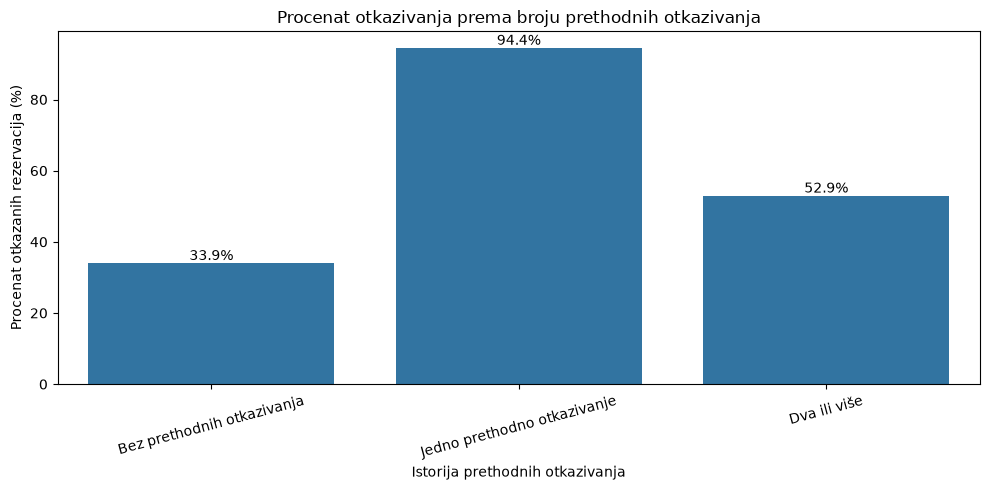

,previous_completed_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,115596,96.97,43998,38.06
1,1,1538,1.29,79,5.14
2,2-5,1322,1.11,72,5.45
3,6 ili više,752,0.63,49,6.52


In [43]:
previous_cancellations_bins = [
    -1,
    0,
    1,
    np.inf
]

previous_cancellations_labels = [
    "Bez prethodnih otkazivanja",
    "Jedno prethodno otkazivanje",
    "Dva ili više"
]

eda_df["previous_cancellations_group"] = pd.cut(
    eda_df["previous_cancellations"],
    bins=previous_cancellations_bins,
    labels=previous_cancellations_labels
)

previous_cancellations_summary = create_cancellation_summary(
    eda_df,
    "previous_cancellations_group"
)

display(previous_cancellations_summary)


plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=previous_cancellations_summary,
    x="previous_cancellations_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju prethodnih otkazivanja")
plt.xlabel("Istorija prethodnih otkazivanja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

previous_completed_bins = [
    -1,
    0,
    1,
    5,
    np.inf
]

previous_completed_labels = [
    "0",
    "1",
    "2-5",
    "6 ili više"
]

eda_df["previous_completed_group"] = pd.cut(
    eda_df["previous_bookings_not_canceled"],
    bins=previous_completed_bins,
    labels=previous_completed_labels
)

previous_completed_summary = create_cancellation_summary(
    eda_df,
    "previous_completed_group"
)

display(previous_completed_summary)

Većina rezervacija (94,56%) nema prethodnih otkazivanja, a u toj grupi procenat otkazivanja iznosi 33,94%. Kod gostiju sa jednim prethodnim otkazivanjem procenat otkazivanja raste na 94,44%. Grupa sa dva ili više prethodnih otkazivanja obuhvata svega 431 rezervaciju, što je znatno manje u odnosu na ostale grupe. Rezultati pokazuju izraženu razliku u procentu otkazivanja u zavisnosti od istorije prethodnih otkazivanja.

Sličan obrazac uočava se i kod prethodno realizovanih rezervacija. Gosti bez prethodnih uspešno realizovanih rezervacija imaju procenat otkazivanja od 38,06%, dok kod gostiju koji imaju jednu ili više prethodno realizovanih rezervacija taj procenat iznosi između 5,14% i 6,52%. Iako ove grupe obuhvataju mali deo skupa, procenat otkazivanja kod njih je znatno niži nego kod gostiju bez prethodno realizovanih rezervacija.

### 9.8. Posebni zahtevi i promene rezervacije

U ovom delu ispituje se povezanost broja posebnih zahteva i broja promena rezervacije sa otkazivanjem rezervacije.

,total_of_special_requests,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,70199,58.89,33533,47.77
1,1,33183,27.84,7316,22.05
2,2,12952,10.87,2866,22.13
3,3,2494,2.09,445,17.84
4,4,340,0.29,36,10.59
5,5,40,0.03,2,5.00


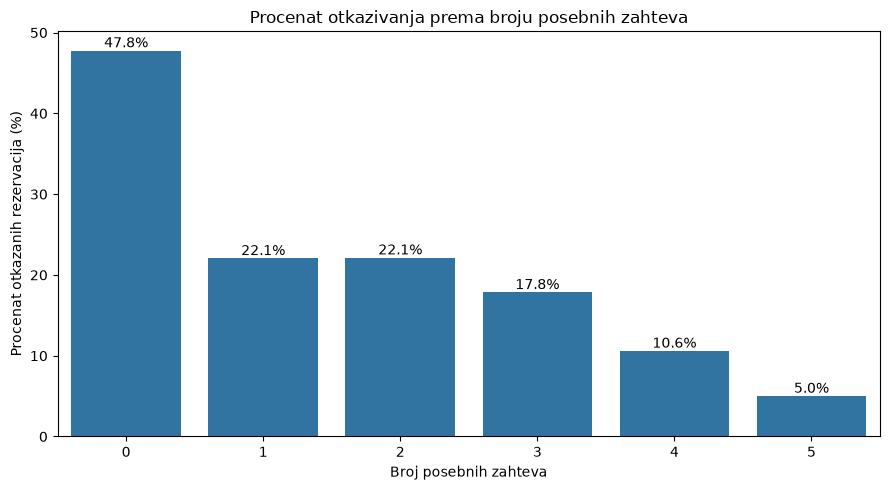

In [44]:
special_requests_summary = create_cancellation_summary(
    eda_df,
    "total_of_special_requests"
)

display(special_requests_summary)

plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=special_requests_summary,
    x="total_of_special_requests",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju posebnih zahteva")
plt.xlabel("Broj posebnih zahteva")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezultati pokazuju da se sa povećanjem broja posebnih zahteva smanjuje procenat otkazivanja rezervacija. Dok je kod rezervacija bez posebnih zahteva otkazano 47,77%, kod rezervacija sa tri, četiri i pet zahteva procenat otkazivanja iznosi 17,84%, 10,59% i 5,00%. Poslednje dve grupe sadrže mali broj rezervacija, ali se i pored toga uočava izražen obrazac opadanja procenta otkazivanja sa porastom broja posebnih zahteva.

,booking_changes_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez promena,101232,84.92,41369,40.87
1,Jedna promena,12665,10.62,1803,14.24
2,Dve ili više promena,5311,4.46,1026,19.32


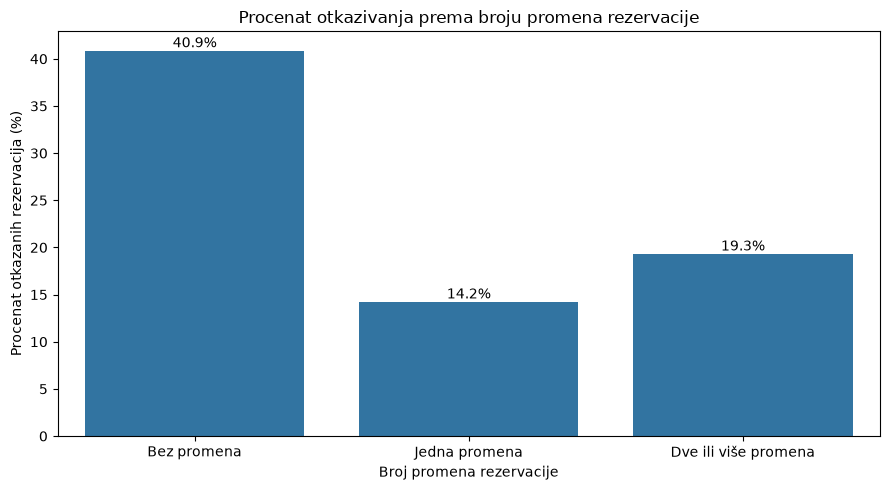

In [45]:
booking_changes_bins = [
    -1,
    0,
    1,
    np.inf
]

booking_changes_labels = [
    "Bez promena",
    "Jedna promena",
    "Dve ili više promena"
]

eda_df["booking_changes_group"] = pd.cut(
    eda_df["booking_changes"],
    bins=booking_changes_bins,
    labels=booking_changes_labels
)

booking_changes_summary = create_cancellation_summary(
    eda_df,
    "booking_changes_group"
)

display(booking_changes_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=booking_changes_summary,
    x="booking_changes_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju promena rezervacije")
plt.xlabel("Broj promena rezervacije")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Najveći deo rezervacija (84,92%) nije imao nijednu promenu nakon rezervisanja, a u toj grupi procenat otkazivanja iznosi 40,87%. Kod rezervacija sa jednom promenom procenat otkazivanja opada na 14,24%, dok kod rezervacija sa dve ili više promena iznosi 19,32%. Iako je procenat kod poslednje grupe nešto veći nego kod rezervacija sa jednom promenom, i dalje je znatno niži nego kod rezervacija bez promena. Rezultati pokazuju da su rezervacije kod kojih je izvršena makar jedna promena ređe otkazivane.

### 9.9. ADR i dužina boravka

U ovom delu ispituju se povezanost cene rezervacije (`adr` – Average Daily Rate, odnosno prosečna cena po noćenju) i ukupnog broja noćenja sa otkazivanjem rezervacije. Kolona `total_stay` privremeno se dodaje samo u `eda_df`, dok `clean_df` ostaje nepromenjen. Na boxplot grafikonima izdvojene vrednosti su sakrivene radi preglednijeg prikaza, ali su i dalje deo skupa podataka.

,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75010,100.17,92.7,0.0,510.0
Otkazana,44198,104.90,96.3,0.0,450.0


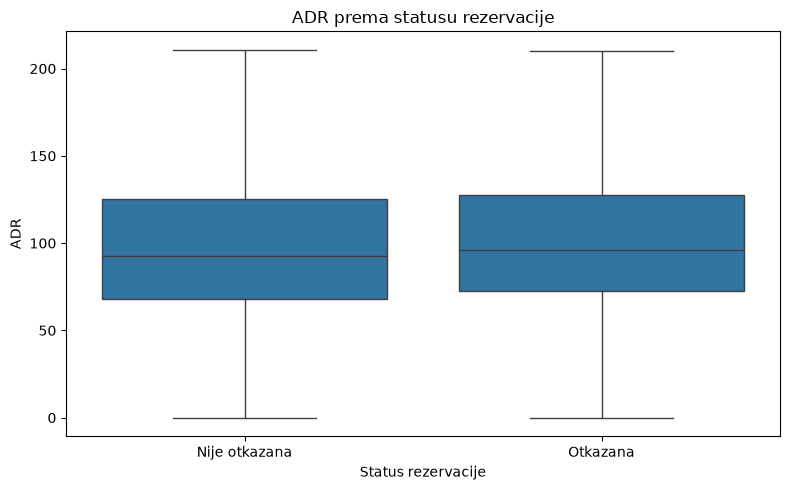

In [46]:
eda_df["total_stay"] = eda_df["stays_in_weekend_nights"] + eda_df["stays_in_week_nights"]

adr_statistics = (
    eda_df.groupby("status_otkazivanja")["adr"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(adr_statistics)

plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="adr",
    showfliers=False
)

plt.title("ADR prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("ADR")
plt.tight_layout()
plt.show()

Prosečna i medijalna vrednost ADR-a nešto su veće kod otkazanih rezervacija, ali su razlike male. Boxplot pokazuje da se raspodele u velikoj meri preklapaju, pa se na osnovu same vrednosti ADR-a ne može jasno razlikovati da li će rezervacija biti otkazana.

,total_stay_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez noćenja,645,0.54,23,3.57
1,1-3 noćenja,75700,63.50,28778,38.02
2,4-7 noćenja,37638,31.57,13519,35.92
3,8-14 noćenja,4796,4.02,1636,34.11
4,Više od 14 noćenja,429,0.36,242,56.41


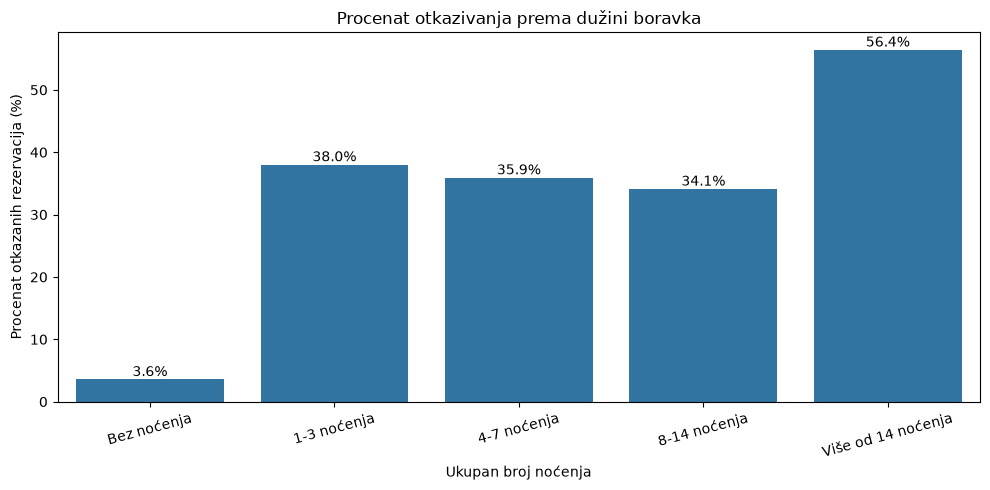

In [47]:
total_stay_bins = [
    -1,
    0,
    3,
    7,
    14,
    np.inf
]

total_stay_labels = [
    "Bez noćenja",
    "1-3 noćenja",
    "4-7 noćenja",
    "8-14 noćenja",
    "Više od 14 noćenja"
]

eda_df["total_stay_group"] = pd.cut(
    eda_df["total_stay"],
    bins=total_stay_bins,
    labels=total_stay_labels
)

total_stay_summary = create_cancellation_summary(
    eda_df,
    "total_stay_group"
)

display(total_stay_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=total_stay_summary,
    x="total_stay_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema dužini boravka")
plt.xlabel("Ukupan broj noćenja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Najveći deo rezervacija odnosi se na boravke od 1 do 3 noćenja (63,50%) i od 4 do 7 noćenja (31,57%). Kod ovih grupa procenat otkazivanja je sličan i kreće se između 34% i 38%. Rezervacije bez noćenja imaju veoma nizak procenat otkazivanja (3,57%), ali čine svega 0,54% skupa. Najveći procenat otkazivanja zabeležen je kod boravaka dužih od 14 noćenja (56,41%), međutim ova grupa obuhvata samo 429 rezervacija. Rezultati ukazuju da duži boravci mogu biti povezani sa većim procentom otkazivanja, ali se takvi boravci retko javljaju u posmatranom skupu.

### 9.10. Rezervacije prema mesecu i godini dolaska

U ovom delu ispituju se broj rezervacija i procenat otkazivanja prema mesecu i godini planiranog dolaska.

,arrival_date_month,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,January,5921,4.97,1806,30.50
1,February,8052,6.75,2693,33.45
2,March,9766,8.19,3147,32.22
3,April,11078,9.29,4518,40.78
4,May,11780,9.88,4677,39.70
5,June,10929,9.17,4534,41.49
6,July,12644,10.61,4737,37.46
7,August,13861,11.63,5237,37.78
8,September,10500,8.81,4115,39.19
9,October,11147,9.35,4246,38.09


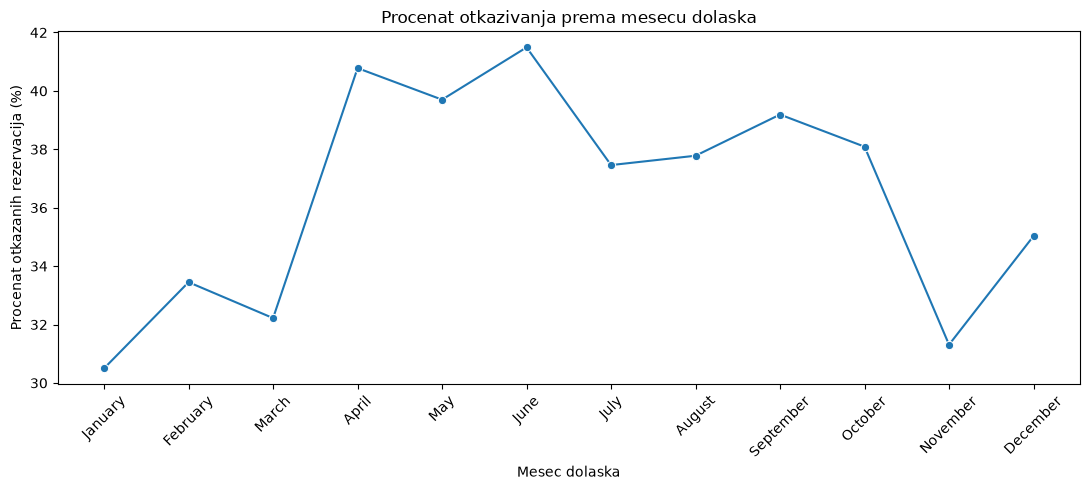

,arrival_date_year,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,2015,21967,18.43,8141,37.06
1,2016,56622,47.50,20323,35.89
2,2017,40619,34.07,15734,38.74


,Godina,Broj obuhvaćenih meseci,Obuhvaćeni meseci
0,2015,6,"July, August, September, October, November, De..."
1,2016,12,"January, February, March, April, May, June, Ju..."
2,2017,8,"January, February, March, April, May, June, Ju..."


In [48]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_summary = create_cancellation_summary(
    eda_df,
    "arrival_date_month"
)

month_summary["arrival_date_month"] = pd.Categorical(
    month_summary["arrival_date_month"],
    categories=month_order,
    ordered=True
)

month_summary = (
    month_summary
    .sort_values("arrival_date_month")
    .reset_index(drop=True)
)

display(month_summary)

plt.figure(figsize=(11, 5))

sb.lineplot(
    data=month_summary,
    x="arrival_date_month",
    y="Procenat otkazanih rezervacija",
    marker="o"
)

plt.title("Procenat otkazivanja prema mesecu dolaska")
plt.xlabel("Mesec dolaska")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_summary = (
    create_cancellation_summary(
        eda_df,
        "arrival_date_year"
    )
    .sort_values("arrival_date_year")
    .reset_index(drop=True)
)

display(year_summary)

year_month_coverage = (
    eda_df
    .groupby("arrival_date_year")
    .agg(
        broj_meseci=(
            "arrival_date_month",
            "nunique"
        ),
        obuhvaceni_meseci=(
            "arrival_date_month",
            lambda values: ", ".join(
                month
                for month in month_order
                if month in set(values)
            )
        )
    )
    .reset_index()
    .rename(columns={
        "arrival_date_year": "Godina",
        "broj_meseci": "Broj obuhvaćenih meseci",
        "obuhvaceni_meseci": "Obuhvaćeni meseci"
    })
)

display(year_month_coverage)

#### Mesec dolaska

Procenat otkazivanja razlikuje se između meseci. Najniže vrednosti zabeležene su u januaru (30,50%), martu (32,22%) i novembru (31,31%), dok su najveće u aprilu (40,78%) i junu (41,49%). Rezultati pokazuju da procenat otkazivanja nije isti tokom cele godine, već se razlikuje od meseca do meseca.

#### Godina dolaska

Procenat otkazivanja u dostupnim podacima iznosi 37,06% za 2015, 35,89% za 2016. i 38,74% za 2017. godinu. Ove vrednosti su približno slične, ali godine nisu jednako obuhvaćene: podaci za 2015. počinju u julu, 2016. obuhvata svih dvanaest meseci, dok se podaci za 2017. završavaju u avgustu. Zbog toga se poređenje godina prikazuje opisno i na osnovu njega se ne izvodi zaključak o dugoročnom rastu ili padu otkazivanja.

### 9.11. Statistička provera odabranih povezanosti

Grafikoni i tabele iz prethodnog dela pokazuju kako se procenat otkazivanja razlikuje između pojedinih grupa, ali na osnovu njih nije moguće utvrditi da li su uočene razlike statistički značajne ili su mogle nastati slučajno. Zato se u ovom delu primenjuju statistički testovi.

Testovi su primenjeni na nekoliko unapred odabranih promenljivih kod kojih su tokom eksplorativne analize uočene izraženije ili posebno zanimljive razlike. Nisu testirane sve analizirane kolone, jer veliki broj zapisa može dovesti do veoma male p-vrednosti čak i kada je povezanost slaba. Zbog toga se pored p-vrednosti posmatraju jačina povezanosti i opisne statistike.

Za kategorijske promenljive koristi se hi-kvadrat test nezavisnosti, kojim se proverava da li postoji statistički značajna povezanost između posmatrane promenljive i statusa otkazivanja rezervacije. Za numeričku promenljivu `lead_time` koristi se Mann–Whitney U test, kojim se proverava da li se njene vrednosti razlikuju između otkazanih i neotkazanih rezervacija.

Kategorija `Undefined` sadrži samo dve rezervacije kod promenljive `market_segment` i pet rezervacija kod promenljive `distribution_channel`. Zbog tako malog broja zapisa izostavljena je samo iz hi-kvadrat testova za te dve promenljive. Kategorija ostaje prisutna u `eda_df`, tabelama i grafikonima.

Rezultati se tumače pomoću p-vrednosti. Ako je p-vrednost manja od 0,05, smatra se da je razlika ili povezanost statistički značajna. P-vrednost ipak ne pokazuje koliko je povezanost jaka, pa se kod hi-kvadrat testa dodatno koristi Cramér-ov V.

In [49]:
from scipy.stats import chi2_contingency, mannwhitneyu

def format_p_value(value):
    if value < 0.001:
        return "< 0.001"

    return f"{value:.3f}"

def chi_square_test(data, column):
    test_data = data

    if column in [
        "market_segment",
        "distribution_channel"
    ]:
        test_data = data.loc[
            data[column] != "Undefined"
        ].copy()

    contingency_table = pd.crosstab(
        test_data[column],
        test_data["is_canceled"]
    )

    chi2, p_value, degrees_of_freedom, _ = chi2_contingency(
        contingency_table
    )

    total_count = contingency_table.to_numpy().sum()
    minimum_dimension = min(contingency_table.shape) - 1

    if minimum_dimension > 0:
        cramers_v = np.sqrt(
            chi2 / (total_count * minimum_dimension)
        )
    else:
        cramers_v = np.nan

    return {
        "Promenljiva": column,
        "Hi-kvadrat statistika": chi2,
        "Stepeni slobode": degrees_of_freedom,
        "p-vrednost": p_value,
        "Cramér-ov V": cramers_v
    }

categorical_test_columns = [
    "hotel",
    "deposit_type",
    "market_segment",
    "distribution_channel"
]

chi_square_results = pd.DataFrame([
    chi_square_test(eda_df, column)
    for column in categorical_test_columns
])

chi_square_results["Hi-kvadrat statistika"] = chi_square_results["Hi-kvadrat statistika"].round(2)
chi_square_results["Cramér-ov V"] = chi_square_results["Cramér-ov V"].round(3)
chi_square_results["p-vrednost"] = chi_square_results["p-vrednost"].apply(format_p_value)

display(chi_square_results)

lead_time_not_canceled = eda_df.loc[
    eda_df["is_canceled"] == 0,
    "lead_time"
]

lead_time_canceled = eda_df.loc[
    eda_df["is_canceled"] == 1,
    "lead_time"
]

mann_whitney_statistic, mann_whitney_p = mannwhitneyu(
    lead_time_not_canceled,
    lead_time_canceled,
    alternative="two-sided"
)

print(
    "Mann–Whitney U statistika:",
    round(mann_whitney_statistic, 2)
)

print(
    "p-vrednost:",
    format_p_value(mann_whitney_p)
)

print(
    "Medijana lead_time za neotkazane rezervacije:",
    round(lead_time_not_canceled.median(), 2)
)

print(
    "Medijana lead_time za otkazane rezervacije:",
    round(lead_time_canceled.median(), 2)
)

,Promenljiva,Hi-kvadrat statistika,Stepeni slobode,p-vrednost,Cramér-ov V
0,hotel,2239.04,1,< 0.001,0.137
1,deposit_type,27639.52,2,< 0.001,0.482
2,market_segment,8496.63,6,< 0.001,0.267
3,distribution_channel,3737.26,3,< 0.001,0.177


Mann–Whitney U statistika: 1030659376.0
p-vrednost: < 0.001
Medijana lead_time za neotkazane rezervacije: 45.0
Medijana lead_time za otkazane rezervacije: 113.0


U tabeli je za svaku testiranu promenljivu prikazana hi-kvadrat statistika, broj stepeni slobode, p-vrednost i Cramér-ov V.

Hi-kvadrat statistika pokazuje koliko se stvarni broj otkazanih i neotkazanih rezervacija razlikuje od broja koji bi se očekivao kada posmatrana promenljiva i otkazivanje ne bi bili povezani. Veća vrednost znači veće odstupanje od očekivanog rasporeda, ali zavisi i od veličine skupa i broja kategorija, pa se ne koristi samostalno za poređenje jačine povezanosti.

Stepeni slobode određuju koja se hi-kvadrat raspodela koristi za izračunavanje p-vrednosti. Njihov broj se dobija formulom `(r - 1) × (c - 1)`, gde je `r` broj kategorija posmatrane promenljive, a `c` broj kategorija ciljne promenljive. Pošto `is_canceled` ima dve kategorije, u ovom slučaju broj stepeni slobode jednak je broju kategorija posmatrane promenljive umanjenom za jedan. Stepeni slobode ne pokazuju jačinu povezanosti, već predstavljaju deo izračunavanja testa.

P-vrednost pokazuje da li je uočena povezanost statistički značajna. Kod svih testiranih promenljivih dobijena je p-vrednost manja od 0,001, pa je malo verovatno da su uočene razlike nastale slučajno. Zbog velikog broja rezervacija sama p-vrednost nije dovoljna za procenu značaja rezultata.

Cramér-ov V pokazuje jačinu povezanosti na skali od 0 do 1. Vrednost bliža nuli označava slabiju, a vrednost bliža jedinici jaču povezanost. Najizraženija povezanost među testiranim promenljivama uočena je kod `deposit_type`, zatim kod `market_segment`, dok `distribution_channel` i `hotel` pokazuju slabiju povezanost.

Mann–Whitney U test korišćen je za poređenje promenljive `lead_time` između otkazanih i neotkazanih rezervacija. Dobijena p-vrednost manja od 0,001 pokazuje da se raspodele `lead_time` statistički značajno razlikuju između ove dve grupe. Medijana iznosi 45 dana kod neotkazanih i 113 dana kod otkazanih rezervacija. U statistika predstavlja rezultat testa, ali se ne tumači samostalno, već zajedno sa p-vrednošću i medijanama.

### 9.12. Zaključak eksplorativne analize

Eksplorativna analiza pokazala je da su neotkazane rezervacije zastupljenije u skupu, ali da obe klase sadrže dovoljno zapisa za dalje poređenje. Najizraženije razlike u procentu otkazivanja uočene su kod tipa depozita, tržišnog segmenta, istorije prethodnih rezervacija i broja posebnih zahteva.

Ponovljeni gosti i gosti sa ranije realizovanim rezervacijama ređe su otkazivali rezervacije od novih gostiju i gostiju bez prethodno realizovanih rezervacija. Sa druge strane, kod gostiju sa prethodnim otkazivanjem zabeležen je veći procenat ponovnog otkazivanja. Rezervacije sa posebnim zahtevima ili naknadnim promenama takođe su ređe otkazivane od rezervacija bez takvih aktivnosti.

Izražena razlika uočena je kod promenljive `lead_time`. Medijana iznosi 45 dana kod neotkazanih i 113 dana kod otkazanih rezervacija, a procenat otkazivanja raste u grupama sa dužim periodom između rezervisanja i planiranog dolaska. Vrednosti ADR-a su, sa druge strane, veoma slične kod otkazanih i neotkazanih rezervacija, pa ova promenljiva sama po sebi ne razdvaja jasno dve grupe. Procenat otkazivanja razlikuje se i između meseci dolaska, dok se godine ne mogu potpuno ravnopravno porediti jer podaci ne obuhvataju sve mesece 2015. i 2017. godine.

Statistički testovi potvrđuju odabrane obrasce iz eksplorativne analize. Kod sve četiri testirane kategorijske promenljive dobijena je p-vrednost manja od 0,001, ali se jačina povezanosti razlikuje. Najizraženija povezanost uočena je kod tipa depozita, zatim kod tržišnog segmenta, dok kanal distribucije i tip hotela pokazuju slabiju povezanost. Mann–Whitney U test pokazao je da se raspodele `lead_time` statistički značajno razlikuju između otkazanih i neotkazanih rezervacija.

Dobijeni rezultati opisuju obrasce i povezanosti u posmatranom skupu, ali ne dokazuju da pojedine karakteristike uzrokuju otkazivanje. Takođe, na osnovu same eksplorativne analize ne može se zaključiti koliko će svaka promenljiva doprineti budućem modelu. To će biti provereno tokom kreiranja novih promenljivih, pripreme podataka, treniranja modela i evaluacije njegovih rezultata.

## 10. Kreiranje novih promenljivih

U ovom poglavlju se na osnovu postojećih kolona kreiraju nove promenljive koje objedinjuju povezane informacije o rezervaciji. Njihovim dodavanjem ne pretpostavlja se unapred da će model biti uspešniji. Kasnija analiza važnosti promenljivih pokazaće koliko se izabrani model oslanjao na njih.

Sve nove promenljive kreiraju se bez korišćenja ciljne kolone `is_canceled`, čime se sprečava unošenje informacija o ishodu rezervacije. Originalni `clean_df` ostaje nepromenjen, dok se za feature engineering i naredne korake koristi njegova kopija `model_df`.

In [50]:
model_df = clean_df.copy()

print("Dimenzije clean_df:", clean_df.shape)
print("Početne dimenzije model_df:", model_df.shape)

Dimenzije clean_df: (119208, 30)
Početne dimenzije model_df: (119208, 30)


Kreiranjem posebnog okvira `model_df` razdvajaju se očišćeni podaci od podataka koji će biti dodatno pripremljeni za modeliranje. Na taj način `clean_df` ostaje sačuvan u obliku dobijenom nakon čišćenja, pa se u svakom trenutku može proveriti koje su kolone naknadno dodate.

### 10.1. Informacije o boravku i gostima

Kolone `stays_in_weekend_nights` i `stays_in_week_nights` odvojeno prikazuju broj noćenja tokom vikenda i radnih dana. Njihovim sabiranjem dobija se promenljiva `total_stay`, koja predstavlja ukupan broj planiranih noćenja.

Na sličan način, sabiranjem broja odraslih, dece i beba dobija se promenljiva `total_guests`. Dodatno se kreira binarna promenljiva `has_children_or_babies`, koja ima vrednost 1 kada rezervacija uključuje najmanje jedno dete ili bebu, a vrednost 0 u suprotnom.

In [51]:
model_df["total_stay"] = model_df["stays_in_weekend_nights"] + model_df["stays_in_week_nights"]

model_df["total_guests"] = model_df["adults"] + model_df["children"] + model_df["babies"]

model_df["has_children_or_babies"] = (
    (model_df["children"] > 0) | (model_df["babies"] > 0)
).astype(int)

stay_and_guest_columns = [
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_stay",
    "adults",
    "children",
    "babies",
    "total_guests",
    "has_children_or_babies"
]

stay_and_guest_preview = pd.concat([
    model_df.loc[
        model_df["has_children_or_babies"] == 0,
        stay_and_guest_columns
    ].head(5),
    model_df.loc[
        model_df["has_children_or_babies"] == 1,
        stay_and_guest_columns
    ].head(5)
])

display(stay_and_guest_preview)

,stays_in_weekend_nights,stays_in_week_nights,total_stay,adults,children,babies,total_guests,has_children_or_babies
0,0,0,0,2,0,0,2,0
1,0,0,0,2,0,0,2,0
2,0,1,1,1,0,0,1,0
3,0,1,1,1,0,0,1,0
4,0,2,2,2,0,0,2,0
13,0,4,4,2,1,0,3,1
45,2,5,7,2,2,0,4,1
55,0,1,1,2,2,0,4,1
65,0,2,2,2,2,0,4,1
87,6,15,21,2,1,0,3,1


Nove promenljive ne zamenjuju originalne kolone, već ih dopunjuju. `total_stay` omogućava da se ukupna dužina boravka koristi kao jedna vrednost, dok `total_guests` daje ukupan broj osoba obuhvaćenih rezervacijom. Promenljiva `has_children_or_babies` izdvaja rezervacije koje uključuju decu ili bebe bez obzira na njihov tačan broj. U tabeli je prikazano po pet primera sa vrednošću 0 i 1, kako bi se jasno videlo na koji način je ova promenljiva formirana.

### 10.2. Sažete informacije o istoriji gosta

Kolone `previous_cancellations` i `previous_bookings_not_canceled` odvojeno prikazuju broj prethodno otkazanih i uspešno realizovanih rezervacija. Njihovim sabiranjem kreira se `total_previous_bookings`, koja predstavlja ukupan broj evidentiranih prethodnih rezervacija gosta.

Promenljiva `has_booking_history` označava da li gost ima makar jednu prethodnu rezervaciju. Dodatno se računa `previous_cancellation_rate`, odnosno udeo prethodnih rezervacija koje su bile otkazane. Vrednost 0,5, na primer, znači da je 50% prethodnih rezervacija bilo otkazano. Za goste bez prethodnih rezervacija ova vrednost se postavlja na 0, dok `has_booking_history` omogućava da se oni razlikuju od gostiju koji imaju istoriju bez otkazivanja.

In [52]:
model_df["total_previous_bookings"] = (
    model_df["previous_cancellations"]
    + model_df["previous_bookings_not_canceled"]
)

model_df["has_booking_history"] = (
    model_df["total_previous_bookings"] > 0
).astype(int)

model_df["previous_cancellation_rate"] = np.where(
    model_df["total_previous_bookings"] > 0,
    (
        model_df["previous_cancellations"]
        / model_df["total_previous_bookings"]
    ),
    0.0
)

booking_history_preview = (
    model_df.loc[
        model_df["has_booking_history"] == 1,
        [
            "previous_cancellations",
            "previous_bookings_not_canceled",
            "total_previous_bookings",
            "has_booking_history",
            "previous_cancellation_rate"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "total_previous_bookings",
            "previous_cancellation_rate"
        ]
    )
    .head(10)
)

display(booking_history_preview)

,previous_cancellations,previous_bookings_not_canceled,total_previous_bookings,has_booking_history,previous_cancellation_rate
13803,0,1,1,1,0.000000
13988,1,0,1,1,1.000000
13804,0,2,2,1,0.000000
13811,1,1,2,1,0.500000
14333,2,0,2,1,1.000000
13815,0,3,3,1,0.000000
13826,1,2,3,1,0.333333
14932,2,1,3,1,0.666667
14902,3,0,3,1,1.000000
13851,0,4,4,1,0.000000


Ove promenljive prikazuju istoriju gosta u sažetijem obliku. `total_previous_bookings` opisuje obim prethodnog iskustva sa hotelom, dok `previous_cancellation_rate` pravi razliku između gostiju koji imaju isti broj prethodnih rezervacija, ali različit odnos otkazanih i realizovanih rezervacija. Koliko se model oslanja na ove informacije biće razmotreno u kasnijoj analizi važnosti promenljivih.

### 10.3. Sezona planiranog dolaska

Kolona `arrival_date_month` sadrži pojedinačne mesece dolaska. Na osnovu nje kreira se promenljiva `arrival_season`, koja mesece grupiše u četiri godišnja doba. Time se omogućava posmatranje širih vremenskih obrazaca bez uklanjanja originalne informacije o mesecu dolaska.

Meseci decembar, januar i februar pripadaju zimi, mart, april i maj proleću, jun, jul i avgust letu, a septembar, oktobar i novembar jeseni.

In [53]:
season_mapping = {
    "December": "Winter",
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"
}

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

model_df["arrival_season"] = pd.Categorical(
    model_df["arrival_date_month"].map(
        season_mapping
    ),
    categories=season_order,
    ordered=True
)

season_summary = (
    model_df["arrival_season"]
    .value_counts(sort=False)
    .rename_axis("Sezona")
    .reset_index(name="Broj rezervacija")
)

display(season_summary)

,Sezona,Broj rezervacija
0,Winter,20732
1,Spring,32624
2,Summer,37434
3,Autumn,28418


Promenljiva `arrival_season` predstavlja sažet prikaz meseca planiranog dolaska. Originalna kolona `arrival_date_month` ostaje u skupu, pa su modelu dostupni i tačan mesec i šire grupisanje po godišnjim dobima. Kasnija analiza važnosti pokazaće koliko se model oslanjao na svaku od ovih informacija.

### 10.4. Grupe prema periodu između rezervisanja i dolaska

Eksplorativna analiza pokazala je da rezervacije napravljene u različitim vremenskim intervalima pre dolaska imaju različite procente otkazivanja. Zato se, pored originalne numeričke promenljive `lead_time`, kreira i kategorijska promenljiva `lead_time_group`.

Granice grupa iste su kao u eksplorativnoj analizi: do 30 dana, od 31 do 90 dana, od 91 do 180 dana, od 181 do 365 dana i više od 365 dana. Originalni `lead_time` ostaje u skupu, pa se informacija o tačnom broju dana ne gubi.

In [54]:
lead_time_bins = [
    -1,
    30,
    90,
    180,
    365,
    np.inf
]

lead_time_labels = [
    "0-30 dana",
    "31-90 dana",
    "91-180 dana",
    "181-365 dana",
    "Više od 365 dana"
]

model_df["lead_time_group"] = pd.cut(
    model_df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True,
    ordered=True
)

lead_time_group_summary = (
    model_df["lead_time_group"]
    .value_counts(sort=False)
    .rename_axis("Lead time grupa")
    .reset_index(name="Broj rezervacija")
)

lead_time_group_summary["Udeo u ukupnom skupu (%)"] = (
    lead_time_group_summary["Broj rezervacija"]
    / len(model_df) * 100
).round(2)

display(lead_time_group_summary)

,Lead time grupa,Broj rezervacija,Udeo u ukupnom skupu (%)
0,0-30 dana,38580,32.36
1,31-90 dana,29528,24.77
2,91-180 dana,26420,22.16
3,181-365 dana,21533,18.06
4,Više od 365 dana,3147,2.64


Kategorijska promenljiva `lead_time_group` omogućava da se prikažu različiti intervali perioda između rezervisanja i dolaska. Ona ne zamenjuje originalnu numeričku promenljivu, već predstavlja njen dodatni prikaz koji može biti koristan modelima koji teže prepoznaju nelinearne odnose. Koliko se izabrani model oslanjao na ovu izvedenu promenljivu biće prikazano u kasnijoj analizi važnosti promenljivih.

### 10.5. Pregled i provera kreiranih promenljivih

Nakon feature engineering-a proveravaju se tipovi novih promenljivih, broj njihovih jedinstvenih vrednosti i eventualne nedostajuće vrednosti. Takođe se proverava da broj redova nije promenjen i da nove kolone nisu dodate u originalni `clean_df`.

In [55]:
new_features = [
    "total_stay",
    "total_guests",
    "has_children_or_babies",
    "total_previous_bookings",
    "has_booking_history",
    "previous_cancellation_rate",
    "arrival_season",
    "lead_time_group"
]

new_feature_descriptions = {
    "total_stay": (
        "Ukupan broj planiranih noćenja"
    ),
    "total_guests": (
        "Ukupan broj odraslih, dece i beba"
    ),
    "has_children_or_babies": (
        "Da li rezervacija uključuje dete ili bebu"
    ),
    "total_previous_bookings": (
        "Ukupan broj prethodnih rezervacija gosta"
    ),
    "has_booking_history": (
        "Da li gost ima prethodne rezervacije"
    ),
    "previous_cancellation_rate": (
        "Udeo otkazanih prethodnih rezervacija"
    ),
    "arrival_season": (
        "Godišnje doba planiranog dolaska"
    ),
    "lead_time_group": (
        "Interval perioda između rezervisanja i dolaska"
    )
}

feature_engineering_summary = pd.DataFrame({
    "Nova promenljiva": new_features,
    "Opis": [
        new_feature_descriptions[column]
        for column in new_features
    ],
    "Tip podatka": [
        str(model_df[column].dtype)
        for column in new_features
    ],
    "Broj jedinstvenih vrednosti": [
        model_df[column].nunique(dropna=False)
        for column in new_features
    ],
    "Broj nedostajućih vrednosti": [
        model_df[column].isna().sum()
        for column in new_features
    ]
})

display(feature_engineering_summary)

print("Dimenzije clean_df:", clean_df.shape)
print("Dimenzije model_df:", model_df.shape)
print("Broj dodatih promenljivih:", len(new_features))

assert len(model_df) == len(clean_df)

assert model_df.shape[1] == (
    clean_df.shape[1] + len(new_features)
)

assert (
    model_df[new_features]
    .isna()
    .sum()
    .sum()
    == 0
)

assert not any(
    column in clean_df.columns
    for column in new_features
)

print("Provere su uspešno završene.")

,Nova promenljiva,Opis,Tip podatka,Broj jedinstvenih vrednosti,Broj nedostajućih vrednosti
0,total_stay,Ukupan broj planiranih noćenja,int64,42,0
1,total_guests,"Ukupan broj odraslih, dece i beba",int64,14,0
2,has_children_or_babies,Da li rezervacija uključuje dete ili bebu,int64,2,0
3,total_previous_bookings,Ukupan broj prethodnih rezervacija gosta,int64,77,0
4,has_booking_history,Da li gost ima prethodne rezervacije,int64,2,0
5,previous_cancellation_rate,Udeo otkazanih prethodnih rezervacija,float64,111,0
6,arrival_season,Godišnje doba planiranog dolaska,category,4,0
7,lead_time_group,Interval perioda između rezervisanja i dolaska,category,5,0


Dimenzije clean_df: (119208, 30)
Dimenzije model_df: (119208, 38)
Broj dodatih promenljivih: 8
Provere su uspešno završene.


### 10.6. Čuvanje skupa pripremljenog za modeliranje

Posle kreiranja i provere novih promenljivih, `model_df` se čuva kao poseban CSV fajl. I ovde se koristi `index=False`, a ponovnim učitavanjem fajla proverava se da su broj redova, broj kolona i nazivi kolona ostali nepromenjeni.


In [56]:
from pathlib import Path

model_ready_output_path = Path("../data/hotel_booking_model_ready.csv")
model_ready_output_path.parent.mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    model_ready_output_path,
    index=False
)

saved_model_df = pd.read_csv(model_ready_output_path)

assert model_ready_output_path.is_file()
assert saved_model_df.shape == model_df.shape
assert saved_model_df.columns.tolist() == model_df.columns.tolist()

print("Skup pripremljen za modeliranje je uspešno sačuvan.")
print("Putanja:", model_ready_output_path)
print("Dimenzije sačuvanog skupa:", saved_model_df.shape)


Skup pripremljen za modeliranje je uspešno sačuvan.
Putanja: ..\data\hotel_booking_model_ready.csv
Dimenzije sačuvanog skupa: (119208, 38)


Fajl `hotel_booking_model_ready.csv` sadrži **119.208 redova i 38 kolona**, odnosno očišćene podatke dopunjene sa osam novih promenljivih. Provera potvrđuje da je fajl uspešno napravljen bez dodatne indeksne kolone.


### 10.7. Zaključak kreiranja novih promenljivih

Feature engineering-om je kreirano osam novih promenljivih koje opisuju ukupno trajanje boravka, ukupan broj gostiju, prisustvo dece ili beba, istoriju prethodnih rezervacija, odnos prethodnih otkazivanja, sezonu dolaska i grupu kojoj pripada vrednost `lead_time`.

Broj redova ostao je nepromenjen, dok je broj kolona povećan sa 30 na 38. Nove promenljive ne koriste ciljnu kolonu `is_canceled` i nisu dodate u originalni `clean_df`, već samo u njegovu kopiju `model_df`.

Originalne kolone od kojih su nove promenljive izvedene zadržane su u skupu. Kasnija analiza važnosti pokazaće koliko se izabrani model oslanjao na originalne, a koliko na izvedene promenljive. U ovom radu nije posebno poređen model sa novim promenljivama i model bez njih, pa se neće tvrditi da su one same poboljšale ukupan rezultat.

U ovoj fazi nisu kreirane dodatne promenljive iz kolona `assigned_room_type`, `booking_changes` i `days_in_waiting_list`, jer pre modeliranja treba odrediti da li su te informacije dostupne u trenutku u kojem bi model trebalo da predviđa otkazivanje. Time se smanjuje rizik da model koristi podatke koji bi u realnoj primeni postali poznati tek kasnije.

Sledeći korak obuhvata definisanje trenutka predviđanja, izbor kolona koje će biti dostupne modelu, podelu podataka na trening i test skup i pripremu numeričkih i kategorijskih promenljivih.

## 11. Priprema podataka za modeliranje

U ovom poglavlju podaci se pripremaju za poređenje modela mašinskog učenja. Najpre se definiše trenutak u kojem model daje predviđanje, zatim se odvajaju ciljna promenljiva i prediktori, formiraju trening i test skup i definiše postupak transformacije numeričkih i kategorijskih kolona.

Test skup će ostati odvojen i neće se koristiti za izbor modela niti za podešavanje hiperparametara. Sve transformacije biće deo pipeline-a kako bi se učile isključivo na podacima koji se u datom trenutku koriste za treniranje.

### 11.1. Definisanje trenutka predviđanja

Pretpostavlja se da model predviđa verovatnoću otkazivanja odmah nakon kreiranja rezervacije. Ovakav trenutak predviđanja omogućava hotelu da dovoljno rano prepozna rezervacije sa povećanim rizikom od otkazivanja.

Zbog toga model sme da koristi samo informacije koje su dostupne u trenutku rezervisanja. Kolone `assigned_room_type`, `booking_changes` i `days_in_waiting_list` neće biti korišćene kao prediktori: dodeljeni tip sobe može biti određen ili promenjen naknadno, broj promena rezervacije nastaje tokom njenog trajanja, a konačan broj dana na listi čekanja nije poznat odmah nakon rezervisanja.

Ove kolone se ne brišu iz `model_df`, već se samo izostavljaju prilikom formiranja skupa prediktora. Time se čuvaju pripremljeni podaci, a istovremeno se smanjuje rizik od vremenskog curenja informacija.

### 11.2. Izbor promenljivih i odvajanje ciljne promenljive

Izbor promenljivih (feature selection) u ovom radu prvenstveno se zasniva na njihovom značenju i dostupnosti u trenutku predviđanja. Tokom čišćenja uklonjeni su direktni identifikatori gostiju i kolone koje otkrivaju konačan ishod rezervacije, dok se sada izostavljaju `assigned_room_type`, `booking_changes` i `days_in_waiting_list`, jer njihove konačne vrednosti nisu pouzdano poznate odmah nakon kreiranja rezervacije. Preostale promenljive nisu unapred uklanjane samo na osnovu rezultata eksplorativne analize, već će njihov značaj kasnije biti razmotren kroz analizu važnosti izabranog modela.

Ciljna promenljiva `is_canceled` izdvaja se u objekat `y`, dok se u `X` smeštaju 34 izabrane promenljive koje će modeli koristiti za predviđanje.

In [57]:
target_column = "is_canceled"

columns_unavailable_at_prediction = [
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

X = model_df.drop(
    columns=[
        target_column,
        *columns_unavailable_at_prediction
    ]
).copy()

y = model_df[target_column].copy()

print("Dimenzije model_df:", model_df.shape)
print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)
print("Broj prediktora:", X.shape[1])

print("\nKolone izostavljene iz modeliranja:")
for column in columns_unavailable_at_prediction:
    print("-", column)

assert target_column not in X.columns
assert all(
    column not in X.columns
    for column in columns_unavailable_at_prediction
)
assert len(X) == len(y)
assert X.index.equals(y.index)

print("\nProvere su uspešno završene.")

Dimenzije model_df: (119208, 38)
Dimenzije X: (119208, 34)
Dimenzije y: (119208,)
Broj prediktora: 34

Kolone izostavljene iz modeliranja:
- assigned_room_type
- booking_changes
- days_in_waiting_list

Provere su uspešno završene.


Ciljna promenljiva je uspešno odvojena od prediktora. `X` sadrži 34 promenljive dostupne modelu u trenutku rezervisanja, dok `y` sadrži status otkazivanja za svih 119.208 rezervacija. Okvir `model_df` nije promenjen.

### 11.3. Podela na trening i test skup

Podaci se dele tako da se približno 80% rezervacija koristi za treniranje i izbor modela, dok se približno 20% čuva za konačnu procenu izabranog modela. Pošto u skupu postoje rezervacije sa identičnim vrednostima prediktora, svakom jedinstvenom profilu dodeljuje se grupna oznaka. Podela pomoću `StratifiedGroupKFold` sprečava da isti profil bude prisutan i u trening i u test skupu, uz približno očuvanje odnosa otkazanih i neotkazanih rezervacija.

In [58]:
from sklearn.model_selection import StratifiedGroupKFold

profile_groups = pd.util.hash_pandas_object(
    X,
    index=False
).astype("uint64")

train_test_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, test_indices = next(
    train_test_splitter.split(
        X,
        y,
        groups=profile_groups
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()
groups_train = profile_groups.iloc[train_indices].copy()
groups_test = profile_groups.iloc[test_indices].copy()

print("Dimenzije X_train:", X_train.shape)
print("Dimenzije X_test:", X_test.shape)
print("Dimenzije y_train:", y_train.shape)
print("Dimenzije y_test:", y_test.shape)
print("Broj grupa u trening skupu:", groups_train.nunique())
print("Broj grupa u test skupu:", groups_test.nunique())

Dimenzije X_train: (95365, 34)
Dimenzije X_test: (23843, 34)
Dimenzije y_train: (95365,)
Dimenzije y_test: (23843,)
Broj grupa u trening skupu: 67856
Broj grupa u test skupu: 17013


Proverava se da li je grupna stratifikovana podela približno sačuvala raspodelu ciljne promenljive, da li su indeksi prediktora usklađeni sa odgovarajućim vrednostima ciljne promenljive i da li između trening i test skupa postoji preklapanje identičnih profila rezervacija.

In [59]:
target_split_summary = pd.DataFrame({
    "Ceo skup (%)": (
        y.value_counts(normalize=True).sort_index() * 100
    ),
    "Trening skup (%)": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ),
    "Test skup (%)": (
        y_test.value_counts(normalize=True).sort_index() * 100
    )
}).round(2)

target_split_summary.index = [
    "Nije otkazana",
    "Otkazana"
]

display(target_split_summary)

shared_profile_groups = np.intersect1d(
    groups_train.unique(),
    groups_test.unique()
)

assert len(X_train) + len(X_test) == len(X)
assert len(y_train) + len(y_test) == len(y)
assert set(X_train.index).isdisjoint(X_test.index)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert len(shared_profile_groups) == 0

print("Broj zajedničkih profila:", len(shared_profile_groups))
print("Train/test podela je uspešno proverena.")

,Ceo skup (%),Trening skup (%),Test skup (%)
Nije otkazana,62.92,62.92,62.92
Otkazana,37.08,37.08,37.08


Broj zajedničkih profila: 0
Train/test podela je uspešno proverena.


Grupna stratifikovana podela sačuvala je približno isti udeo otkazanih i neotkazanih rezervacija u trening i test skupu. Nijedan identičan profil prediktora nije prisutan u oba skupa. Test skup se od ovog trenutka neće koristiti za izbor modela niti za podešavanje njegovih hiperparametara.

### 11.4. Razdvajanje numeričkih i kategorijskih kolona

Numeričke i kategorijske promenljive potrebno je pripremiti na različite načine. Numeričke vrednosti će se skalirati, dok će se kategorijske vrednosti pretvoriti u oblik koji modeli mogu da koriste. Podela se najpre vrši na osnovu tipova podataka u trening skupu. Među kategorijske kolone uključene su izvedene promenljive `arrival_season` i `lead_time_group`, kao i `agent` i `company`. Iako su vrednosti u kolonama `agent` i `company` zapisane kao brojevi, one predstavljaju identifikacione oznake, pa se obrađuju kao kategorije.

In [60]:
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

identifier_columns = [
    "agent",
    "company"
]

numeric_columns = [
    column
    for column in numeric_columns
    if column not in identifier_columns
]

categorical_columns = (
    categorical_columns + identifier_columns
)

print("Broj numeričkih kolona:", len(numeric_columns))
print("Broj kategorijskih kolona:", len(categorical_columns))

print("\nNumeričke kolone:")
print(numeric_columns)

print("\nKategorijske kolone:")
print(categorical_columns)

assert set(numeric_columns).isdisjoint(categorical_columns)
assert set(numeric_columns + categorical_columns) == set(X_train.columns)

print("\nSve kolone su uspešno razvrstane.")

Broj numeričkih kolona: 21
Broj kategorijskih kolona: 13

Numeričke kolone:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests', 'has_children_or_babies', 'total_previous_bookings', 'has_booking_history', 'previous_cancellation_rate']

Kategorijske kolone:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'lead_time_group', 'agent', 'company']

Sve kolone su uspešno razvrstane.


### 11.5. Definisanje preprocesora

Za numeričke kolone definiše se popunjavanje eventualnih nedostajućih vrednosti medijanom i standardizacija pomoću `StandardScaler`. Skaliranje je naročito važno za modele osetljive na različite opsege promenljivih, kao što je logistička regresija.

Za kategorijske kolone eventualne nedostajuće vrednosti popunjavaju se najčešćom kategorijom, nakon čega se primenjuje one-hot kodiranje. Parametar `handle_unknown="ignore"` omogućava obradu kategorije koja se kasnije pojavi u test skupu, čak i ako nije postojala u podacima na kojima je transformacija naučena.

`ColumnTransformer` objedinjuje pripremu numeričkih i kategorijskih kolona. U ovoj fazi samo su definisana pravila pripreme, dok će se potrebne vrednosti, poput medijane, parametara skaliranja i kategorija za kodiranje, određivati kasnije na osnovu podataka za treniranje. Preprocesor će biti povezan sa svakim modelom u okviru pipeline-a, kako validacioni i test podaci ne bi uticali na pripremu trening podataka.

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_columns
        )
    ]
)

print("Preprocesor je uspešno definisan.")
print("Preprocesor još nije treniran.")

Preprocesor je uspešno definisan.
Preprocesor još nije treniran.


### 11.6. Provera povezivanja preprocesora i modela

Da bi se proverilo da li priprema podataka funkcioniše bez curenja informacija, definiše se probni pipeline sa `DummyClassifier` modelom. Pipeline povezuje preprocesor i model u jednu celinu. Pozivom metode `fit` nad trening skupom i preprocesor i model uče isključivo iz `X_train` i `y_train`.

Dummy model u ovom koraku služi samo kao tehnička provera pipeline-a. Njegovo detaljno poređenje sa ostalim modelima biće sprovedeno u narednom poglavlju pomoću unakrsne validacije.

In [62]:
from sklearn.dummy import DummyClassifier

validation_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

validation_pipeline.fit(X_train, y_train)
validation_predictions = validation_pipeline.predict(X_train.head(10))

print("Probna predviđanja:", validation_predictions)
print("Broj probnih predviđanja:", len(validation_predictions))

assert len(validation_predictions) == 10
assert set(validation_predictions).issubset(set(y_train.unique()))

print("Pipeline i preprocesor uspešno funkcionišu.")

Probna predviđanja: [0 0 0 0 0 0 0 0 0 0]
Broj probnih predviđanja: 10
Pipeline i preprocesor uspešno funkcionišu.


### 11.7. Zaključak pripreme podataka za modeliranje

Model je definisan tako da predviđa otkazivanje odmah nakon kreiranja rezervacije. Zbog toga su iz skupa prediktora izostavljene kolone `assigned_room_type`, `booking_changes` i `days_in_waiting_list`, čije vrednosti mogu nastati ili se promeniti nakon rezervisanja.

Prediktori i ciljna promenljiva podeljeni su na grupno stratifikovane trening i test skupove u približnom odnosu 80:20. Raspodela ciljne promenljive ostala je gotovo nepromenjena u oba skupa, a provera je pokazala da nema zajedničkih identičnih rezervacionih profila. Test skup je sačuvan za konačnu procenu izabranog modela.

Numeričke i kategorijske kolone razdvojene su na osnovu trening skupa. Pomoću `ColumnTransformer` definisani su odgovarajući postupci popunjavanja, skaliranja i kodiranja. Preprocesor je povezan sa probnim modelom unutar pipeline-a i uspešno je provereno da radi nad trening podacima.

Sledeći korak je definisanje početnih modela i njihovo poređenje pomoću unakrsne validacije sprovedene isključivo na trening skupu.

## 12. Definisanje i poređenje početnih modela

Nakon pripreme podataka mogu se definisati prvi klasifikacioni modeli. Cilj ovog poglavlja nije da se odmah pronađe konačan model, već da se pod jednakim uslovima uporedi nekoliko različitih pristupa i utvrdi koji od njih daju najbolje početne rezultate.

Poređenje se obavlja isključivo na trening skupu. Test skup ostaje odvojen i biće upotrebljen tek kada se završe izbor modela i podešavanje hiperparametara.

### 12.1. Izbor početnih modela

Za početno poređenje izabrano je pet modela koji predstavljaju različite pristupe klasifikaciji.

- `DummyClassifier` služi kao najjednostavnija početna referenca. On ne uči odnose u podacima, već u ovom slučaju svaku rezervaciju svrstava u zastupljeniju klasu. Ostali modeli treba da ostvare bolje rezultate od ove polazne vrednosti.
- Logistička regresija predstavlja jednostavan linearni model. Korisna je kao osnovni model jer se brzo trenira i pokazuje koliko se dobro otkazivanje može predvideti bez složenijih nelinearnih pravila.
- Stablo odlučivanja može da prepozna složenije odnose između promenljivih i da formira pravila na osnovu njihovih kombinacija. Njegove odluke se relativno lako mogu pratiti i objasniti, ali složeno stablo može biti previše prilagođeno trening podacima.
- Random Forest kombinuje veći broj stabala odlučivanja. Na taj način obično daje stabilnija predviđanja od jednog stabla, ali je složeniji i zahteva više vremena za treniranje.
- XGBoost takođe koristi veći broj stabala, ali ih gradi redom, tako da svako novo stablo pokušava da ispravi greške prethodnih. Ovaj model se često pokazuje uspešnim kod tabelarnih podataka i predstavlja drugačiji način kombinovanja većeg broja stabala.

In [63]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = {
    "DummyClassifier": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistička regresija": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Stablo odlučivanja": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=25,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    )
}

print("Modeli izabrani za početno poređenje:")
for model_name in models:
    print("-", model_name)

Modeli izabrani za početno poređenje:
- DummyClassifier
- Logistička regresija
- Stablo odlučivanja
- Random Forest
- XGBoost


### 12.2. Povezivanje preprocesora i modela

Za svaki izabrani model formira se poseban pipeline koji sadrži preprocesor iz prethodnog poglavlja i sam model. Time se obezbeđuje da svi modeli dobiju podatke pripremljene na isti način.

Funkcija `clone` pravi novu, netreniranu kopiju preprocesora za svaki pipeline. Zbog toga modeli ne dele već izračunate vrednosti, kao što su medijane, parametri skaliranja ili kategorije koje je zapamtio `OneHotEncoder`.

In [64]:
from sklearn.base import clone

model_pipelines = {
    model_name: Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )
    for model_name, model in models.items()
}

print("Broj formiranih pipeline-a:", len(model_pipelines))

for model_name, model_pipeline in model_pipelines.items():
    print(
        model_name,
        "->",
        list(model_pipeline.named_steps.keys())
    )

assert len(model_pipelines) == len(models)
assert all(
    list(model_pipeline.named_steps.keys())
    == ["preprocessor", "model"]
    for model_pipeline in model_pipelines.values()
)

print("Pipeline-i su uspešno formirani.")

Broj formiranih pipeline-a: 5
DummyClassifier -> ['preprocessor', 'model']
Logistička regresija -> ['preprocessor', 'model']
Stablo odlučivanja -> ['preprocessor', 'model']
Random Forest -> ['preprocessor', 'model']
XGBoost -> ['preprocessor', 'model']
Pipeline-i su uspešno formirani.


### 12.3. Metrike za poređenje modela

Rezultati se ne procenjuju samo pomoću accuracy vrednosti, jer ona pokazuje ukupan udeo tačnih predviđanja, ali ne govori dovoljno o tome kako model prepoznaje otkazane rezervacije. Zato se koristi više metrika:

- `accuracy` predstavlja udeo svih rezervacija koje su pravilno klasifikovane;
- `precision` pokazuje koliko je među rezervacijama koje je model označio kao otkazane zaista bilo otkazano;
- `recall` pokazuje koliki deo svih stvarno otkazanih rezervacija je model uspeo da pronađe;
- `F1` predstavlja ravnotežu između precision i recall vrednosti;
- `ROC-AUC` meri koliko dobro model razlikuje otkazane od neotkazanih rezervacija kroz različite pragove odlučivanja.

U ovom problemu posebno je važno pratiti recall, jer nizak recall znači da je model propustio veliki broj rezervacija koje su kasnije otkazane. Ipak, model se neće birati samo prema jednoj metrici, već će se posmatrati celokupan odnos rezultata.

In [65]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    make_scorer
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc"
}

print("Metrike za poređenje:")
for metric_name in scoring_metrics:
    print("-", metric_name)

Metrike za poređenje:
- accuracy
- precision
- recall
- f1
- roc_auc


### 12.4. Unakrsna validacija na trening skupu

Jedna podela trening podataka mogla bi slučajno da bude povoljnija za neki model. Zbog toga se modeli porede pomoću petostruke grupne stratifikovane unakrsne validacije. Trening skup se deli na pet delova, pri čemu svi redovi istog rezervacionog profila ostaju u istom delu. U svakom krugu četiri dela koriste se za treniranje, a preostali deo za proveru. Postupak se ponavlja dok svaki deo jednom ne bude upotrebljen za validaciju.

Stratifikacija čuva približno isti odnos klasa u svakom delu. Pošto se preprocesor nalazi unutar pipeline-a, on se u svakom krugu ponovo prilagođava samo podacima za treniranje u tom krugu. Na taj način validacioni podaci ne utiču na popunjavanje, skaliranje ili kodiranje trening podataka.

Za svaku metriku računaće se srednja vrednost i standardna devijacija pet dobijenih rezultata. Srednja vrednost pokazuje prosečan učinak modela, dok standardna devijacija pomaže da se proceni koliko su rezultati stabilni između različitih podela.

In [66]:
from sklearn.model_selection import StratifiedGroupKFold

cross_validation = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Broj delova unakrsne validacije:", cross_validation.n_splits)
print("Unakrsna validacija koristi samo trening skup.")

Broj delova unakrsne validacije: 5
Unakrsna validacija koristi samo trening skup.


### 12.5. Pokretanje i poređenje modela

Svi modeli se ocenjuju na istim podelama trening skupa i prema istim metrikama, kako bi njihovo poređenje bilo ravnopravno. Beleži se i prosečno vreme potrebno za treniranje, dok test skup ostaje sačuvan za konačnu procenu izabranog modela.

In [67]:
from sklearn.model_selection import cross_validate

cross_validation_results = []

for model_name, model_pipeline in model_pipelines.items():
    print("Evaluacija modela:", model_name)
    outer_jobs = 2

    scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=outer_jobs,
        pre_dispatch=2,
        return_train_score=False
    )

    cross_validation_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),
        "Recall": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),
        "F1": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "Vreme treniranja (s)": scores["fit_time"].mean()
    })

cv_results_df = (
    pd.DataFrame(cross_validation_results)
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

result_columns = cv_results_df.columns.drop("Model")
cv_results_df[result_columns] = (
    cv_results_df[result_columns].round(4)
)

display(cv_results_df)

Evaluacija modela: DummyClassifier


Evaluacija modela: Logistička regresija


Evaluacija modela: Stablo odlučivanja


Evaluacija modela: Random Forest


Evaluacija modela: XGBoost


,Model,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1,F1 SD,ROC-AUC,ROC-AUC SD,Vreme treniranja (s)
0,XGBoost,0.8618,0.0039,0.8403,0.0105,0.7747,0.0113,0.8060,0.0056,0.9401,0.0016,3.5245
1,Stablo odlučivanja,0.8249,0.0047,0.7681,0.0072,0.7563,0.0120,0.7621,0.0072,0.8137,0.0051,12.7652
2,Logistička regresija,0.8275,0.0040,0.8071,0.0106,0.7031,0.0073,0.7514,0.0050,0.9069,0.0031,2.6500
3,Random Forest,0.8414,0.0017,0.9044,0.0046,0.6400,0.0058,0.7495,0.0035,0.9278,0.0018,51.3980
4,DummyClassifier,0.6292,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.6888


Prosečni rezultati modela tokom petostruke unakrsne validacije prikazani su u sledećoj tabeli:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| XGBoost | 0,8618 | 0,8403 | 0,7747 | 0,8060 | 0,9401 |
| Stablo odlučivanja | 0,8249 | 0,7681 | 0,7563 | 0,7621 | 0,8137 |
| Logistička regresija | 0,8275 | 0,8071 | 0,7031 | 0,7514 | 0,9069 |
| Random Forest | 0,8414 | 0,9044 | 0,6400 | 0,7495 | 0,9278 |
| DummyClassifier | 0,6292 | 0,0000 | 0,0000 | 0,0000 | 0,5000 |

XGBoost je u početnom poređenju ostvario najbolje rezultate prema accuracy, F1 i ROC-AUC metrikama. Random Forest je imao najveći precision od 0,9044, ali i najniži recall među modelima koji uče iz podataka (0,6400), pa je njegov F1 iznosio 0,7495. Stablo odlučivanja i logistička regresija ostvarili su F1 od 0,7621 i 0,7514. Svi modeli koji uče iz podataka nadmašili su Dummy model, a male standardne devijacije ukazuju na stabilne rezultate kroz grupne validacione podele.

U tabeli su prikazani prosečni rezultati modela tokom pet krugova unakrsne validacije. Glavne metrike prikazane su i grafikonom kako bi se razlike između modela lakše uočile. Standardne devijacije nalaze se u tabeli i pokazuju koliko su rezultati bili stabilni kroz različite podele trening podataka.

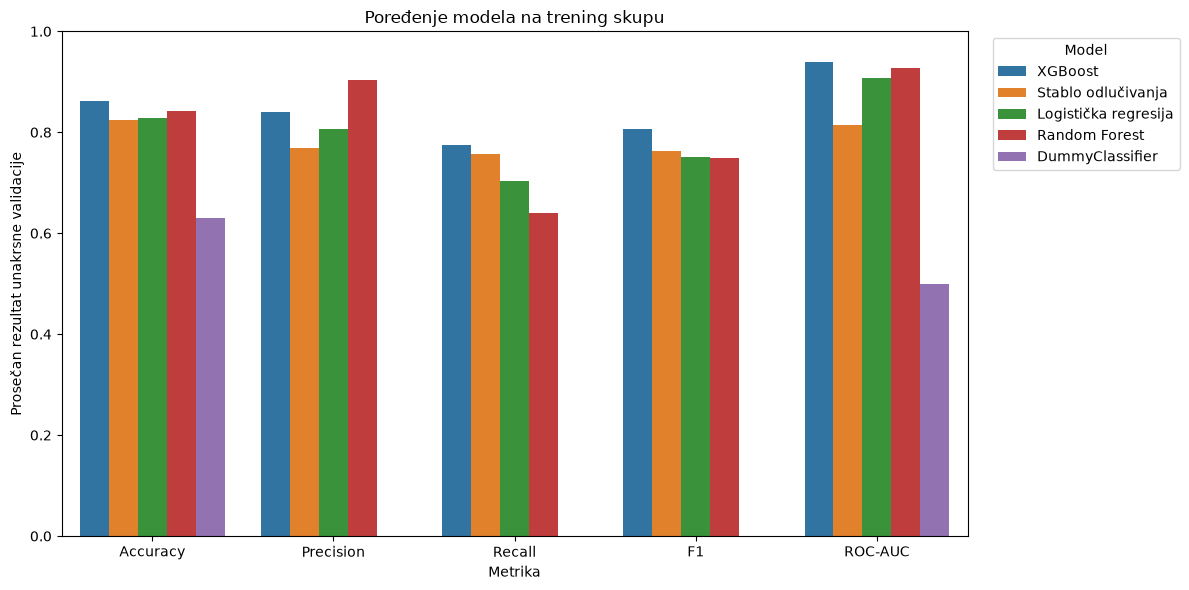

In [68]:
metrics_for_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

plot_results = cv_results_df.melt(
    id_vars="Model",
    value_vars=metrics_for_plot,
    var_name="Metrika",
    value_name="Rezultat"
)

plt.figure(figsize=(12, 6))

sb.barplot(
    data=plot_results,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Poređenje modela na trening skupu")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

Za početno izdvajanje uspešnijih modela posmatraju se F1 i ROC-AUC vrednosti. F1 pokazuje koliko je model uspeo da uskladi preciznost i pronalaženje otkazanih rezervacija, dok ROC-AUC opisuje njegovu sposobnost da razlikuje dve klase pri različitim pragovima odlučivanja. Konačan izbor ipak se ne zasniva samo na ove dve vrednosti, već se uzimaju u obzir i ostale metrike, stabilnost rezultata i vrste grešaka koje model pravi.

In [69]:
best_f1_row = cv_results_df.loc[cv_results_df["F1"].idxmax()]
best_roc_auc_row = cv_results_df.loc[cv_results_df["ROC-AUC"].idxmax()]

print(
    "Najveći prosečan F1 ima model",
    best_f1_row["Model"],
    "sa rezultatom",
    best_f1_row["F1"]
)

print(
    "Najveći prosečan ROC-AUC ima model",
    best_roc_auc_row["Model"],
    "sa rezultatom",
    best_roc_auc_row["ROC-AUC"]
)

Najveći prosečan F1 ima model XGBoost sa rezultatom 0.806
Najveći prosečan ROC-AUC ima model XGBoost sa rezultatom 0.9401


### 12.6. Izbor promenljivih za pobednički model

Pošto je XGBoost imao najveći prosečan F1, u nastavku se proverava da li može da zadrži ili poboljša rezultat sa 20 ili 10 najvažnijih promenljivih.

XGBoost sa svih 34 dozvoljena prediktora predstavlja referentni model. Sa njim se porede varijante sa 20 i 10 najvažnijih originalnih promenljivih. Sve tri varijante koriste iste petostruke `StratifiedGroupKFold` podele trening skupa i iste hiperparametre.


#### Metodološka zaštita od curenja podataka

Izbor promenljivih se ne radi unapred na celom trening skupu. Selektor je deo pipeline-a i u svakom krugu grupne unakrsne validacije koristi samo trening deo trenutnog folda. Svi redovi istog rezervacionog profila ostaju u istom foldu. Pomoćni XGBoost na trening delu procenjuje važnost originalnih promenljivih i bira 20 ili 10 najvažnijih. Nakon toga se glavni XGBoost trenira sa izabranim promenljivama i proverava na validacionom delu koji prethodno nije korišćen.

Test skup se u ovom poglavlju ne koristi. Kolone koje nisu dostupne u trenutku predviđanja već su uklonjene iz skupa `X`, pa se selekcija vrši samo među dozvoljenim prediktorima.


In [70]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class WinningModelFeatureSelector(BaseEstimator, TransformerMixin):
    """Fold-safe izbor originalnih promenljivih pomoću pobedničkog modela."""

    def __init__(self, estimator, n_features=20):
        self.estimator = estimator
        self.n_features = n_features

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Selektor očekuje pandas DataFrame sa nazivima kolona.")

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        identifier_columns = {"agent", "company"}

        self.numeric_features_ = [
            column
            for column in X.columns
            if pd.api.types.is_numeric_dtype(X[column])
            and column not in identifier_columns
        ]
        self.categorical_features_ = [
            column
            for column in X.columns
            if column not in self.numeric_features_
        ]

        self.selection_preprocessor_ = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())
                        ]
                    ),
                    self.numeric_features_
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            (
                                "imputer",
                                SimpleImputer(strategy="most_frequent")
                            ),
                            (
                                "onehot",
                                OneHotEncoder(handle_unknown="ignore")
                            )
                        ]
                    ),
                    self.categorical_features_
                )
            ],
            sparse_threshold=1.0
        )

        selection_matrix = self.selection_preprocessor_.fit_transform(X, y)
        self.selection_estimator_ = clone(self.estimator)
        self.selection_estimator_.fit(selection_matrix, y)

        if hasattr(self.selection_estimator_, "feature_importances_"):
            transformed_importances = (
                self.selection_estimator_.feature_importances_
            )
        elif hasattr(self.selection_estimator_, "coef_"):
            transformed_importances = np.abs(
                self.selection_estimator_.coef_
            ).mean(axis=0)
        else:
            raise TypeError(
                "Pobednički model ne daje važnosti promenljivih."
            )

        numeric_slice = self.selection_preprocessor_.output_indices_["numeric"]
        categorical_slice = (
            self.selection_preprocessor_.output_indices_["categorical"]
        )
        aggregated_importances = {
            column: importance
            for column, importance in zip(
                self.numeric_features_,
                transformed_importances[numeric_slice]
            )
        }

        fitted_onehot = (
            self.selection_preprocessor_
            .named_transformers_["categorical"]
            .named_steps["onehot"]
        )
        categorical_importances = transformed_importances[categorical_slice]
        start_index = 0

        for column, categories in zip(
            self.categorical_features_,
            fitted_onehot.categories_
        ):
            end_index = start_index + len(categories)
            aggregated_importances[column] = (
                categorical_importances[start_index:end_index].sum()
            )
            start_index = end_index

        self.feature_importances_ = pd.Series(
            aggregated_importances,
            name="Važnost"
        ).sort_values(ascending=False)

        number_to_keep = min(self.n_features, len(self.feature_importances_))
        self.selected_features_ = (
            self.feature_importances_.head(number_to_keep).index.tolist()
        )
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_features_")
        selected_data = X.loc[:, self.selected_features_].copy()

        # Agent i company su šifre kategorija, a ne numeričke količine.
        for column in ["agent", "company"]:
            if column in selected_data.columns:
                selected_data[column] = selected_data[column].astype(str)

        return selected_data

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_features_")
        return np.asarray(self.selected_features_, dtype=object)


winning_model_name = str(best_f1_row["Model"])
winning_estimator = clone(models[winning_model_name])
feature_counts_to_compare = [20, 10]

print("Pobednik početnog poređenja:", winning_model_name)
print("Broj svih prediktora pobedničkog modela:", X_train.shape[1])
print("Brojevi najvažnijih prediktora koji će biti provereni:", feature_counts_to_compare)
print("Test skup se ne koristi za selekciju promenljivih.")

assert winning_model_name == cv_results_df.iloc[0]["Model"]


Pobednik početnog poređenja: XGBoost
Broj svih prediktora pobedničkog modela: 34
Brojevi najvažnijih prediktora koji će biti provereni: [20, 10]
Test skup se ne koristi za selekciju promenljivih.


#### Rang promenljivih na trening skupu

Tokom unakrsne validacije svaki fold bira svoj skup najvažnijih promenljivih, pa se iz tog postupka ne dobija jedan zajednički spisak. Zato se selektor nakon poređenja dodatno trenira na celom skupu `X_train`, kako bi se prikazalo kojih 20 i 10 promenljivih smatra najvažnijim.

Ovaj spisak služi samo za prikaz i tumačenje rezultata. Ne koristi se unapred tokom unakrsne validacije i zato ne utiče na dobijene CV rezultate.

In [71]:
reporting_selector = WinningModelFeatureSelector(
    estimator=winning_estimator,
    n_features=max(feature_counts_to_compare),
)
reporting_selector.fit(X_train, y_train)

winning_model_feature_ranking = (
    reporting_selector.feature_importances_
    .rename_axis("Originalna promenljiva")
    .reset_index()
)
winning_model_feature_ranking["Rang"] = (
    np.arange(1, len(winning_model_feature_ranking) + 1)
)
winning_model_feature_ranking["Važnost"] = (
    winning_model_feature_ranking["Važnost"].round(4)
)

top_20_features = reporting_selector.selected_features_
top_10_features = top_20_features[:10]

display(
    winning_model_feature_ranking[
        ["Rang", "Originalna promenljiva", "Važnost"]
    ].head(20)
)

print("Top 20 originalnih promenljivih:")
print(top_20_features)
print("\nTop 10 originalnih promenljivih:")
print(top_10_features)


,Rang,Originalna promenljiva,Važnost
0,1,deposit_type,0.4294
1,2,agent,0.1840
2,3,country,0.0876
3,4,market_segment,0.0705
4,5,lead_time_group,0.0377
5,6,required_car_parking_spaces,0.0289
6,7,company,0.0212
7,8,previous_cancellation_rate,0.0211
8,9,customer_type,0.0177
9,10,distribution_channel,0.0159


Top 20 originalnih promenljivih:
['deposit_type', 'agent', 'country', 'market_segment', 'lead_time_group', 'required_car_parking_spaces', 'company', 'previous_cancellation_rate', 'customer_type', 'distribution_channel', 'total_of_special_requests', 'arrival_date_month', 'meal', 'previous_cancellations', 'has_booking_history', 'reserved_room_type', 'arrival_date_year', 'previous_bookings_not_canceled', 'hotel', 'lead_time']

Top 10 originalnih promenljivih:
['deposit_type', 'agent', 'country', 'market_segment', 'lead_time_group', 'required_car_parking_spaces', 'company', 'previous_cancellation_rate', 'customer_type', 'distribution_channel']


#### Pipeline-i sa 20 i 10 najvažnijih promenljivih

U svakom foldu selektor može izabrati malo drugačiji skup promenljivih. Nakon izbora, preprocesor ih deli na numeričke i kategorijske. Nedostajuće numeričke vrednosti popunjava medijanom i zatim ih standardizuje, dok kategorijske vrednosti popunjava najčešćom kategorijom i pretvara pomoću one-hot kodiranja. Ovako pripremljeni podaci prosleđuju se XGBoost modelu.

In [72]:
from sklearn.compose import make_column_selector

selected_features_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            make_column_selector(dtype_include=np.number)
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent")
                    ),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore")
                    )
                ]
            ),
            make_column_selector(dtype_exclude=np.number)
        )
    ]
)


def create_winner_selection_pipeline(number_of_features):
    return Pipeline(
        steps=[
            (
                "feature_selector",
                WinningModelFeatureSelector(
                    estimator=winning_estimator,
                    n_features=number_of_features
                )
            ),
            (
                "preprocessor",
                clone(selected_features_preprocessor)
            ),
            (
                "model",
                clone(winning_estimator)
            )
        ]
    )


winner_selection_pipelines = {
    f"{winning_model_name} – top 20": create_winner_selection_pipeline(20),
    f"{winning_model_name} – top 10": create_winner_selection_pipeline(10)
}

for pipeline_name, pipeline_value in winner_selection_pipelines.items():
    print(pipeline_name, "->", list(pipeline_value.named_steps.keys()))


XGBoost – top 20 -> ['feature_selector', 'preprocessor', 'model']
XGBoost – top 10 -> ['feature_selector', 'preprocessor', 'model']


#### Poređenje rezultata

Početni XGBoost sa svim promenljivama već je ocenjen petostrukom unakrsnom validacijom, pa se njegov rezultat preuzima iz prethodne tabele. XGBoost modeli sa 20 i 10 promenljivih proveravaju se na istim foldovima, kako bi poređenje bilo ravnopravno.

Za svaki model prikazuju se prosečne vrednosti metrika, standardne devijacije i prosečno vreme treniranja. Kod modela sa manjim brojem promenljivih u vreme je uključen i postupak njihove selekcije.

In [73]:
selected_feature_cv_rows = []

for pipeline_name, pipeline_value in winner_selection_pipelines.items():
    print("Evaluacija modela:", pipeline_name)

    scores = cross_validate(
        estimator=pipeline_value,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=2,
        pre_dispatch=2,
        return_train_score=False
    )

    number_of_features = int(pipeline_name.split("top ")[1])
    selected_features = (
        top_20_features if number_of_features == 20 else top_10_features
    )

    selected_feature_cv_rows.append({
        "Model": pipeline_name,
        "Broj originalnih promenljivih": number_of_features,
        "Izabrane originalne promenljive": ", ".join(selected_features),
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),
        "Recall": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),
        "F1": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "Vreme treniranja (s)": scores["fit_time"].mean()
    })

wide_winner_row = (
    pd.DataFrame(cross_validation_results)
    .set_index("Model")
    .loc[winning_model_name]
)

wide_model_comparison_row = {
    "Model": f"{winning_model_name} – sve promenljive",
    "Broj originalnih promenljivih": X_train.shape[1],
    "Izabrane originalne promenljive": ", ".join(X_train.columns),
    "Accuracy": float(wide_winner_row["Accuracy"]),
    "Accuracy SD": float(wide_winner_row["Accuracy SD"]),
    "Precision": float(wide_winner_row["Precision"]),
    "Precision SD": float(wide_winner_row["Precision SD"]),
    "Recall": float(wide_winner_row["Recall"]),
    "Recall SD": float(wide_winner_row["Recall SD"]),
    "F1": float(wide_winner_row["F1"]),
    "F1 SD": float(wide_winner_row["F1 SD"]),
    "ROC-AUC": float(wide_winner_row["ROC-AUC"]),
    "ROC-AUC SD": float(wide_winner_row["ROC-AUC SD"]),
    "Vreme treniranja (s)": float(
        wide_winner_row["Vreme treniranja (s)"]
    )
}

winner_feature_selection_results_raw = pd.DataFrame(
    [wide_model_comparison_row, *selected_feature_cv_rows]
)

winner_feature_selection_results = (
    winner_feature_selection_results_raw.copy()
)
numeric_result_columns = (
    winner_feature_selection_results
    .select_dtypes(include="number")
    .columns
)
winner_feature_selection_results[numeric_result_columns] = (
    winner_feature_selection_results[numeric_result_columns].round(4)
)

display(
    winner_feature_selection_results
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)


Evaluacija modela: XGBoost – top 20


Evaluacija modela: XGBoost – top 10


,Model,Broj originalnih promenljivih,Izabrane originalne promenljive,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1,F1 SD,ROC-AUC,ROC-AUC SD,Vreme treniranja (s)
0,XGBoost – sve promenljive,34,"hotel, lead_time, arrival_date_year, arrival_d...",0.8618,0.0039,0.8403,0.0105,0.7747,0.0113,0.8060,0.0056,0.9401,0.0016,3.5245
1,XGBoost – top 20,20,"deposit_type, agent, country, market_segment, ...",0.8584,0.0032,0.8331,0.0082,0.7731,0.0108,0.8019,0.0050,0.9372,0.0019,6.3363
2,XGBoost – top 10,10,"deposit_type, agent, country, market_segment, ...",0.8196,0.0128,0.7975,0.0175,0.6886,0.0341,0.7386,0.0226,0.9082,0.0086,5.8084


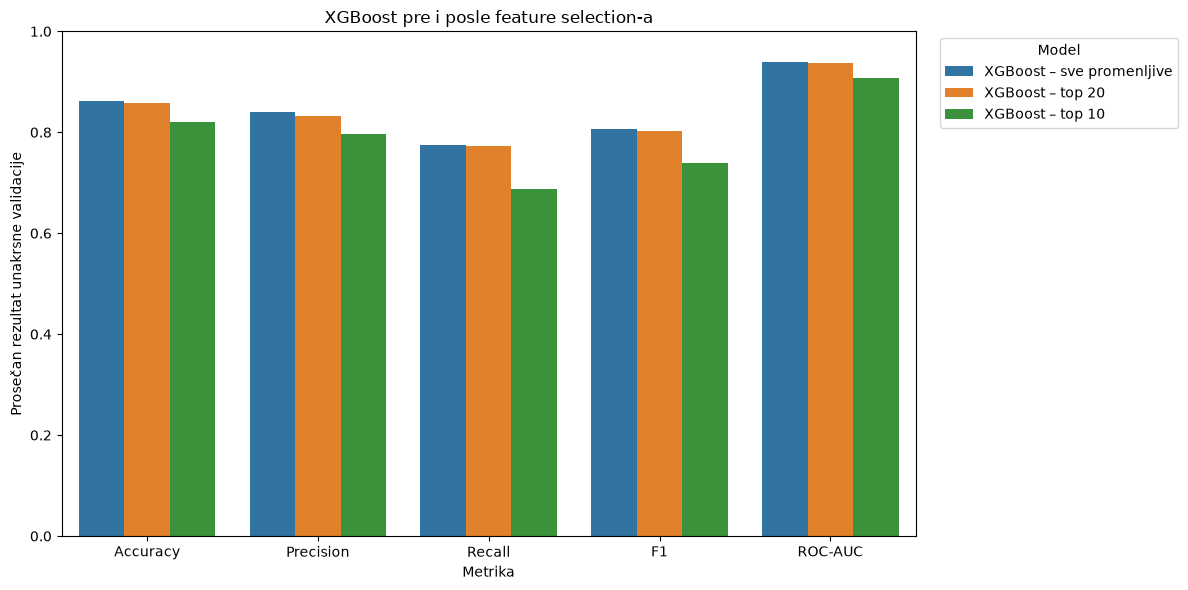

In [74]:
feature_selection_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

feature_selection_plot_data = (
    winner_feature_selection_results_raw
    .melt(
        id_vars="Model",
        value_vars=feature_selection_metrics,
        var_name="Metrika",
        value_name="Rezultat"
    )
)

plt.figure(figsize=(12, 6))
sb.barplot(
    data=feature_selection_plot_data,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)
plt.ylim(0, 1)
plt.title(f"{winning_model_name} pre i posle feature selection-a")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### Izbor najbolje varijante pobedničkog modela

Na osnovu rezultata petostruke grupne unakrsne validacije bira se varijanta XGBoost modela sa najvećom prosečnom F1 vrednošću. Ako dve varijante imaju isti F1 rezultat, prednost se daje varijanti sa manjim brojem originalnih promenljivih.

Izabrani pipeline i njegove CV metrike čuvaju se za naredno podešavanje hiperparametara. Test skup se ne koristi prilikom ovog izbora.

In [75]:
best_winner_result = (
    winner_feature_selection_results_raw
    .sort_values(
        by=["F1", "Broj originalnih promenljivih"],
        ascending=[False, True]
    )
    .iloc[0]
)

best_winner_variant_name = best_winner_result["Model"]
best_winner_feature_count = int(
    best_winner_result["Broj originalnih promenljivih"]
)

if best_winner_variant_name == f"{winning_model_name} – top 20":
    selected_winner_pipeline = clone(
        winner_selection_pipelines[f"{winning_model_name} – top 20"]
    )
elif best_winner_variant_name == f"{winning_model_name} – top 10":
    selected_winner_pipeline = clone(
        winner_selection_pipelines[f"{winning_model_name} – top 10"]
    )
else:
    selected_winner_pipeline = clone(model_pipelines[winning_model_name])

metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
selected_winner_cv_results = {
    metric: float(best_winner_result[metric])
    for metric in metric_names
}
selected_winner_cv_results_sd = {
    metric: float(best_winner_result[f"{metric} SD"])
    for metric in metric_names
}


In [76]:
print("Najbolja varijanta pobedničkog modela:", best_winner_variant_name)
print("Broj izabranih promenljivih:", best_winner_feature_count)
print("CV F1:", round(selected_winner_cv_results["F1"], 4))
print("CV ROC-AUC:", round(selected_winner_cv_results["ROC-AUC"], 4))
print("Test skup nije korišćen za ovaj izbor.")


Najbolja varijanta pobedničkog modela: XGBoost – sve promenljive
Broj izabranih promenljivih: 34
CV F1: 0.806
CV ROC-AUC: 0.9401
Test skup nije korišćen za ovaj izbor.


#### Zaključak feature selection-a

XGBoost sa sve 34 promenljive ostvario je najveći prosečan F1 od 0,8060 i ROC-AUC od 0,9401. Top-20 varijanta bila je veoma blizu, sa F1 od 0,8019 i ROC-AUC od 0,9372, dok je top-10 varijanta bila primetno slabija, sa F1 od 0,7386 i ROC-AUC od 0,9082.

Pošto feature selection nije povećao F1, za naredno podešavanje zadržan je XGBoost sa svih 34 promenljive. Odluka je doneta isključivo na osnovu grupne unakrsne validacije trening skupa; test skup nije korišćen ni za rangiranje promenljivih ni za izbor varijante modela.


### 12.7. Zaključak početnog poređenja modela

XGBoost je ostvario najveći početni CV F1 od 0,8060, pa su za njega proverene varijante sa 20 i 10 promenljivih. Nijedna nije nadmašila model sa svih 34 promenljive, zato je puna varijanta izabrana za podešavanje hiperparametara.


## 13. Podešavanje izabranog modela

Nakon početnog poređenja modela i feature selection-a, za dalje podešavanje bira se XGBoost varijanta sa najvećim prosečnim CV F1. Cilj je da se proveri da li promena hiperparametara može dodatno da poboljša njen F1 rezultat.

Podešavanje se vrši samo na trening skupu. Feature selection i preprocesiranje ostaju unutar pipeline-a, dok se test skup čuva za konačnu proveru.


### 13.1. Izbor modela za podešavanje

Za podešavanje se koristi XGBoost sa svih 34 promenljive, koji je ostvario F1 od 0,8060. Varijante sa 20 i 10 promenljivih bile su slabije, sa F1 rezultatima od 0,8019 i 0,7386.

Najbolji rezultat ostvaren je sa svih 34 promenljive, pa se tokom podešavanja nijedna od njih ne izbacuje. Preprocesiranje i podešavanje obavljaju se samo na trening delu svakog validacionog kruga, čime se sprečava curenje podataka.


### 13.2. Izbor hiperparametara

U pretragu su uključeni hiperparametri koji utiču na način formiranja i složenost XGBoost modela:

- `n_estimators` određuje koliko stabala model koristi;
- `max_depth` određuje najveću dozvoljenu dubinu svakog stabla;
- `learning_rate` određuje veličinu doprinosa svakog novog stabla;
- `subsample` određuje udeo trening redova korišćenih za svako stablo;
- `colsample_bytree` određuje udeo prediktora razmatranih pri izgradnji stabla;
- `min_child_weight` ograničava formiranje podela sa premalo informacija u završnim čvorovima.

Ispred naziva svakog hiperparametra nalazi se `model__` zato što je XGBoost u okviru pipeline-a smešten u koraku koji se zove `model`. Na taj način pretraga zna da se navedeni parametri odnose upravo na XGBoost model.

In [77]:
xgboost_parameters = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5]
}

number_of_combinations = np.prod([
    len(values)
    for values in xgboost_parameters.values()
])

print("Ukupan broj mogućih kombinacija:", number_of_combinations)
print("Broj kombinacija koje će biti isprobane: 6")

Ukupan broj mogućih kombinacija: 96
Broj kombinacija koje će biti isprobane: 6


Ukupno postoji 96 mogućih kombinacija hiperparametara. Zbog vremena potrebnog za treniranje neće biti proverene sve kombinacije, već će `RandomizedSearchCV` nasumično izabrati šest. Svaka od njih biće ocenjena kroz tri grupne validacione podele, što znači da će ukupno biti izvršeno 18 treniranja.

### 13.3. Pretraga pomoću RandomizedSearchCV

Provera svih mogućih kombinacija zahtevala bi mnogo vremena, pa se koristi `RandomizedSearchCV`. Ovaj postupak nasumično bira šest kombinacija hiperparametara i svaku proverava kroz tri grupne stratifikovane validacione podele. Zbog toga se model ukupno trenira 18 puta.

Kao glavna metrika za izbor najbolje kombinacije koristi se F1, jer uzima u obzir i precision i recall. Istovremeno se računaju i ostale metrike kako bi se rezultati modela sagledali potpunije.

In [78]:
from sklearn.model_selection import RandomizedSearchCV

search_cross_validation = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgboost_search = RandomizedSearchCV(
    estimator=clone(selected_winner_pipeline),
    param_distributions=xgboost_parameters,
    n_iter=6,
    scoring=scoring_metrics,
    refit="f1",
    cv=search_cross_validation,
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=2,
    return_train_score=False
)

xgboost_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Pretraga je završena.")


Fitting 3 folds for each of 6 candidates, totalling 18 fits


Pretraga je završena.


### 13.4. Najbolji pronađeni hiperparametri

Prikazuju se parametri kombinacije koja je ostvarila najveći prosečan F1. Rezultati svih isprobanih kombinacija omogućavaju da se vidi koliko se njihove metrike razlikuju.


In [79]:
print("Najbolji hiperparametri:")
for parameter, value in xgboost_search.best_params_.items():
    print(parameter, "=", value)

print(
    "\nNajbolji prosečan F1 tokom pretrage:",
    round(xgboost_search.best_score_, 4)
)

search_results_df = pd.DataFrame(
    xgboost_search.cv_results_
)

top_search_results = (
    search_results_df[[
        "rank_test_f1",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "params"
    ]]
    .sort_values("rank_test_f1")
    .reset_index(drop=True)
)

metric_columns = [
    column for column in top_search_results.columns
    if column.startswith("mean_test_")
]

top_search_results[metric_columns] = (
    top_search_results[metric_columns].round(4)
)

display(top_search_results)

Najbolji hiperparametri:
model__subsample = 0.8
model__n_estimators = 250
model__min_child_weight = 5
model__max_depth = 8
model__learning_rate = 0.1
model__colsample_bytree = 1.0

Najbolji prosečan F1 tokom pretrage: 0.8097


,rank_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,params
0,1,0.8630,0.8351,0.7857,0.8097,0.9416,"{'model__subsample': 0.8, 'model__n_estimators..."
1,2,0.8583,0.8354,0.7694,0.8010,0.9381,"{'model__subsample': 0.8, 'model__n_estimators..."
2,3,0.8578,0.8366,0.7664,0.7999,0.9374,"{'model__subsample': 1.0, 'model__n_estimators..."
3,4,0.8553,0.8368,0.7575,0.7952,0.9341,"{'model__subsample': 1.0, 'model__n_estimators..."
4,5,0.8515,0.8368,0.7449,0.7881,0.9315,"{'model__subsample': 1.0, 'model__n_estimators..."
5,6,0.8516,0.8379,0.7439,0.7881,0.9317,"{'model__subsample': 1.0, 'model__n_estimators..."


Najbolja kombinacija koristi 250 stabala, maksimalnu dubinu 8, `learning_rate=0,1`, `subsample=0,8`, `colsample_bytree=1,0` i `min_child_weight=5`. U trostrukoj grupnoj validaciji tokom pretrage ostvarila je prosečan F1 od 0,8097 i ROC-AUC od 0,9416. Zatim je ponovo proverena petostrukom grupnom validacijom radi ravnopravnog poređenja sa nepodešenim modelom.


### 13.5. Provera podešenog modela

Najbolja kombinacija iz pretrage ponovo se proverava petostrukom grupnom stratifikovanom unakrsnom validacijom. Tako se podešena XGBoost varijanta poredi sa istom nepodešenom varijantom na istim podelama, bez preklapanja identičnih profila. Test skup se ni u ovoj proveri ne koristi.


In [80]:
tuned_winner_model = xgboost_search.best_estimator_

tuned_scores = cross_validate(
    estimator=tuned_winner_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False
)

tuned_results = {
    "Accuracy": tuned_scores["test_accuracy"].mean(),
    "Precision": tuned_scores["test_precision"].mean(),
    "Recall": tuned_scores["test_recall"].mean(),
    "F1": tuned_scores["test_f1"].mean(),
    "ROC-AUC": tuned_scores["test_roc_auc"].mean()
}

tuned_results_sd = {
    "Accuracy": tuned_scores["test_accuracy"].std(),
    "Precision": tuned_scores["test_precision"].std(),
    "Recall": tuned_scores["test_recall"].std(),
    "F1": tuned_scores["test_f1"].std(),
    "ROC-AUC": tuned_scores["test_roc_auc"].std()
}

print("Provera podešenog modela je završena.")

Provera podešenog modela je završena.


### 13.6. Poređenje modela pre i posle podešavanja

Podešeni XGBoost se poredi sa najboljom nepodešenom XGBoost varijantom iz prethodnog poglavlja. Pozitivna razlika označava poboljšanje, a negativna slabiji rezultat. Glavna metrika za konačan izbor ostaje F1.


In [81]:
baseline_winner_model = selected_winner_cv_results
baseline_winner_model_sd = selected_winner_cv_results_sd
baseline_model_label = f"{best_winner_variant_name} pre tuninga"
tuned_model_label = f"Podešeni {best_winner_variant_name}"

comparison_rows = []

for metric in metric_names:
    baseline_value = baseline_winner_model[metric]
    tuned_value = tuned_results[metric]

    comparison_rows.append({
        "Metrika": metric,
        baseline_model_label: baseline_value,
        tuned_model_label: tuned_value,
        "Razlika": tuned_value - baseline_value,
        "SD pre tuninga": baseline_winner_model_sd[metric],
        "SD posle tuninga": tuned_results_sd[metric]
    })

winner_model_comparison = pd.DataFrame(comparison_rows)
comparison_numeric_columns = winner_model_comparison.columns.drop("Metrika")
winner_model_comparison[comparison_numeric_columns] = (
    winner_model_comparison[comparison_numeric_columns].round(4)
)

display(winner_model_comparison)


,Metrika,XGBoost – sve promenljive pre tuninga,Podešeni XGBoost – sve promenljive,Razlika,SD pre tuninga,SD posle tuninga
0,Accuracy,0.8618,0.8651,0.0034,0.0039,0.0022
1,Precision,0.8403,0.8364,-0.0038,0.0105,0.0080
2,Recall,0.7747,0.7911,0.0164,0.0113,0.0092
3,F1,0.8060,0.8131,0.0070,0.0056,0.0032
4,ROC-AUC,0.9401,0.9429,0.0028,0.0016,0.0017


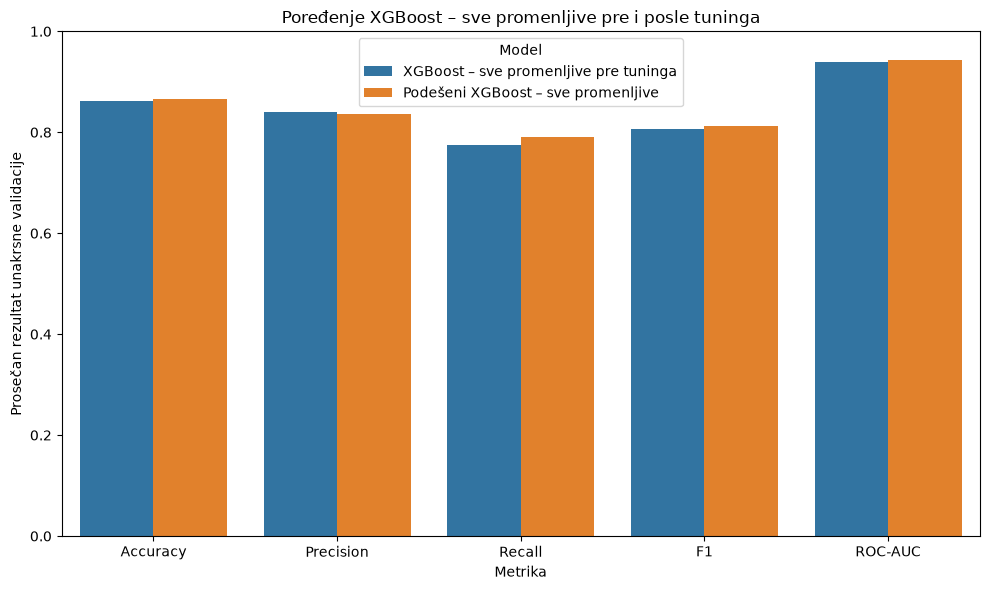

In [82]:
comparison_for_plot = winner_model_comparison.melt(
    id_vars="Metrika",
    value_vars=[
        baseline_model_label,
        tuned_model_label
    ],
    var_name="Model",
    value_name="Rezultat"
)

plt.figure(figsize=(10, 6))
sb.barplot(
    data=comparison_for_plot,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)
plt.ylim(0, 1)
plt.title(f"Poređenje {best_winner_variant_name} pre i posle tuninga")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


### 13.7. Pregled promena metrika

Parametar `class_weight` određuje koliko pažnje model tokom treniranja posvećuje svakoj klasi. Kada se koristi `class_weight="balanced"`, veću težinu dobija manje zastupljena klasa, odnosno otkazane rezervacije. Na taj način model može da prepozna više otkazivanja, ali istovremeno može češće pogrešno označiti neotkazane rezervacije kao otkazane.

In [83]:
improved_metrics = winner_model_comparison.loc[
    winner_model_comparison["Razlika"] > 0,
    "Metrika"
].tolist()
declined_metrics = winner_model_comparison.loc[
    winner_model_comparison["Razlika"] < 0,
    "Metrika"
].tolist()

print("Metrike poboljšane tuningom:", improved_metrics)
print("Metrike smanjene tuningom:", declined_metrics)

Metrike poboljšane tuningom: ['Accuracy', 'Recall', 'F1', 'ROC-AUC']
Metrike smanjene tuningom: ['Precision']


Tuning je povećao accuracy, recall, F1 i ROC-AUC, dok je precision blago smanjen sa 0,8403 na 0,8364. Najveće poboljšanje ostvareno je kod recall-a, koji je porastao sa 0,7747 na 0,7911.


### 13.8. Zaključak podešavanja modela

Podešeni XGBoost povećao je prosečan F1 sa 0,8060 na 0,8131, accuracy sa 0,8618 na 0,8651 i ROC-AUC sa 0,9401 na 0,9429. Pošto je F1 unapred izabran kao glavna metrika, podešeni XGBoost sa sve 34 promenljive zadržan je kao konačni model. Odluka je doneta pre korišćenja test skupa.


## 14. Konačna procena modela na test skupu

Nakon izbora i podešavanja, XGBoost se prvi put ocenjuje na izdvojenom test skupu. Iako su te rezervacije ranije bile deo opisne analize celog očišćenog skupa, nisu korišćene za treniranje, izbor modela, izbor promenljivih, podešavanje hiperparametara ili određivanje pravila preprocesiranja. Zato dobijene metrike predstavljaju završnu procenu modela.

Dobijena test predviđanja u narednim poglavljima služe samo za tumačenje važnosti promenljivih i analizu grešaka. Model se na osnovu tih analiza neće dodatno menjati.

### 14.1. Izbor konačnog modela

Najbolja nepodešena XGBoost varijanta i njena podešena verzija porede se prema prosečnom F1 rezultatu petostruke grupne unakrsne validacije. Podešeni model bira se samo ako je njegov F1 veći. Test skup ne utiče na ovu odluku.


In [84]:
baseline_f1 = baseline_winner_model["F1"]
tuned_f1 = tuned_results["F1"]

if tuned_f1 > baseline_f1:
    selected_model_name = f"Podešeni {best_winner_variant_name}"
    final_model = clone(tuned_winner_model)
    final_cv_results = tuned_results.copy()
    final_cv_results_sd = tuned_results_sd.copy()
else:
    selected_model_name = best_winner_variant_name
    final_model = clone(selected_winner_pipeline)
    final_cv_results = baseline_winner_model.copy()
    final_cv_results_sd = baseline_winner_model_sd.copy()

final_feature_count = best_winner_feature_count

print("Izabrani model:", selected_model_name)
print("F1 najbolje varijante pre tuninga:", round(baseline_f1, 4))
print("F1 podešene varijante:", round(tuned_f1, 4))
print("Broj promenljivih finalnog modela:", final_feature_count)
print("Test skup nije korišćen za izbor finalnog modela.")


Izabrani model: Podešeni XGBoost – sve promenljive
F1 najbolje varijante pre tuninga: 0.806
F1 podešene varijante: 0.8131
Broj promenljivih finalnog modela: 34
Test skup nije korišćen za izbor finalnog modela.


### 14.2. Treniranje modela i predviđanje

Izabrani pipeline se trenira na celom trening skupu. Pošto je puna varijanta pobedila u feature-selection poređenju, preprocesor priprema svih 34 dozvoljenih promenljivih i trenira podešeni XGBoost. Tek nakon toga model se jednom primenjuje na test skup.


In [85]:
final_model.fit(X_train, y_train)

y_test_prediction = final_model.predict(X_test)
y_test_probability = final_model.predict_proba(X_test)[:, 1]

print("Broj rezervacija u test skupu:", len(y_test))
print("Broj dobijenih predviđanja:", len(y_test_prediction))

assert len(y_test_prediction) == len(y_test)
assert len(y_test_probability) == len(y_test)
assert set(y_test_prediction).issubset({0, 1})

print("Predviđanja na test skupu su uspešno dobijena.")

Broj rezervacija u test skupu: 23843
Broj dobijenih predviđanja: 23843
Predviđanja na test skupu su uspešno dobijena.


### 14.3. Konačne vrednosti metrika

Uspešnost modela na test skupu procenjuje se istim metrikama koje su korišćene tokom unakrsne validacije. Tako se može proveriti da li je model zadržao sličan kvalitet i na podacima koji nisu učestvovali u njegovom izboru ili treniranju.

Pored osnovnih metrika prikazuje se i klasifikacioni izveštaj sa posebnim rezultatima za otkazane i neotkazane rezervacije. Posebno je značajan recall za klasu Otkazana, jer pokazuje koliki procenat stvarno otkazanih rezervacija je model uspešno prepoznao.

In [86]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

final_test_results = pd.DataFrame({
    "Metrika": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Rezultat": [
        accuracy_score(y_test, y_test_prediction),
        precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        roc_auc_score(y_test, y_test_probability)
    ]
})

final_test_results["Rezultat"] = (
    final_test_results["Rezultat"].round(4)
)

display(final_test_results)

print("Klasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        y_test_prediction,
        target_names=["Nije otkazana", "Otkazana"],
        digits=4,
        zero_division=0
    )
)

,Metrika,Rezultat
0,Accuracy,0.8727
1,Precision,0.8420
2,Recall,0.8083
3,F1,0.8248
4,ROC-AUC,0.9470


Klasifikacioni izveštaj:
               precision    recall  f1-score   support

Nije otkazana     0.8896    0.9106    0.9000     15003
     Otkazana     0.8420    0.8083    0.8248      8840

     accuracy                         0.8727     23843
    macro avg     0.8658    0.8594    0.8624     23843
 weighted avg     0.8720    0.8727    0.8721     23843



Dobijeni test rezultati porede se sa rezultatima unakrsne validacije iz prethodnih poglavlja. Velike razlike mogle bi da ukažu da rezultat modela zavisi od konkretne podele podataka, dok slične vrednosti pokazuju da se model ponaša stabilno i na izdvojenim rezervacijama.

In [87]:
test_result_series = (
    final_test_results
    .set_index("Metrika")["Rezultat"]
)

validation_test_comparison = pd.DataFrame({
    "Metrika": metric_names,
    "Unakrsna validacija": [
        final_cv_results[metric] for metric in metric_names
    ],
    "CV standardna devijacija": [
        final_cv_results_sd[metric] for metric in metric_names
    ],
    "Test skup": [
        test_result_series[metric] for metric in metric_names
    ]
})

validation_test_comparison["Razlika test - CV"] = (
    validation_test_comparison["Test skup"]
    - validation_test_comparison["Unakrsna validacija"]
)

comparison_columns = validation_test_comparison.columns.drop("Metrika")
validation_test_comparison[comparison_columns] = (
    validation_test_comparison[comparison_columns].round(4)
)

display(validation_test_comparison)


,Metrika,Unakrsna validacija,CV standardna devijacija,Test skup,Razlika test - CV
0,Accuracy,0.8651,0.0022,0.8727,0.0076
1,Precision,0.8364,0.0080,0.8420,0.0056
2,Recall,0.7911,0.0092,0.8083,0.0172
3,F1,0.8131,0.0032,0.8248,0.0117
4,ROC-AUC,0.9429,0.0017,0.9470,0.0041


Test rezultati su bliski proseku unakrsne validacije. Na test skupu accuracy je veći za 0,0076, precision za 0,0056, recall za 0,0172, F1 za 0,0117 i ROC-AUC za 0,0041. To ne ukazuje na neočekivano pogoršanje na izdvojenim podacima. Test rezultat nije korišćen za promenu modela.


### 14.4. Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i pogrešno klasifikovanih rezervacija. Posebno su važne otkazane rezervacije koje je model označio kao neotkazane, jer predstavljaju otkazivanja koja model nije uspeo da prepozna. Sa druge strane, neotkazane rezervacije označene kao otkazane predstavljaju lažna upozorenja.

,Broj rezervacija
Tačno prepoznate neotkazane rezervacije,13662
Neotkazane pogrešno označene kao otkazane,1341
Propuštene otkazane rezervacije,1695
Tačno prepoznate otkazane rezervacije,7145


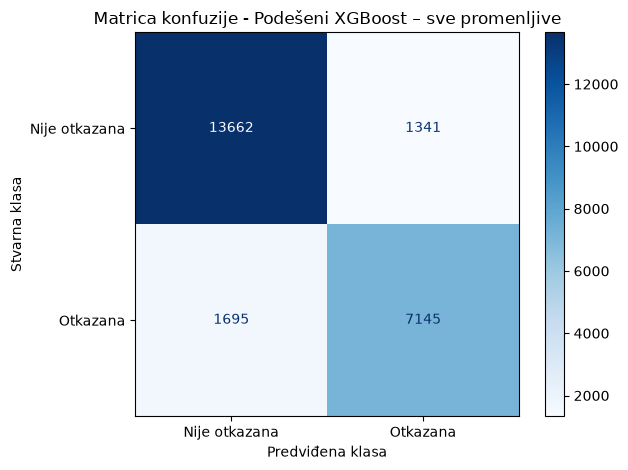

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

confusion_values = confusion_matrix(
    y_test,
    y_test_prediction
)

tn, fp, fn, tp = confusion_values.ravel()

confusion_summary = pd.Series({
    "Tačno prepoznate neotkazane rezervacije": tn,
    "Neotkazane pogrešno označene kao otkazane": fp,
    "Propuštene otkazane rezervacije": fn,
    "Tačno prepoznate otkazane rezervacije": tp
})

display(confusion_summary.to_frame("Broj rezervacija"))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_values,
    display_labels=["Nije otkazana", "Otkazana"]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title(f"Matrica konfuzije - {selected_model_name}")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.show()

Matrica konfuzije pokazuje 13.662 tačno prepoznate neotkazane rezervacije (TN), 7.145 tačno prepoznatih otkazanih rezervacija (TP), 1.341 lažno upozorenje (FP) i 1.695 propuštenih otkazivanja (FN). Ovi brojevi se odnose samo na unapred izabrani podešeni XGBoost model.


### 14.5. ROC kriva

ROC kriva prikazuje odnos između udela pravilno prepoznatih otkazivanja i udela neotkazanih rezervacija koje su pogrešno označene kao otkazane pri različitim pragovima odlučivanja. Što je kriva bliža gornjem levom uglu, model bolje razdvaja dve klase. Isprekidana dijagonala predstavlja rezultat nasumičnog razvrstavanja.

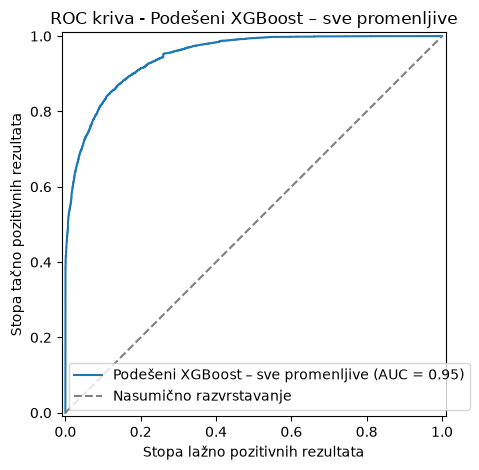

In [89]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_test_probability,
    name=selected_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Nasumično razvrstavanje"
)
plt.title(f"ROC kriva - {selected_model_name}")
plt.xlabel("Stopa lažno pozitivnih rezultata")
plt.ylabel("Stopa tačno pozitivnih rezultata")
plt.legend()
plt.tight_layout()
plt.show()

ROC kriva pokazuje dobro razdvajanje otkazanih i neotkazanih rezervacija, uz ROC-AUC od 0,9470 na test skupu.


### 14.6. Precision–recall kriva

Pored ROC krive, korisno je prikazati i precision–recall krivu. Ona pokazuje kako se menjaju precision i recall vrednosti kada se promeni prag na osnovu kojeg model označava rezervaciju kao otkazanu. Veći recall znači da model pronalazi više stvarnih otkazivanja, dok veći precision znači da je veći deo njegovih upozorenja tačan.

Vrednost `Average Precision` sažima odnos precision i recall rezultata kroz sve posmatrane pragove, pri čemu rezultat bliži jedinici označava uspešniji model. Isprekidana horizontalna linija predstavlja početnu referencu, odnosno udeo otkazanih rezervacija u test skupu.

Average Precision: 0.9221
Udeo otkazanih rezervacija u test skupu: 0.3708


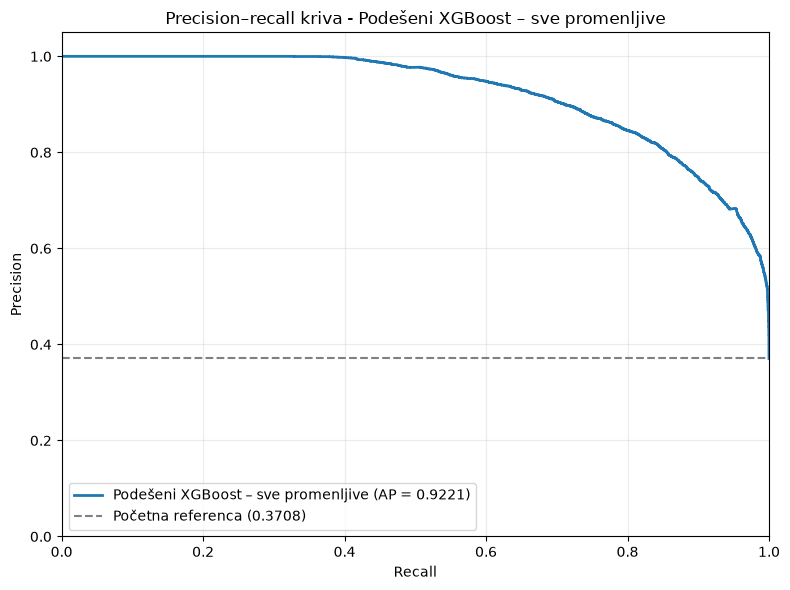

In [90]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve
)

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    y_test_probability
)

average_precision = average_precision_score(
    y_test,
    y_test_probability
)

cancellation_share = y_test.mean()

print(
    "Average Precision:",
    round(average_precision, 4)
)
print(
    "Udeo otkazanih rezervacija u test skupu:",
    round(cancellation_share, 4)
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    color="#1f77b4",
    linewidth=2,
    label=(
        f"{selected_model_name} "
        f"(AP = {average_precision:.4f})"
    )
)
plt.axhline(
    y=cancellation_share,
    color="gray",
    linestyle="--",
    label=(
        "Početna referenca "
        f"({cancellation_share:.4f})"
    )
)
plt.title(
    f"Precision–recall kriva - {selected_model_name}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Average Precision iznosi 0,9221 i znatno je veći od udela otkazanih rezervacija u test skupu od 0,3708. To potvrđuje da model kroz različite pragove uspešno rangira rezervacije prema riziku od otkazivanja. Ovaj rezultat se koristi samo za završno tumačenje modela.


### 14.7. Zaključak konačne procene

Konačni podešeni XGBoost sa sve 34 promenljive ostvario je na test skupu accuracy 0,8727, precision 0,8420, recall 0,8083, F1 0,8248, ROC-AUC 0,9470 i Average Precision 0,9221. Rezultati su saglasni sa unakrsnom validacijom i nisu korišćeni za naknadnu promenu promenljivih, hiperparametara, praga ili modela.


## 15. Analiza važnosti promenljivih

Nakon procene uspešnosti modela, proverava se koje su promenljive imale najveći značaj za predviđanja. Ova analiza pomaže da bolje razumemo na koje informacije se model najviše oslanja kada procenjuje da li će rezervacija biti otkazana.

Važno je naglasiti da velika važnost neke promenljive ne znači da ona direktno izaziva otkazivanje. Ona samo pokazuje da je model tu promenljivu često koristio prilikom razlikovanja otkazanih i neotkazanih rezervacija.

### 15.1. Važnost prediktora u XGBoost modelu

XGBoost tokom treniranja beleži koliko je svaki prediktor doprineo podelama unutar stabala. Veća vrednost znači da je prediktor imao veći doprinos razdvajanju otkazanih i neotkazanih rezervacija.

Pošto pipeline transformiše podatke, jedna kategorijska kolona može biti predstavljena većim brojem one-hot kolona. Zato se najpre prikazuje važnost svake tako dobijene kolone posebno.

In [91]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_prediction_model = final_model.named_steps["model"]

if "feature_selector" in final_model.named_steps:
    fitted_feature_selector = final_model.named_steps["feature_selector"]
    final_selected_features = fitted_feature_selector.selected_features_
else:
    fitted_feature_selector = None
    final_selected_features = X_train.columns.tolist()

transformed_feature_names = fitted_preprocessor.get_feature_names_out()
feature_importance_values = fitted_prediction_model.feature_importances_

transformed_feature_importance = pd.DataFrame({
    "Prediktor": transformed_feature_names,
    "Važnost": feature_importance_values
})
transformed_feature_importance["Prediktor"] = (
    transformed_feature_importance["Prediktor"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
transformed_feature_importance = (
    transformed_feature_importance
    .sort_values("Važnost", ascending=False)
    .reset_index(drop=True)
)
transformed_feature_importance["Važnost"] = (
    transformed_feature_importance["Važnost"].round(4)
)

print("Originalne promenljive izabrane u finalnom pipeline-u:")
print(final_selected_features)
display(transformed_feature_importance.head(20))

assert len(final_selected_features) == final_feature_count
assert len(transformed_feature_names) == len(feature_importance_values)
assert np.isclose(feature_importance_values.sum(), 1.0)


Originalne promenljive izabrane u finalnom pipeline-u:
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests', 'has_children_or_babies', 'total_previous_bookings', 'has_booking_history', 'previous_cancellation_rate', 'arrival_season', 'lead_time_group']


,Prediktor,Važnost
0,deposit_type_Non Refund,0.4316
1,market_segment_Online TA,0.0434
2,required_car_parking_spaces,0.0390
3,previous_cancellation_rate,0.0318
4,country_PRT,0.0231
5,agent_9,0.0224
6,agent_240,0.0210
7,market_segment_Direct,0.0141
8,total_of_special_requests,0.0131
9,customer_type_Transient,0.0122


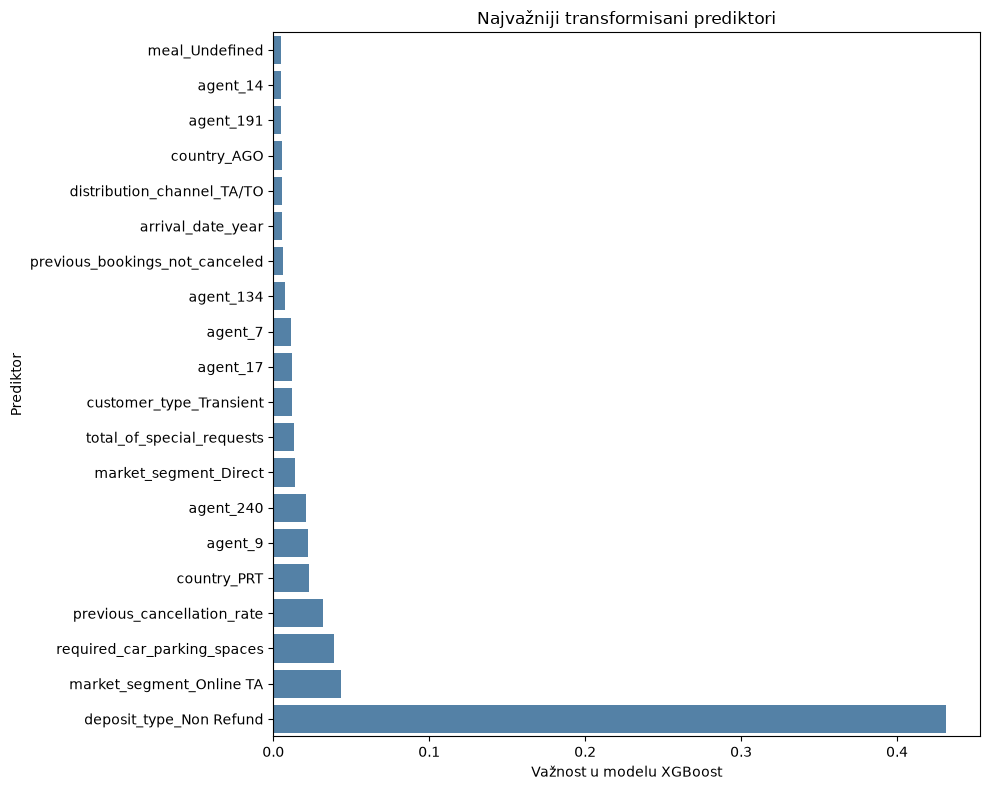

In [92]:
top_transformed_features = (
    transformed_feature_importance.head(20)
    .sort_values("Važnost", ascending=True)
)

plt.figure(figsize=(10, 8))
sb.barplot(
    data=top_transformed_features,
    x="Važnost",
    y="Prediktor",
    color="steelblue"
)
plt.title("Najvažniji transformisani prediktori")
plt.xlabel(f"Važnost u modelu {winning_model_name}")
plt.ylabel("Prediktor")
plt.tight_layout()
plt.show()

Tabela i grafikon prikazuju najvažnije transformisane prediktore konačnog XGBoost modela sa sve 34 originalne promenljive. Kod kategorijskih promenljivih svaka kategorija je prikazana posebno, pa se u nastavku njihove važnosti sabiraju prema originalnim kolonama.


### 15.2. Zbirna važnost originalnih promenljivih

Posmatranje pojedinačnih one-hot kolona može umanjiti značaj kategorijske promenljive, jer se njena ukupna važnost deli između više kategorija. Zbog toga se važnosti svih kategorija koje pripadaju istoj originalnoj koloni sabiraju. Numeričke promenljive već imaju po jednu transformisanu kolonu, pa njihova važnost ostaje nepromenjena.

In [93]:
numeric_output_slice = fitted_preprocessor.output_indices_["numeric"]
categorical_output_slice = fitted_preprocessor.output_indices_["categorical"]

selected_numeric_columns = [
    column
    for column in final_selected_features
    if pd.api.types.is_numeric_dtype(X_train[column])
    and column not in ["agent", "company"]
]
selected_categorical_columns = [
    column
    for column in final_selected_features
    if column not in selected_numeric_columns
]

aggregated_importance = {
    column: importance
    for column, importance in zip(
        selected_numeric_columns,
        feature_importance_values[numeric_output_slice]
    )
}

fitted_onehot = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)
categorical_importance_values = feature_importance_values[
    categorical_output_slice
]

start_index = 0
for column, categories in zip(
    selected_categorical_columns,
    fitted_onehot.categories_
):
    end_index = start_index + len(categories)
    aggregated_importance[column] = (
        categorical_importance_values[start_index:end_index].sum()
    )
    start_index = end_index

original_feature_importance = pd.DataFrame({
    "Promenljiva": aggregated_importance.keys(),
    "Zbirna važnost": aggregated_importance.values()
})
original_feature_importance = (
    original_feature_importance
    .sort_values("Zbirna važnost", ascending=False)
    .reset_index(drop=True)
)
original_feature_importance["Zbirna važnost"] = (
    original_feature_importance["Zbirna važnost"].round(4)
)

display(original_feature_importance.head(15))

assert start_index == len(categorical_importance_values)
assert np.isclose(sum(aggregated_importance.values()), 1.0)


,Promenljiva,Zbirna važnost
0,deposit_type,0.4335
1,arrival_season,0.1845
2,country,0.0967
3,market_segment,0.0670
4,required_car_parking_spaces,0.0390
5,previous_cancellation_rate,0.0318
6,agent,0.0201
7,arrival_date_month,0.0180
8,lead_time_group,0.0151
9,total_of_special_requests,0.0131


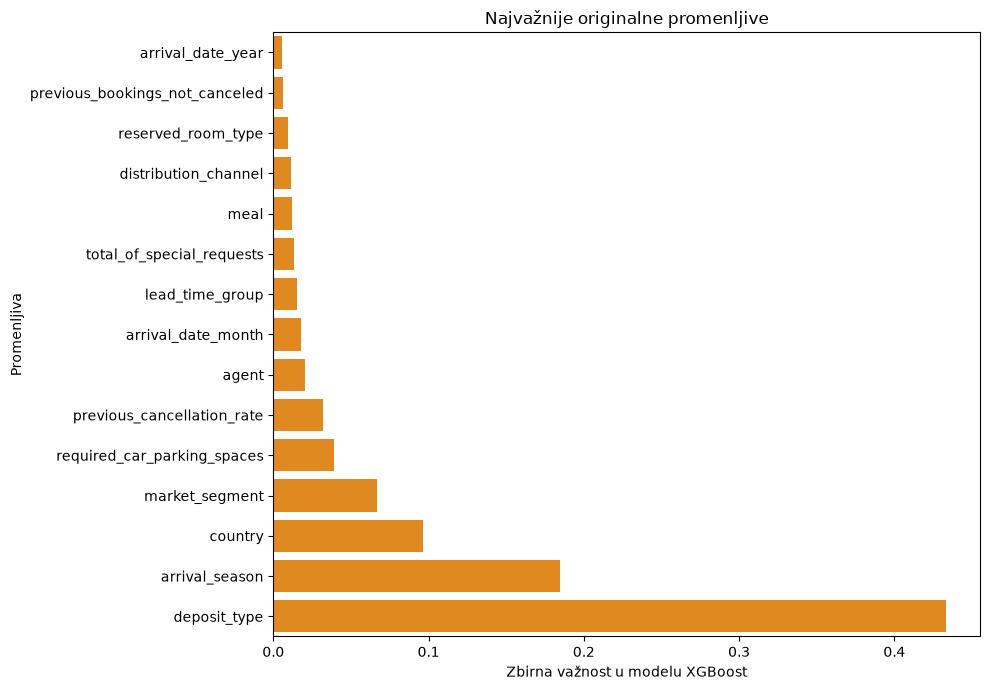

In [94]:
top_original_features = (
    original_feature_importance.head(15)
    .sort_values("Zbirna važnost", ascending=True)
)

plt.figure(figsize=(10, 7))
sb.barplot(
    data=top_original_features,
    x="Zbirna važnost",
    y="Promenljiva",
    color="darkorange"
)
plt.title("Najvažnije originalne promenljive")
plt.xlabel(f"Zbirna važnost u modelu {winning_model_name}")
plt.ylabel("Promenljiva")
plt.tight_layout()
plt.show()

Prema zbirnoj važnosti XGBoost modela najviše se izdvajaju `deposit_type` (0,4335), `arrival_season` (0,1845), `country` (0,0967) i `market_segment` (0,0670). Objedinjavanje one-hot kolona omogućava da se kategorijske promenljive ravnopravnije porede sa numeričkim.


### 15.3. Permutaciona važnost promenljivih

Kao dodatna provera koristi se permutaciona važnost, jer ugrađena važnost modela zasnovanog na stablima može drugačije rangirati promenljive od mere koja direktno prati promenu kvaliteta predviđanja.

Ova metoda funkcioniše tako što se vrednosti jedne promenljive nasumično izmešaju, dok svi ostali podaci ostaju isti. Zatim se ponovo izračunava ROC-AUC rezultat. Ako se rezultat primetno smanji, to znači da je ta promenljiva bila važna za predviđanje modela. Ako rezultat ostane skoro isti, model se nije mnogo oslanjao na nju.

Da bi se analiza brže izvršila, permutaciona važnost računa se na jednom delu test skupa. Ona služi samo za bolje razumevanje modela i ne utiče na njegovo treniranje niti na izbor hiperparametara.

In [95]:
from sklearn.inspection import permutation_importance

permutation_sample_size = min(5000, len(X_test))

permutation_sample_indices = X_test.sample(
    n=permutation_sample_size,
    random_state=42
).index

X_permutation = X_test.loc[permutation_sample_indices]
y_permutation = y_test.loc[permutation_sample_indices]

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_permutation,
    y=y_permutation,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

permutation_importance_df = pd.DataFrame({
    "Promenljiva": X_test.columns,
    "Prosečan pad ROC-AUC": permutation_results.importances_mean,
    "Standardna devijacija": permutation_results.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values("Prosečan pad ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df[[
    "Prosečan pad ROC-AUC",
    "Standardna devijacija"
]] = permutation_importance_df[[
    "Prosečan pad ROC-AUC",
    "Standardna devijacija"
]].round(4)

display(permutation_importance_df.head(15))

,Promenljiva,Prosečan pad ROC-AUC,Standardna devijacija
0,country,0.1025,0.0036
1,deposit_type,0.0820,0.0020
2,agent,0.0572,0.0016
3,lead_time,0.0376,0.0009
4,required_car_parking_spaces,0.0350,0.0021
5,total_of_special_requests,0.0323,0.0012
6,previous_cancellation_rate,0.0307,0.0010
7,market_segment,0.0290,0.0017
8,arrival_date_year,0.0266,0.0019
9,customer_type,0.0221,0.0024


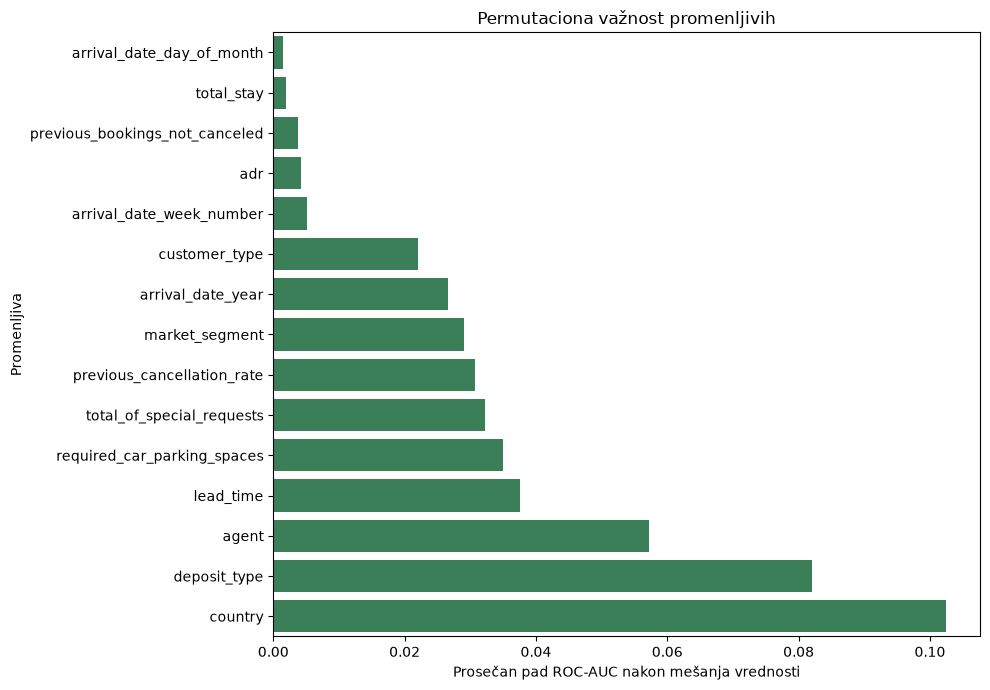

In [96]:
top_permutation_features = (
    permutation_importance_df.head(15)
    .sort_values("Prosečan pad ROC-AUC", ascending=True)
)

plt.figure(figsize=(10, 7))
sb.barplot(
    data=top_permutation_features,
    x="Prosečan pad ROC-AUC",
    y="Promenljiva",
    color="seagreen"
)
plt.title("Permutaciona važnost promenljivih")
plt.xlabel("Prosečan pad ROC-AUC nakon mešanja vrednosti")
plt.ylabel("Promenljiva")
plt.tight_layout()
plt.show()

Prema permutacionoj važnosti najveći prosečan pad ROC-AUC nastaje mešanjem promenljivih `country` (0,1025), `deposit_type` (0,0820) i `agent` (0,0572). Zatim slede `lead_time`, `required_car_parking_spaces`, `total_of_special_requests`, `previous_cancellation_rate` i `market_segment`.


### 15.4. Poređenje dobijenih rezultata

Ugrađena i permutaciona važnost ne daju uvek isti redosled promenljivih jer mere različite stvari. Ugrađena važnost pokazuje koliko je promenljiva doprinela podelama u XGBoost stablima, dok permutaciona važnost pokazuje koliko se rezultat smanji kada se njene vrednosti nasumično izmešaju.

Promenljive koje su visoko rangirane prema obe metode posebno su značajne za predviđanja modela. Kod međusobno povezanih prediktora važnost ipak može biti podeljena između više kolona, naročito kada originalna i izvedena promenljiva opisuju sličnu informaciju.

In [97]:
importance_ranking_comparison = (
    original_feature_importance[[
        "Promenljiva",
        "Zbirna važnost"
    ]]
    .merge(
        permutation_importance_df[[
            "Promenljiva",
            "Prosečan pad ROC-AUC"
        ]],
        on="Promenljiva",
        how="inner"
    )
)

importance_ranking_comparison[f"Rang {winning_model_name}"] = (
    importance_ranking_comparison["Zbirna važnost"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_ranking_comparison["Rang permutacije"] = (
    importance_ranking_comparison["Prosečan pad ROC-AUC"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_ranking_comparison["Prosečan rang"] = (
    importance_ranking_comparison[[
        f"Rang {winning_model_name}",
        "Rang permutacije"
    ]].mean(axis=1)
)

importance_ranking_comparison = (
    importance_ranking_comparison
    .sort_values("Prosečan rang")
    .reset_index(drop=True)
)

display(importance_ranking_comparison.head(15))

,Promenljiva,Zbirna važnost,Prosečan pad ROC-AUC,Rang XGBoost,Rang permutacije,Prosečan rang
0,deposit_type,0.4335,0.0820,1,2,1.5
1,country,0.0967,0.1025,3,1,2.0
2,agent,0.0201,0.0572,7,3,5.0
3,required_car_parking_spaces,0.0390,0.0350,5,5,5.0
4,market_segment,0.0670,0.0290,4,8,6.0
5,previous_cancellation_rate,0.0318,0.0307,6,7,6.5
6,total_of_special_requests,0.0131,0.0323,10,6,8.0
7,lead_time,0.0040,0.0376,17,4,10.5
8,arrival_date_year,0.0058,0.0266,15,9,12.0
9,arrival_date_month,0.0180,0.0013,8,16,12.0


Promenljive `deposit_type` i `country` nalaze se pri vrhu prema oba pristupa, dok se `agent`, `required_car_parking_spaces` i `market_segment` takođe izdvajaju u zajedničkom poređenju. `arrival_season` je visoko rangiran prema ugrađenoj važnosti, ali ima mali permutacioni efekat, što pokazuje zašto rezultate treba posmatrati zajedno.


### 15.5. Zaključak analize važnosti promenljivih

Analiza važnosti pokazuje da se konačni XGBoost naročito oslanja na `deposit_type` i `country`, koje obe metode rangiraju veoma visoko. Važni su i podaci o agentu, tržišnom segmentu, vremenu do dolaska i posebnim zahtevima. Rezultate treba tumačiti kao prediktivnu povezanost, a ne kao dokaz da određena promenljiva direktno izaziva otkazivanje.


## 16. Ograničenja analize i modela

Dobijeni rezultati pokazuju da model može prilično uspešno da predvidi otkazivanje hotelskih rezervacija. Ipak, rezultate treba posmatrati u okviru podataka koji su korišćeni u ovom radu. Zbog toga je važno navesti ograničenja analize i uslove koje bi trebalo uzeti u obzir pre moguće primene modela.

### 16.1. Ograničenja skupa podataka

Korišćeni podaci obuhvataju rezervacije samo dva hotela – jednog gradskog i jednog odmarališnog. Obrasci koje je model naučio zato ne moraju biti isti u hotelima iz drugih država, objektima drugačije veličine ili hotelima sa drugačijom strukturom gostiju. Pre primene u drugom hotelu bilo bi potrebno proveriti model na njegovim podacima.

Rezervacije su prikupljene u periodu od 2015. do 2017. godine, pri čemu podaci za 2015. i 2017. godinu ne obuhvataju svih dvanaest meseci. Navike gostiju, načini rezervisanja, cene i tržišni kanali menjaju se tokom vremena, pa rezultati dobijeni na ovom skupu ne moraju u potpunosti odgovarati današnjim uslovima.

U podacima postoji informacija o tome da li je rezervacija otkazana, ali ne i razlog otkazivanja. Zbog toga nije moguće utvrditi da li je gost rezervaciju otkazao zbog promene plana, cene, vremenskih uslova ili nekog drugog razloga. Takođe nisu dostupne neke informacije koje bi mogle biti korisne, kao što su podaci o promocijama, cenama konkurencije i komunikaciji sa gostima.

### 16.2. Ograničenja čišćenja i kreiranja promenljivih

Tokom čišćenja uklonjene su ukupno 182 rezervacije: 180 zapisa bez evidentiranih gostiju i dve rezervacije sa ekstremnim ADR vrednostima. Ovi zapisi čine veoma mali deo celog skupa, ali njihovo uklanjanje ipak može u manjoj meri uticati na rezultate.

Nedostajuće vrednosti obrađene su u skladu sa značenjem pojedinačnih kolona. U pipeline-u je dodatno primenjeno popunjavanje numeričkih vrednosti medijanom, a kategorijskih najčešćom vrednošću. Ovaj postupak omogućava da model obradi sve rezervacije, ali popunjena vrednost ne mora uvek odgovarati stvarnoj vrednosti koja je nedostajala.

Neke izvedene promenljive sadrže slične informacije kao originalne kolone. Na primer, `lead_time_group` je napravljen na osnovu kolone `lead_time`, dok je `total_stay` dobijen sabiranjem broja noćenja tokom radnih dana i vikenda. Zbog toga model može rasporediti njihov značaj između više povezanih kolona, što treba uzeti u obzir prilikom tumačenja važnosti promenljivih.

### 16.3. Ograničenja trenutka predviđanja

U radu je pretpostavljeno da se predviđanje vrši odmah nakon kreiranja rezervacije. Zbog toga model ne koristi `assigned_room_type`, `booking_changes` i `days_in_waiting_list`, jer njihove konačne vrednosti u tom trenutku nisu pouzdano poznate. Na ovaj način smanjuje se mogućnost curenja podataka i omogućava rano predviđanje otkazivanja. Međutim, model zbog toga ne koristi informacije koje bi mogle postati dostupne kasnije i dodatno poboljšati predviđanje.

U stvarnoj primeni mogao bi se napraviti još jedan model koji bi ponovo procenjivao mogućnost otkazivanja nekoliko dana pre dolaska gosta. Takav model mogao bi da koristi novije informacije, ali bi morao posebno da se trenira i proverava za taj trenutak predviđanja.

### 16.4. Ograničenja modela i evaluacije

Ni konačni podešeni XGBoost sa sve 34 promenljive ne klasifikuje sve rezervacije tačno. Broj propuštenih otkazivanja i lažnih upozorenja prikazan je u matrici konfuzije i detaljnije analiziran u narednom poglavlju.

Model je izabran prema F1 vrednosti, ali hotel u praksi može imati drugačije prioritete. Pretraga hiperparametara obuhvatila je šest nasumičnih kombinacija od ukupno 96, pa nije proverena svaka moguća konfiguracija. Korišćena je grupna stratifikovana podela koja sprečava preklapanje identičnih rezervacionih profila između trening i test skupa, ali vremenska validacija ostaje korisna dodatna provera.


### 16.5. Tumačenje i praktična primena

XGBoost može da prepozna složene odnose između različitih podataka o rezervaciji, ali je njegove odluke teže objasniti nego odluke logističke regresije ili jednog stabla odlučivanja. Analiza važnosti promenljivih pokazuje koje podatke model najviše koristi, ali ne objašnjava uvek na koji način oni utiču na pojedinačno predviđanje.

Važnost promenljive takođe ne predstavlja dokaz da ona direktno izaziva otkazivanje. Na primer, `deposit_type` ili `country` mogu biti veoma korisni za predviđanje, ali se samo na osnovu modela ne može zaključiti da su oni uzrok otkazivanja. Rezultati pokazuju povezanosti koje postoje u korišćenom skupu podataka.

Promenljiva `country` pokazala se kao važna za predviđanje, ali to ne znači da sama država iz koje gost dolazi određuje da li će rezervacija biti otkazana. Ovu informaciju treba posmatrati zajedno sa ostalim podacima i ne koristiti je kao osnov za drugačiji tretman gostiju.

Pre praktične upotrebe model bi trebalo proveriti na novijim rezervacijama i podacima hotela u kojem bi se koristio. Njegove rezultate trebalo bi redovno pratiti, a model povremeno ponovo trenirati kako bi se prilagodio promenama u ponašanju gostiju. Predviđanja bi trebalo da služe kao pomoć zaposlenima, a ne kao jedini osnov za donošenje odluka.

### 16.6. Zaključak ograničenja

Najvažnija ograničenja odnose se na mali broj posmatranih hotela, starost podataka, nedostatak razloga otkazivanja i mogućnost promena obrazaca kroz vreme. Model je pokazao stabilne rezultate na izdvojenom test skupu, ali bi njegovu pouzdanost trebalo ponovo proveriti pre primene u drugačijem hotelu ili vremenskom periodu.

Rezultate zato treba posmatrati kao dokaz da dostupne informacije imaju dobru prediktivnu vrednost u ovom skupu, a ne kao univerzalno pravilo koje bez dodatne provere važi za svaku hotelsku rezervaciju.

## 17. Analiza grešaka modela

Konačne metrike pokazuju koliko je model uspešan u celini, ali ne otkrivaju kod kakvih rezervacija najčešće pravi greške. Zbog toga će u ovom poglavlju posebno biti analizirana otkazivanja koja model nije prepoznao, kao i neotkazane rezervacije koje je pogrešno označio kao otkazane.

Za ovu analizu koriste se već dobijena predviđanja na test skupu. Dobijeni rezultati služe samo za bolje razumevanje grešaka i neće se koristiti za dodatno podešavanje modela.

### 17.1. Formiranje grupa prema rezultatu predviđanja

Svaka rezervacija iz test skupa svrstava se u jednu od četiri grupe:

- tačno prepoznata neotkazana rezervacija;
- lažno upozorenje, kada je neotkazana rezervacija označena kao otkazana;
- propušteno otkazivanje, kada je otkazana rezervacija označena kao neotkazana;
- tačno prepoznata otkazana rezervacija.

Pored stvarne i predviđene klase čuva se i procenjena verovatnoća otkazivanja, što omogućava da se vidi koliko je model bio siguran u tačna i pogrešna predviđanja.

In [98]:
error_analysis_df = X_test.copy()

error_analysis_df["Stvarna klasa"] = y_test
error_analysis_df["Predviđena klasa"] = y_test_prediction
error_analysis_df["Verovatnoća otkazivanja"] = y_test_probability

error_conditions = [
    (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 1)
    )
]

error_labels = [
    "Tačno prepoznata neotkazana",
    "Lažno upozorenje",
    "Propušteno otkazivanje",
    "Tačno prepoznata otkazana"
]

error_analysis_df["Ishod predviđanja"] = np.select(
    error_conditions,
    error_labels,
    default="Nepoznato"
)

assert not (error_analysis_df["Ishod predviđanja"] == "Nepoznato").any()
assert len(error_analysis_df) == len(X_test)

print("Podaci za analizu grešaka su uspešno pripremljeni.")

Podaci za analizu grešaka su uspešno pripremljeni.


,Ishod predviđanja,Broj rezervacija,Udeo u test skupu (%)
0,Tačno prepoznata neotkazana,13662,57.30
1,Lažno upozorenje,1341,5.62
2,Propušteno otkazivanje,1695,7.11
3,Tačno prepoznata otkazana,7145,29.97


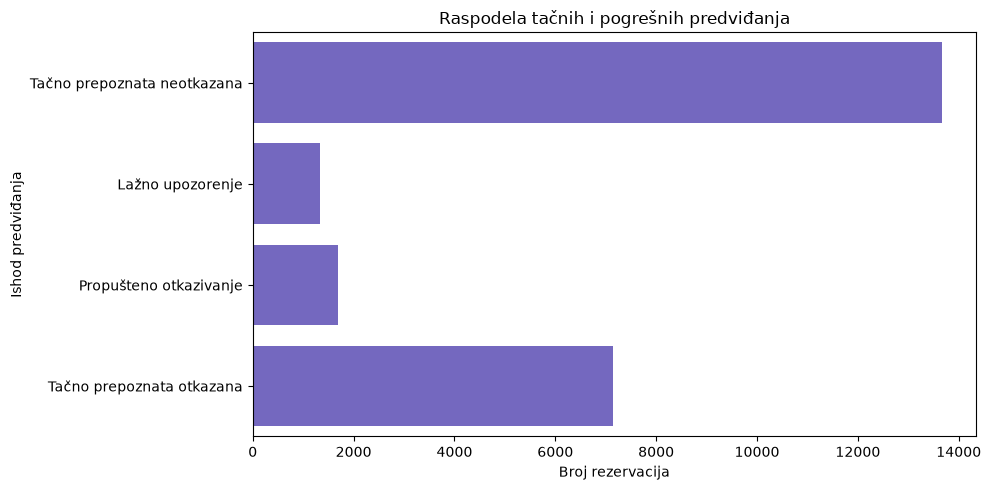

In [99]:
error_group_summary = (
    error_analysis_df["Ishod predviđanja"]
    .value_counts()
    .reindex(error_labels)
    .rename_axis("Ishod predviđanja")
    .reset_index(name="Broj rezervacija")
)

error_group_summary["Udeo u test skupu (%)"] = (
    error_group_summary["Broj rezervacija"]
    / len(error_analysis_df) * 100
).round(2)

display(error_group_summary)

plt.figure(figsize=(10, 5))
sb.barplot(
    data=error_group_summary,
    x="Broj rezervacija",
    y="Ishod predviđanja",
    color="slateblue"
)
plt.title("Raspodela tačnih i pogrešnih predviđanja")
plt.xlabel("Broj rezervacija")
plt.ylabel("Ishod predviđanja")
plt.tight_layout()
plt.show()

Tabela prikazuje broj i udeo tačnih i pogrešnih predviđanja konačnog podešenog XGBoost modela. Broj tačnih predviđanja treba posmatrati zajedno sa brojem lažnih upozorenja i propuštenih otkazivanja.


### 17.2. Verovatnoće kod tačnih i pogrešnih predviđanja

Kod rezervacija koje se nalaze blizu praga od 0,5 model je manje siguran kojoj klasi pripadaju. Poređenjem procenjenih verovatnoća može se proveriti da li su pogrešna predviđanja uglavnom nastala kod takvih graničnih slučajeva ili je model kod nekih grešaka bio izrazito siguran.

,Ishod predviđanja,count,mean,median,min,max
0,Tačno prepoznata neotkazana,13662,0.0964,0.0285,0.0000,0.4995
1,Lažno upozorenje,1341,0.6586,0.6472,0.5001,0.9970
2,Propušteno otkazivanje,1695,0.2924,0.2939,0.0016,0.4993
3,Tačno prepoznata otkazana,7145,0.8608,0.9135,0.5001,1.0000


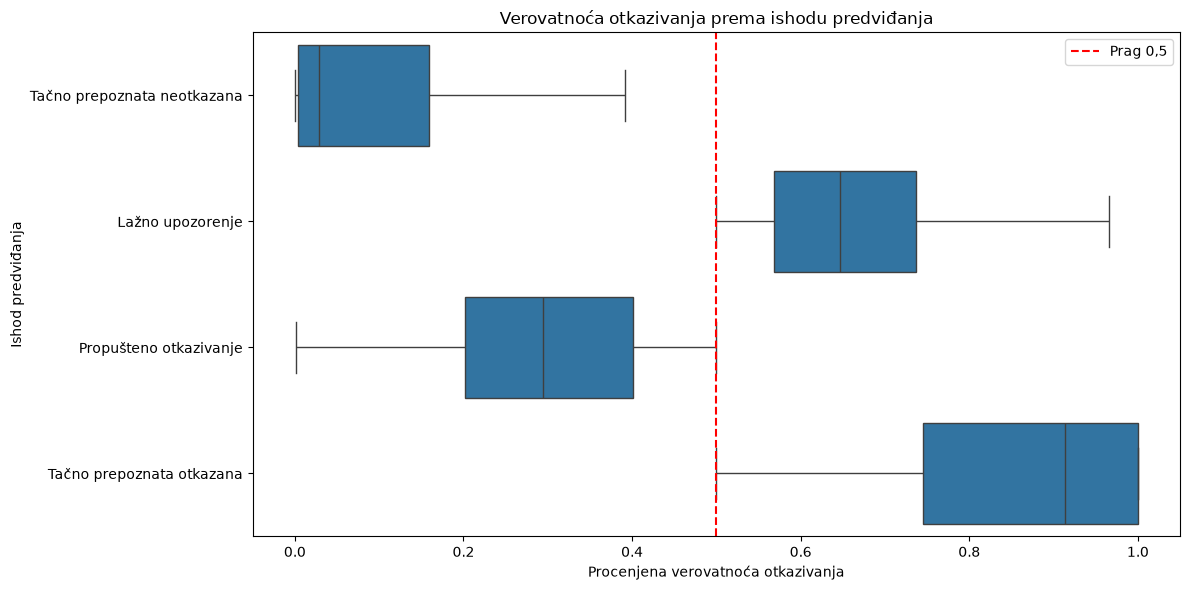

In [100]:
probability_by_outcome = (
    error_analysis_df
    .groupby("Ishod predviđanja", observed=True)
    ["Verovatnoća otkazivanja"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(error_labels)
    .reset_index()
)

probability_by_outcome[[
    "mean", "median", "min", "max"
]] = probability_by_outcome[[
    "mean", "median", "min", "max"
]].round(4)

display(probability_by_outcome)

plt.figure(figsize=(12, 6))
sb.boxplot(
    data=error_analysis_df,
    x="Verovatnoća otkazivanja",
    y="Ishod predviđanja",
    order=error_labels,
    showfliers=False
)
plt.axvline(0.5, color="red", linestyle="--", label="Prag 0,5")
plt.title("Verovatnoća otkazivanja prema ishodu predviđanja")
plt.xlabel("Procenjena verovatnoća otkazivanja")
plt.ylabel("Ishod predviđanja")
plt.legend()
plt.tight_layout()
plt.show()

Prikazane verovatnoće pokazuju koliko je model bio siguran kod tačnih i pogrešnih predviđanja. Greške bliže pragu od 0,5 predstavljaju slučajeve kod kojih je model bio manje siguran.


### 17.3. Greške prema odabranim grupama rezervacija

Posmatrane grupe nemaju isti broj rezervacija, zbog čega samo poređenje ukupnog broja grešaka ne bi bilo dovoljno. Zato se računa procenat stvarno otkazanih rezervacija koje model nije prepoznao, kao i procenat neotkazanih rezervacija koje je pogrešno označio kao otkazane.

Rezultati se porede prema tipu hotela, vrsti depozita, tržišnom segmentu i grupama promenljive `lead_time`. Ove promenljive su izabrane jer su se tokom eksplorativne analize i analize važnosti pokazale kao značajne za predviđanje otkazivanja.

In [101]:
def create_model_error_summary(data, column):
    summaries = []

    for value, group in data.groupby(column, observed=True):
        actual_canceled = (group["Stvarna klasa"] == 1).sum()
        actual_not_canceled = (group["Stvarna klasa"] == 0).sum()
        missed_cancellations = (
            (group["Stvarna klasa"] == 1)
            & (group["Predviđena klasa"] == 0)
        ).sum()
        false_alarms = (
            (group["Stvarna klasa"] == 0)
            & (group["Predviđena klasa"] == 1)
        ).sum()

        summaries.append({
            "Grupa": value,
            "Broj rezervacija": len(group),
            "Stvarno otkazane": actual_canceled,
            "Propuštena otkazivanja": missed_cancellations,
            "Stopa propuštenih otkazivanja (%)": (
                missed_cancellations / actual_canceled * 100
                if actual_canceled > 0 else np.nan
            ),
            "Stvarno neotkazane": actual_not_canceled,
            "Lažna upozorenja": false_alarms,
            "Stopa lažnih upozorenja (%)": (
                false_alarms / actual_not_canceled * 100
                if actual_not_canceled > 0 else np.nan
            )
        })

    result = pd.DataFrame(summaries)
    percentage_columns = [
        "Stopa propuštenih otkazivanja (%)",
        "Stopa lažnih upozorenja (%)"
    ]
    result[percentage_columns] = result[percentage_columns].round(2)

    return result

In [102]:
error_group_columns = [
    "hotel",
    "deposit_type",
    "market_segment",
    "lead_time_group"
]

model_error_summaries = {}

for column in error_group_columns:
    summary = create_model_error_summary(
        error_analysis_df,
        column
    )
    model_error_summaries[column] = summary

    print("Greške prema promenljivoj:", column)
    display(summary)

Greške prema promenljivoj: hotel


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,City Hotel,15903,6715,1276,19.00,9188,937,10.20
1,Resort Hotel,7940,2125,419,19.72,5815,404,6.95


Greške prema promenljivoj: deposit_type


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,No Deposit,20979,6017,1694,28.15,14962,1338,8.94
1,Non Refund,2848,2817,1,0.04,31,3,9.68
2,Refundable,16,6,0,0.00,10,0,0.00


Greške prema promenljivoj: market_segment


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,Aviation,34,4,1,25.00,30,3,10.00
1,Complementary,144,19,18,94.74,125,1,0.80
2,Corporate,1004,197,71,36.04,807,9,1.12
3,Direct,2499,349,239,68.48,2150,45,2.09
4,Groups,3825,2329,40,1.72,1496,78,5.21
5,Offline TA/TO,4908,1714,229,13.36,3194,115,3.60
6,Online TA,11429,4228,1097,25.95,7201,1090,15.14


Greške prema promenljivoj: lead_time_group


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,0-30 dana,7575,1354,644,47.56,6221,225,3.62
1,31-90 dana,6141,2520,565,22.42,3621,451,12.46
2,91-180 dana,5169,2133,344,16.13,3036,425,14.00
3,181-365 dana,4396,2491,141,5.66,1905,237,12.44
4,Više od 365 dana,562,342,1,0.29,220,3,1.36


Tabele iznad prikazuju kako se stope propuštenih otkazivanja i lažnih upozorenja razlikuju prema tipu hotela, depozitu, tržišnom segmentu i grupi `lead_time`. Kategorije sa malim brojem rezervacija treba tumačiti oprezno.


### 17.4. Tabela TP, TN, FP i FN

Radi jasnijeg pregleda, rezultati se prikazuju i pomoću standardnih oznaka matrice konfuzije. TP i TN predstavljaju tačna predviđanja, dok FP označava lažno upozorenje, a FN propušteno otkazivanje.


In [103]:
confusion_counts = {
    "TP": (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ).sum(),
    "TN": (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ).sum(),
    "FP": (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ).sum(),
    "FN": (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ).sum()
}

confusion_error_table = pd.DataFrame([
    ["TP", "Tačno prepoznata otkazana", 1, 1, confusion_counts["TP"]],
    ["TN", "Tačno prepoznata neotkazana", 0, 0, confusion_counts["TN"]],
    ["FP", "Lažno upozorenje", 0, 1, confusion_counts["FP"]],
    ["FN", "Propušteno otkazivanje", 1, 0, confusion_counts["FN"]]
], columns=[
    "Oznaka",
    "Značenje",
    "Stvarna klasa",
    "Predviđena klasa",
    "Broj rezervacija"
])

confusion_error_table["Udeo u test skupu (%)"] = (
    confusion_error_table["Broj rezervacija"]
    / len(error_analysis_df) * 100
).round(2)

assert confusion_error_table["Broj rezervacija"].sum() == len(error_analysis_df)

print(confusion_error_table.to_string(index=False))


Oznaka                    Značenje  Stvarna klasa  Predviđena klasa  Broj rezervacija  Udeo u test skupu (%)
    TP   Tačno prepoznata otkazana              1                 1              7145                  29.97
    TN Tačno prepoznata neotkazana              0                 0             13662                  57.30
    FP            Lažno upozorenje              0                 1              1341                   5.62
    FN      Propušteno otkazivanje              1                 0              1695                   7.11


Od ukupno **23.843** rezervacije, model je pravilno prepoznao **7.145 otkazanih (TP)** i **13.662 neotkazane rezervacije (TN)**. Napravio je **1.341 lažno upozorenje (FP)** i propustio **1.695 otkazivanja (FN)**. Propuštena otkazivanja su zato bila češća od lažnih upozorenja.


### 17.5. Primeri FP i FN grešaka

U nastavku je prikazano po pet primera grešaka kod kojih je model bio najsigurniji u pogrešnu odluku. Za FP primere biraju se najveće procenjene verovatnoće otkazivanja, a za FN primere najmanje. Ovi primeri služe za ilustraciju i ne predstavljaju prosečnu grešku modela.


In [104]:
example_columns = [
    "hotel",
    "market_segment",
    "deposit_type",
    "lead_time",
    "Stvarna klasa",
    "Predviđena klasa",
    "Verovatnoća otkazivanja"
]

example_column_names = {
    "hotel": "Tip hotela",
    "market_segment": "Tržišni segment",
    "deposit_type": "Tip depozita",
    "lead_time": "Lead time"
}

false_positive_examples = (
    error_analysis_df.loc[
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1),
        example_columns
    ]
    .sort_values(
        "Verovatnoća otkazivanja",
        ascending=False,
        kind="stable"
    )
    .head(5)
    .copy()
)

false_negative_examples = (
    error_analysis_df.loc[
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0),
        example_columns
    ]
    .sort_values(
        "Verovatnoća otkazivanja",
        ascending=True,
        kind="stable"
    )
    .head(5)
    .copy()
)

class_names = {
    0: "Nije otkazana",
    1: "Otkazana"
}

for examples in [false_positive_examples, false_negative_examples]:
    examples.insert(0, "Indeks rezervacije", examples.index)
    examples.rename(columns=example_column_names, inplace=True)
    examples["Stvarna klasa"] = examples["Stvarna klasa"].map(class_names)
    examples["Predviđena klasa"] = examples["Predviđena klasa"].map(class_names)
    examples["Verovatnoća otkazivanja"] = examples[
        "Verovatnoća otkazivanja"
    ].round(4)

print("Pet FP primera sa najvećom procenjenom verovatnoćom otkazivanja:")
print(false_positive_examples.reset_index(drop=True).to_string(index=False))

print("\nPet FN primera sa najmanjom procenjenom verovatnoćom otkazivanja:")
print(false_negative_examples.reset_index(drop=True).to_string(index=False))


Pet FP primera sa najvećom procenjenom verovatnoćom otkazivanja:
 Indeks rezervacije   Tip hotela Tržišni segment Tip depozita  Lead time Stvarna klasa Predviđena klasa  Verovatnoća otkazivanja
              14182 Resort Hotel          Direct   No Deposit         80 Nije otkazana         Otkazana                   0.9970
              78367   City Hotel       Corporate   No Deposit          7 Nije otkazana         Otkazana                   0.9658
              39286 Resort Hotel       Online TA   No Deposit        327 Nije otkazana         Otkazana                   0.9486
              47047   City Hotel       Online TA   No Deposit         60 Nije otkazana         Otkazana                   0.9384
              34161 Resort Hotel          Groups   No Deposit        195 Nije otkazana         Otkazana                   0.9372

Pet FN primera sa najmanjom procenjenom verovatnoćom otkazivanja:
 Indeks rezervacije   Tip hotela Tržišni segment Tip depozita  Lead time Stvarna klasa Predviđ

Primeri pokazuju da model ponekad može biti veoma siguran i kada pogreši. Zbog toga procenjenu verovatnoću ne treba posmatrati kao garanciju, već kao procenu rizika koja se koristi zajedno sa drugim informacijama o rezervaciji.


### 17.6. Poređenje prema tipu hotela i tržišnom segmentu

Kod gradskog hotela zabeležen je veći ukupan broj grešaka, što je očekivano jer je u test skupu imao više rezervacija. Stopa propuštenih otkazivanja bila je nešto veća kod resort hotela (**19,72%**) nego kod gradskog hotela (**19,00%**). Sa druge strane, stopa lažnih upozorenja bila je veća kod gradskog hotela (**10,20%**) nego kod resort hotela (**6,95%**).

Prema tržišnom segmentu, najveći apsolutni broj obe vrste grešaka pojavio se kod segmenta `Online TA`: **1.090 FP** i **1.097 FN**. Ovaj segment imao je i najveću stopu lažnih upozorenja među većim grupama (**15,14%**). Segment `Direct` imao je visoku stopu propuštenih otkazivanja od **68,48%**, dok su te stope kod segmenata `Groups` i `Offline TA/TO` bile znatno niže. Visoke procente kod malih grupa, kao što su `Aviation` i `Complementary`, treba tumačiti oprezno zbog malog broja rezervacija.


### 17.7. Praktične posledice FP i FN grešaka

**FP greška** nastaje kada model predvidi otkazivanje, a gost ipak dođe. Ako bi hotel bez dodatne provere reagovao na takvu procenu, mogao bi nepotrebno da kontaktira gosta, zahteva dodatnu potvrdu ili rezervaciju pogrešno uključi u planiranje prebukiranosti. To može povećati troškove i negativno uticati na iskustvo gosta.

**FN greška** nastaje kada model očekuje da će rezervacija biti realizovana, a ona se ipak otkaže. Hotel tada može propustiti priliku da na vreme ponudi sobu drugom gostu, pa posledica može biti prazna soba i izgubljen prihod. U test skupu bilo je više FN nego FP grešaka (1.695 prema 1.341). Ipak, prag odlučivanja treba prilagoditi stvarnom odnosu troška propuštenog otkazivanja i lažnog upozorenja.


### 17.8. Zaključak analize grešaka

Konačni podešeni XGBoost je na test skupu pravilno klasifikovao **20.807 od 23.843 rezervacije**, dok je napravio ukupno **3.036 grešaka**. Od toga je bilo **1.341 FP** i **1.695 FN** slučajeva, pa je model češće propuštao stvarna otkazivanja nego što je stvarao lažna upozorenja.

Greške nisu bile jednako raspoređene. Resort hotel imao je veću stopu propuštenih otkazivanja, dok je gradski hotel imao veću stopu lažnih upozorenja. Segment `Online TA` izdvojio se najvećim apsolutnim brojem obe vrste grešaka, a kod segmenta `Direct` uočena je visoka stopa propuštenih otkazivanja. Analiza pojedinačnih primera dodatno pokazuje da model ponekad može biti relativno siguran i kada je njegova klasifikacija pogrešna.

Zbog toga bi model u praksi trebalo koristiti kao podršku za procenu rizika, a ne kao jedini osnov za automatsku odluku o rezervaciji. Ova analiza koristi samo ranije dobijena test predviđanja i nije korišćena za promenu modela, praga, feature selection-a ili podešavanje hiperparametara.


## 18. Završni zaključak

### 18.1. Cilj i sprovedena analiza

Cilj ovog rada bio je da se ispita da li se na osnovu podataka dostupnih u trenutku rezervisanja može predvideti kasnije otkazivanje rezervacije. Podaci su najpre pregledani i očišćeni, a zatim su analizirani najvažniji obrasci povezani sa otkazivanjem. Napravljene su i dodatne promenljive koje opisuju karakteristike rezervacije i prethodno ponašanje gosta.

### 18.2. Rezultati modeliranja

Među pet početnih modela XGBoost je ostvario najbolji CV F1 od 0,8060 i ROC-AUC od 0,9401. Zato su zatim poređene XGBoost varijante sa svih 34, top 20 i top 10 promenljivih. Najbolji F1 zadržala je puna varijanta (0,8060), ispred top-20 (0,8019) i top-10 varijante (0,7386), pa feature selection nije primenjen u konačnom modelu.

Podešeni XGBoost sa svih 34 promenljive ostvario je petostruki grupni CV F1 od 0,8131, naspram 0,8060 pre tuninga, pa je izabran kao konačni model. Na izdvojenom test skupu ostvario je accuracy 0,8727, precision 0,8420, recall 0,8083, F1 0,8248 i ROC-AUC 0,9470. Test skup nije korišćen za izbor modela ili podešavanje hiperparametara, a grupna podela je potvrdila da nema preklapanja identičnih rezervacionih profila između trening i test skupa.


### 18.3. Najvažniji nalazi

Feature selection je pokazao da smanjenje sa 34 na 20 ili 10 promenljivih ne poboljšava XGBoost, pa konačni model koristi svih 34 dozvoljenih prediktora. Ugrađena i permutaciona važnost saglasno izdvajaju `deposit_type` i `country`, dok se kao važni pojavljuju i `agent`, `market_segment`, `lead_time` i podaci o posebnim zahtevima.

Analiza grešaka pokazuje kod kojih vrsta rezervacija model ima više poteškoća. Ovi nalazi pomažu u tumačenju modela, ali ne dokazuju da posmatrane promenljive direktno izazivaju otkazivanje.


### 18.4. Konačni zaključak

Rezultati pokazuju da se na osnovu informacija dostupnih u trenutku rezervisanja može prilično uspešno proceniti rizik od kasnijeg otkazivanja. Model bi hotelu mogao da posluži kao podrška pri planiranju kapaciteta i ranom prepoznavanju rezervacija koje zahtevaju dodatnu pažnju. Njegova predviđanja ipak ne bi trebalo da budu jedini osnov za donošenje odluka.

Pre praktične primene model bi trebalo proveriti na novijim podacima i rezervacijama drugih hotela, a zatim redovno pratiti njegove rezultate. Korišćeni skup obuhvata samo dva hotela i period od 2015. do 2017. godine, pa se ne može pretpostaviti da će model bez dodatne provere biti jednako uspešan u svim hotelima i vremenskim periodima.